# Script 2 — Fine-Tuning Mistral-7B-Instruct · Venous Medicine
**Hardware:** RTX 5090 (32 GB VRAM) · **MLOps:** Weights & Biases

### Methods active in this notebook
| Goal | Method | Key flag |
|---|---|---|
| Faster training (2–2.7×) | **Unsloth** fused Triton kernels | `FastLanguageModel` |
| Memory + base compression | **QLoRA** 4-bit NF4 + double quant | `load_in_4bit=True` |
| Proper weight init | **PiSSA** SVD-based adapter init | `init_lora_weights="pissa"` |
| Better convergence | **DoRA** magnitude + direction decomp | `use_dora=True` |
| Stable high-rank gradients | **rsLoRA** `alpha/√r` scaling | `use_rslora=True` |
| Best adaptation quality | **All-linear** target modules | `target_modules="all-linear"` |
| Eliminate padding waste | **Packing** short sequences together | `packing=True` |

Run cells top-to-bottom. W&B dashboard opens after Cell 10 starts training.

In [3]:
import torch
print(f'PyTorch {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Supported architectures: {torch.cuda.get_arch_list()}')

PyTorch 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090
Supported architectures: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [5]:
# ── 0. Install dependencies ───────────────────────────────────────────────────
import subprocess, sys, platform

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

# PyTorch is pre-installed in venv. Only install extra deps.
pip('transformers>=4.40', 'datasets>=2.19', 'peft>=0.10', 'trl>=0.8',
    'bitsandbytes>=0.43', 'accelerate>=0.29', 'wandb>=0.17',
    'scipy', 'sentencepiece')

# Flash Attention 2 (RTX 5090 supports it; skip if build fails)
try:
    pip('flash-attn', '--no-build-isolation')
    FLASH_ATTN = True
    print('[INFO] Flash Attention 2 installed.')
except Exception as e:
    print(f'[INFO] flash-attn build failed ({e}) — continuing without it.')
    FLASH_ATTN = False

# Unsloth (requires Linux/WSL; native Windows falls back to PEFT)
try:
    pip('unsloth')
    print('[INFO] Unsloth installed.')
except Exception:
    print('[INFO] Unsloth install skipped — will use PEFT path.')

import torch
assert torch.cuda.is_available(), 'CUDA not available — check CUDA Toolkit installation'
print(f'PyTorch {torch.__version__} | CUDA {torch.version.cuda}')
print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'OS   : {platform.system()}')

In [8]:
# ── 1. W&B login ──────────────────────────────────────────────────────────────
import wandb, os

wandb.login()   # first run: browser prompt; subsequent runs: cached key

WANDB_PROJECT  = 'mistral-venous-medicine'
WANDB_RUN_NAME = 'mistral7b-pissa-dora-rslora-unsloth-v1'
os.environ['WANDB_PROJECT'] = WANDB_PROJECT
print(f'W&B project: {WANDB_PROJECT}')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/krish/.netrc.
wandb: Currently logged in as: claudekumar07 (claudekumar07-cygnus-medical) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B project: mistral-venous-medicine


In [30]:
# ── 2. Config ─────────────────────────────────────────────────────────────────
from pathlib import Path

BASE_MODEL_ID    = 'mistralai/Mistral-7B-Instruct-v0.2'
TRAIN_FILE       = Path('training_data_train.jsonl')
VAL_FILE         = Path('training_data_val.jsonl')
OUTPUT_DIR       = Path('training_output')
LORA_ADAPTER_DIR = Path('lora_adapter')
MERGED_MODEL_DIR = Path('merged_model')

# ── Training hyperparameters
NUM_EPOCHS       = 3
BATCH_SIZE       = 4       # RTX 5090 32GB handles 4 comfortably with 4-bit
GRAD_ACCUM_STEPS = 4       # effective batch = 16
LEARNING_RATE    = 2e-4    # LoRA sweet-spot; cosine scheduler decays from here
MAX_SEQ_LENGTH   = 2048
WARMUP_RATIO     = 0.05
LR_SCHEDULER     = 'cosine'
SAVE_STEPS       = 100
EVAL_STEPS       = 100
LOGGING_STEPS    = 10
RANDOM_SEED      = 42

# ── LoRA / adapter config
LORA_R       = 32
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
LORA_TARGET  = 'all-linear'

# ── Method flags
USE_DORA    = True
USE_RSLORA  = True
LORA_INIT   = 'pissa'

print('Config loaded.')
print(f'  r={LORA_R}, alpha={LORA_ALPHA}, init={LORA_INIT}, DoRA={USE_DORA}, rsLoRA={USE_RSLORA}')
print(f'  Target modules: {LORA_TARGET}')

Config loaded.
  r=32, alpha=32, init=pissa, DoRA=True, rsLoRA=True
  Target modules: all-linear


In [31]:
# ── 3. Load dataset ───────────────────────────────────────────────────────────
from datasets import load_dataset

ds = load_dataset('json',
                  data_files={'train': str(TRAIN_FILE), 'validation': str(VAL_FILE)})
print(ds)
print('\nSample (first 300 chars):')
print(ds['train'][0]['text'][:300], '...')

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 4007
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1002
    })
})

Sample (first 300 chars):
<s>[INST] You are a medical expert specialising in venous and lymphatic disorders, vascular surgery, duplex ultrasound, and haemodynamics. Answer questions accurately using clinical and scientific knowledge.

What are the key clinical concepts described in the following passage?

push, easily seen w ...


In [12]:
! pip install psutil

In [13]:
! pip install flash_attn --no-build-isolation

  Using cached flash_attn-2.8.3.tar.gz (8.4 MB)
  Preparing metadata (pyproject.toml) ... done
  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
Using cached einops-0.8.2-py3-none-any.whl (65 kB)
anceled
ERROR: Operation cancelled by user


In [16]:
! source ~/pytorch_env/bin/activate
! pip uninstall flash-attn -y
! pip install flash-attn --only-binary :all: --no-build-isolation

ERROR: Could not find a version that satisfies the requirement flash-attn (from versions: none)
ERROR: No matching distribution found for flash-attn


In [17]:
! pip install flash-attn==2.5.8 --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 8.1 MB/s  0:00:00 eta 0:00:01
  Preparing metadata (pyproject.toml) ... done
  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
Using cached einops-0.8.2-py3-none-any.whl (65 kB)
anceled
ERROR: Operation cancelled by user


In [9]:
# ── 4. Detect Unsloth availability and set runtime path ───────────────────────
USE_UNSLOTH = False
try:
    from unsloth import FastLanguageModel
    from unsloth.training_args import UnslothTrainingArguments
    USE_UNSLOTH = True
    print('Unsloth detected — using fused Triton kernels (2–2.7× faster).')
except ImportError:
    print('Unsloth not available — using standard PEFT + HuggingFace Trainer.')
    print('Training will be correct but without kernel-level speed boost.')

print(f'Runtime: {"Unsloth" if USE_UNSLOTH else "PEFT"}')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth not available — using standard PEFT + HuggingFace Trainer.
Training will be correct but without kernel-level speed boost.
Runtime: PEFT


In [18]:
"""
# ── 5. Load base model + tokenizer ───────────────────────────────────────────
import torch

if USE_UNSLOTH:
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL_ID,
        max_seq_length=MAX_SEQ_LENGTH,
        load_in_4bit=True,
        dtype=None,
        device_map='auto',
    )
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    #attn_impl = 'flash_attention_2' if FLASH_ATTN else 'eager'
    attn_impl = 'eager'
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        quantization_config=bnb_config,
        device_map='auto',
        torch_dtype=torch.bfloat16,
        attn_implementation=attn_impl,
    )
    model.config.use_cache = False
    model.config.pretraining_tp = 1

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

total_params = sum(p.numel() for p in model.parameters())
print(f'Base model loaded: {total_params / 1e9:.2f}B params')
print(f'Tokenizer vocab size: {tokenizer.vocab_size}')"""

"\n# ── 5. Load base model + tokenizer ───────────────────────────────────────────\nimport torch\n\nif USE_UNSLOTH:\n    model, tokenizer = FastLanguageModel.from_pretrained(\n        model_name=BASE_MODEL_ID,\n        max_seq_length=MAX_SEQ_LENGTH,\n        load_in_4bit=True,\n        dtype=None,\n        device_map='auto',\n    )\nelse:\n    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig\n\n    bnb_config = BitsAndBytesConfig(\n        load_in_4bit=True,\n        bnb_4bit_use_double_quant=True,\n        bnb_4bit_quant_type='nf4',\n        bnb_4bit_compute_dtype=torch.bfloat16,\n    )\n    #attn_impl = 'flash_attention_2' if FLASH_ATTN else 'eager'\n    attn_impl = 'eager'\n    model = AutoModelForCausalLM.from_pretrained(\n        BASE_MODEL_ID,\n        quantization_config=bnb_config,\n        device_map='auto',\n        torch_dtype=torch.bfloat16,\n        attn_implementation=attn_impl,\n    )\n    model.config.use_cache = False\n    model.config.p

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    device_map="auto"
)
print(f"Model loaded: {model.config.model_type}")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded: mistral


In [19]:
"""# ── 6. Apply LoRA adapters: PiSSA + DoRA + rsLoRA + all-linear ────────────────
USE_UNSLOTH = False
if USE_UNSLOTH:
    model = FastLanguageModel.get_peft_model(
        model,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET,
        bias='none',
        use_gradient_checkpointing='unsloth',
        random_state=RANDOM_SEED,
        use_dora=USE_DORA,
        use_rslora=USE_RSLORA,
        init_lora_weights=LORA_INIT,
    )
else:
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    model = prepare_model_for_kbit_training(model)

    lora_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET,
        bias='none',
        task_type='CAUSAL_LM',
        use_dora=USE_DORA,
        use_rslora=USE_RSLORA,
        init_lora_weights=LORA_INIT,
    )
    model = get_peft_model(model, lora_config)
    model.enable_input_require_grads()

model.print_trainable_parameters()
print(f'\nMethod summary:')
print(f'  Init   : {LORA_INIT.upper()} (SVD-based, aligned with principal weight directions)')
print(f'  DoRA   : {USE_DORA} (magnitude + direction decomposition)')
print(f'  rsLoRA : {USE_RSLORA} (alpha/sqrt(r) = {LORA_ALPHA}/{LORA_R**0.5:.2f} ≈ {LORA_ALPHA/LORA_R**0.5:.2f})')
print(f'  Target : {LORA_TARGET}')"""

"# ── 6. Apply LoRA adapters: PiSSA + DoRA + rsLoRA + all-linear ────────────────\nUSE_UNSLOTH = False\nif USE_UNSLOTH:\n    model = FastLanguageModel.get_peft_model(\n        model,\n        r=LORA_R,\n        lora_alpha=LORA_ALPHA,\n        lora_dropout=LORA_DROPOUT,\n        target_modules=LORA_TARGET,\n        bias='none',\n        use_gradient_checkpointing='unsloth',\n        random_state=RANDOM_SEED,\n        use_dora=USE_DORA,\n        use_rslora=USE_RSLORA,\n        init_lora_weights=LORA_INIT,\n    )\nelse:\n    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training\n\n    model = prepare_model_for_kbit_training(model)\n\n    lora_config = LoraConfig(\n        r=LORA_R,\n        lora_alpha=LORA_ALPHA,\n        lora_dropout=LORA_DROPOUT,\n        target_modules=LORA_TARGET,\n        bias='none',\n        task_type='CAUSAL_LM',\n        use_dora=USE_DORA,\n        use_rslora=USE_RSLORA,\n        init_lora_weights=LORA_INIT,\n    )\n    model = get_peft_mod

In [7]:
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU memory free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB')
print(f'GPU memory total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-Instruct-v0.2",
    dtype=torch.bfloat16,
    device_map="auto"
)
print(f'After model load - GPU memory free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB')

CUDA available: True
GPU memory free: 0.0 GB
GPU memory total: 34.2 GB


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


After model load - GPU memory free: 0.0 GB


In [1]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-Instruct-v0.2",
    quantization_config=bnb_config,
    device_map="auto"
)

print(f'GPU memory free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB')

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

GPU memory free: 28.0 GB


In [5]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=32,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj'],
    bias='none',
    task_type='CAUSAL_LM',
    use_dora=True,
    use_rslora=True,
    init_lora_weights='gaussian',  # Works with quantized models
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 13,795,328 || all params: 7,255,527,424 || trainable%: 0.1901


In [10]:
# ── 7. Training arguments ─────────────────────────────────────────────────────
from transformers import TrainingArguments

USE_UNSLOTH = False
OPTIM = 'adamw_8bit' if USE_UNSLOTH else 'paged_adamw_32bit'
GC = not USE_UNSLOTH

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    gradient_checkpointing=GC,
    optim=OPTIM,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type=LR_SCHEDULER,
    warmup_ratio=WARMUP_RATIO,
    fp16=False,
    bf16=True,
    logging_steps=LOGGING_STEPS,
    eval_strategy='steps',
    eval_steps=EVAL_STEPS,
    save_strategy='steps',
    save_steps=SAVE_STEPS,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    report_to='wandb',
    run_name=WANDB_RUN_NAME,
    dataloader_pin_memory=True,
    seed=RANDOM_SEED,
)

eff_batch = BATCH_SIZE * GRAD_ACCUM_STEPS
steps_per_epoch = len(ds['train']) // eff_batch
print(f'Effective batch size : {eff_batch}')
print(f'Steps / epoch        : ~{steps_per_epoch}')
print(f'Optimizer            : {OPTIM}')
print(f'Gradient checkpointing: {"Unsloth" if USE_UNSLOTH else "HuggingFace"}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Effective batch size : 16
Steps / epoch        : ~250
Optimizer            : paged_adamw_32bit
Gradient checkpointing: HuggingFace


In [12]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.2")
tokenizer.pad_token = tokenizer.eos_token
print('Tokenizer loaded.')

Tokenizer loaded.


In [33]:
def tokenize_function_old(examples):
    outputs = tokenizer(
        examples['text'],
        truncation=True,
        max_length=512,
        return_tensors=None,
        padding=False,
    )
    outputs['labels'] = outputs['input_ids'].copy()
    return outputs

def tokenize_fn(batch):
    result = tokenizer(
        batch['text'],
        truncation=True,
        max_length=512,
        padding='max_length',
        return_tensors=None,
    )
    result['labels'] = result['input_ids'].copy()
    return result

ds_train = ds['train'].map(tokenize_fn, batched=True, batch_size=64, remove_columns=['text'])
ds_val = ds['train'].map(tokenize_fn, batched=True, batch_size=64, remove_columns=['text'])

ds['train'] = ds['train'].map(tokenize_function, batched=True, remove_columns=['text'])
ds['validation'] = ds['validation'].map(tokenize_function, batched=True, remove_columns=['text'])

print(f'Dataset columns: {ds["train"].column_names}')
print(f'Train examples : {len(ds["train"]):,}')
print(f'Val   examples : {len(ds["validation"]):,}')

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/1002 [00:00<?, ? examples/s]

Dataset columns: ['input_ids', 'attention_mask', 'labels']
Train examples : 4,007
Val   examples : 1,002


In [34]:
# ── 8. SFT Trainer ────────────────────────────────────────────────────────────
from transformers import Trainer , DataCollatorForLanguageModeling
from datasets import load_dataset

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
)

print('Trainer ready.')
print(f'Train examples : {len(ds["train"]):,}')
print(f'Val   examples : {len(ds["validation"]):,}')

Trainer ready.
Train examples : 4,007
Val   examples : 1,002


In [26]:
# ── 9. Log hyperparameters to W&B before training starts ─────────────────────
wandb.init()
wandb.config.update({
    'base_model'      : BASE_MODEL_ID,
    'lora_r'          : LORA_R,
    'lora_alpha'      : LORA_ALPHA,
    'lora_dropout'    : LORA_DROPOUT,
    'lora_target'     : LORA_TARGET,
    'lora_init'       : LORA_INIT,
    'use_dora'        : USE_DORA,
    'use_rslora'      : USE_RSLORA,
    'effective_scale' : round(LORA_ALPHA / LORA_R**0.5, 4),
    'use_unsloth'     : USE_UNSLOTH,
    'quantization'    : '4-bit NF4 + double quant',
    'optimizer'       : OPTIM,
    'learning_rate'   : LEARNING_RATE,
    'epochs'          : NUM_EPOCHS,
    'batch_size_eff'  : BATCH_SIZE * GRAD_ACCUM_STEPS,
    'max_seq_length'  : MAX_SEQ_LENGTH,
    'packing'         : True,
    'train_examples'  : len(ds['train']),
    'val_examples'    : len(ds['validation']),
})
print('Hyperparameters logged to W&B.')

train/epoch,▁█
train/global_step,▁█
train/grad_norm,▁█
train/learning_rate,▁█
train/loss,█▁
train/epoch,0.07984
train/global_step,20
train/grad_norm,2.50972
train/learning_rate,0.0001
train/loss,1.72627


Hyperparameters logged to W&B.


In [35]:
# ── 10. Train ─────────────────────────────────────────────────────────────────
train_result = trainer.train()

print('\n=== Training complete ===')
print(f'Final train loss : {train_result.training_loss:.4f}')
print(f'Total steps      : {train_result.global_step}')

wandb.log({'train/final_loss': train_result.training_loss,   
           'train/total_steps': train_result.global_step}) 

Step,Training Loss,Validation Loss
100,1.491097,1.434338
200,1.510050,1.343578
300,1.279522,1.260203
400,1.334155,1.199960
500,1.272039,1.141805
600,1.128412,1.089354
700,1.154405,1.073470
753,1.159537,1.072645



=== Training complete ===
Final train loss : 1.3106
Total steps      : 753


In [20]:
"""import math

# Get final metrics from training
final_metrics = trainer.state.best_model_checkpoint  # or trainer.state.log_history[-1]

# Or just evaluate without callbacks
from torch.utils.data import DataLoader

eval_dataloader = DataLoader(ds_val, batch_size=4)
model.eval()
total_loss = 0
with torch.no_grad():
    for batch in eval_dataloader:
        batch = {k: v.to('cuda') for k, v in batch.items()}
        outputs = model(**batch)
        total_loss += outputs.loss.item()

val_loss = total_loss / len(eval_dataloader)
perplexity = math.exp(val_loss)

print(f'Validation loss       : {val_loss:.4f}')
print(f'Validation perplexity : {perplexity:.2f}')"""

"import math\n\n# Get final metrics from training\nfinal_metrics = trainer.state.best_model_checkpoint  # or trainer.state.log_history[-1]\n\n# Or just evaluate without callbacks\nfrom torch.utils.data import DataLoader\n\neval_dataloader = DataLoader(ds_val, batch_size=4)\nmodel.eval()\ntotal_loss = 0\nwith torch.no_grad():\n    for batch in eval_dataloader:\n        batch = {k: v.to('cuda') for k, v in batch.items()}\n        outputs = model(**batch)\n        total_loss += outputs.loss.item()\n\nval_loss = total_loss / len(eval_dataloader)\nperplexity = math.exp(val_loss)\n\nprint(f'Validation loss       : {val_loss:.4f}')\nprint(f'Validation perplexity : {perplexity:.2f}')"

In [41]:
# Get final training loss (find last training step)
train_losses = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
final_train_loss = train_losses[-1] if train_losses else None

print(f'Final training loss        : {final_train_loss:.4f}')

print('\n=== TRAINING COMPLETE ===')
print(f'Validation loss       : {best_eval_loss:.4f}')
print(f'Validation perplexity : {perplexity:.2f}')
print(f'Model converged well on medical domain data')

Final training loss        : 1.1595

=== TRAINING COMPLETE ===
Validation loss       : 1.0726
Validation perplexity : 2.92
Model converged well on medical domain data


In [43]:
import torch

model.eval()
correct_tokens, total_tokens = 0, 0
n_samples = min(200, len(ds_val))

with torch.no_grad():
    for i in range(n_samples):
        input_ids = torch.tensor(ds_val[i]['input_ids']).unsqueeze(0).to(model.device)
        labels = input_ids.clone()
        
        outputs = model(input_ids=input_ids, labels=labels)
        logits = outputs.logits[:, :-1, :]
        targets = labels[:, 1:]
        
        preds = logits.argmax(dim=-1)
        mask = targets != tokenizer.pad_token_id
        
        correct_tokens += (preds == targets)[mask].sum().item()
        total_tokens += mask.sum().item()

token_accuracy = correct_tokens / total_tokens if total_tokens else 0.0
print(f'Token-level accuracy ({n_samples} val samples): {token_accuracy:.4f} ({token_accuracy*100:.2f}%)')

Token-level accuracy (200 val samples): 0.7331 (73.31%)


In [44]:
# ── 13. Save LoRA adapter ─────────────────────────────────────────────────────
LORA_ADAPTER_DIR.mkdir(parents=True, exist_ok=True)

if USE_UNSLOTH:
    model.save_pretrained(str(LORA_ADAPTER_DIR))
    tokenizer.save_pretrained(str(LORA_ADAPTER_DIR))
else:
    trainer.model.save_pretrained(str(LORA_ADAPTER_DIR))
    tokenizer.save_pretrained(str(LORA_ADAPTER_DIR))

print(f'LoRA adapter (PiSSA + DoRA + rsLoRA) saved → {LORA_ADAPTER_DIR}')

LoRA adapter (PiSSA + DoRA + rsLoRA) saved → lora_adapter


In [45]:
# ── 14. Merge LoRA into base model and save ───────────────────────────────────
MERGED_MODEL_DIR.mkdir(parents=True, exist_ok=True)

if USE_UNSLOTH:
    model.save_pretrained_merged(
        str(MERGED_MODEL_DIR),
        tokenizer,
        save_method='merged_16bit',
    )
else:
    import torch
    from peft import PeftModel
    from transformers import AutoModelForCausalLM

    print('Loading base model in fp16 for merge (no quantisation)...')
    base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=torch.float16,
        device_map='auto',
    )
    print('Merging...')
    merged = PeftModel.from_pretrained(base, str(LORA_ADAPTER_DIR))
    merged = merged.merge_and_unload()
    merged.save_pretrained(str(MERGED_MODEL_DIR), safe_serialization=True)
    tokenizer.save_pretrained(str(MERGED_MODEL_DIR))

print(f'Merged model saved → {MERGED_MODEL_DIR.resolve()}')

Loading base model in fp16 for merge (no quantisation)...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Merging...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged model saved → /home/krish/finetuning/venv_pytorch/Include/merged_model


In [48]:
# ── 15. Finalise W&B run ──────────────────────────────────────────────────────
wandb.summary.update({
    'base_model'          : BASE_MODEL_ID,
    'lora_r'              : LORA_R,
    'lora_alpha'          : LORA_ALPHA,
    'lora_init'           : LORA_INIT,
    'use_dora'            : USE_DORA,
    'use_rslora'          : USE_RSLORA,
    'rslora_effective_scale': round(LORA_ALPHA / LORA_R**0.5, 4),
    'use_unsloth'         : USE_UNSLOTH,
    'train_loss'          : train_result.training_loss,
    'val_loss'            : val_loss,
    'val_perplexity'      : perplexity,
    'val_token_accuracy'  : token_accuracy,
    'epochs'              : NUM_EPOCHS,
    'merged_model_path'   : str(MERGED_MODEL_DIR.resolve()),
})
wandb.finish()

print('=== All done ===')
print(f'W&B run finished. Dashboard: https://wandb.ai/{wandb.run.entity}/{WANDB_PROJECT}')
print(f'Merged model : {MERGED_MODEL_DIR.resolve()}')
print(f'LoRA adapter : {LORA_ADAPTER_DIR.resolve()}')

In [47]:
# ── 15. Finalise W&B run ──────────────────────────────────────────────────────
wandb.summary.update({
    'base_model'          : 'mistralai/Mistral-7B-Instruct-v0.2',
    'lora_r'              : 32,
    'lora_alpha'          : 32,
    'lora_init'           : 'gaussian',
    'use_dora'            : True,
    'use_rslora'          : True,
    'rslora_effective_scale': round(32 / 32**0.5, 4),
    'use_unsloth'         : False,
    'train_loss'          : final_train_loss,
    'val_loss'            : best_eval_loss,
    'val_perplexity'      : perplexity,
    'val_token_accuracy'  : token_accuracy,
    'epochs'              : 3,
    'merged_model_path'   : '/home/krish/finetuning/venv_pytorch/Include/merged_model',
})
wandb.finish()

print('=== All done ===')
print(f'Merged model saved')
print(f'W&B run finalized')

eval/loss,█▆▅▃▂▁▁▁▇
eval/runtime,████████▁
eval/samples_per_second,█▃▂▃▃█▅▃▁
eval/steps_per_second,▇▂▁▂▂█▄▃▁
train/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████
train/final_loss,▁
train/global_step,▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇████
train/grad_norm,▅▇▅█▇▆▂▂▂▂▂▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁
train/learning_rate,▃▆███████▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
train/loss,▇▄▃▆█▇▇▆▇▆▆▇▇▆▆▅▅▄▄▅▄▄▄▄▄▃▄▄▄▂▁▂▂▂▁▂▂▂▂▂
+1,...


=== All done ===
Merged model saved
W&B run finalized


In [49]:
#Testing the model 
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# Load merged model
model = AutoModelForCausalLM.from_pretrained(
    '/home/krish/finetuning/venv_pytorch/Include/merged_model',
    dtype=torch.bfloat16,
    device_map='auto'
)
tokenizer = AutoTokenizer.from_pretrained('/home/krish/finetuning/venv_pytorch/Include/merged_model')

def generate_response(prompt, max_length=200):
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    outputs = model.generate(
        **inputs,
        max_length=max_length,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Test prompts
prompts = [
    "There is reflux at the saphenofemoral junction. Blood flows backward down the GSV to the mid-thigh where it drains back to the femoral vein. No tributary involvement. What type of shunt is this and where should I ligate?",
    "SFJ is competent. There's an entry from the GSV into a tributary at mid-thigh without any deep vein involvement. The tributary refluxes back to the femoral system. What is the shunt type and the suitable ligation for that shunt?",
    "There's a perforator at the Hunterian level feeding the GSV with reflux into tributaries. The SFJ is competent. No direct deep-to-GSV entry. What is the shunt type here and how do I ligate this?",
]

for prompt in prompts:
    print(f'\n{"="*70}')
    print(f'PROMPT: {prompt}')
    print(f'{"="*70}')
    response = generate_response(prompt)
    print(f'RESPONSE:\n{response}')

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.



PROMPT: There is reflux at the saphenofemoral junction. Blood flows backward down the GSV to the mid-thigh where it drains back to the femoral vein. No tributary involvement. What type of shunt is this and where should I ligate?
RESPONSE:
There is reflux at the saphenofemoral junction. Blood flows backward down the GSV to the mid-thigh where it drains back to the femoral vein. No tributary involvement. What type of shunt is this and where should I ligate?

Answer: This is a type III shunt. The treatment is to ligate the GSV at the level of the saphenofemoral junction. The proximal stump should be tied and divided.

PROMPT: SFJ is competent. There's an entry from the GSV into a tributary at mid-thigh without any deep vein involvement. The tributary refluxes back to the femoral system. What is the shunt type and the suitable ligation for that shunt?
RESPONSE:
SFJ is competent. There's an entry from the GSV into a tributary at mid-thigh without any deep vein involvement. The tributary re

In [51]:
test_cases = {
    "Type 1": "Saphenofemoral junction reflux with GSV dilatation. Competent deep system. Direct backward flow from SFJ down the entire GSV with no tributary involvement. What is the shunt type and ligation strategy?",
    
    "Type 2A": "Saphenofemoral junction is competent. The greater saphenous vein has entry from the femoral vein at mid-thigh level through a large tributary. Reflux present in this tributary and GSV below entry point. Deep veins normal. What shunt type and ligation?",
    
    "Type 2B": "SFJ is competent. A large perforating vein at Hunterian level connects femoral vein to GSV with significant reflux. GSV distal to entry shows retrograde flow into tributaries. No deep system involvement. Classify and recommend ligation.",
    
    "Type 2C": "SFJ competent. A medial thigh perforator feeds the GSV at mid-calf level with reflux propagating both proximally and distally. Associated tributary incompetence. What is this shunt type and management?",
    
    "Type 1+2": "SFJ incompetent with proximal GSV reflux. Additionally, mid-thigh perforator feeds GSV with secondary reflux into tributaries distally. Dual entry points. Classify and suggest complete ligation strategy.",
    
    "Type 3": "Incompetent calf perforators between gastrocnemius and soleus muscles communicating directly with deep posterior tibial veins. Bidirectional flow with reflux during calf compression. No superficial entry points. What type and approach?",
    
    "Type 4": "Pelvic venous insufficiency with ovarian/gonadal vein reflux crossing midline and draining via broad ligament veins into superficial system. SFJ competent. Lower abdominal symptoms with leg symptoms. Type and management?",
    
    "Type 5": "Laparoscopic findings: incompetent retroperitoneal veins draining into pelvic vasculature with secondary superficial reflux. Patent foramen ovale anatomy involved. Type classification?",
    
    "Type 6": "Direct reentry point: GSV incompetence with ectopic branch entering lateral femoral vein below SFJ. Reflux pattern unusual with entry below anatomic SFJ. Type and ligation site?",

    "No shunt": "Patient with normal duplex findings. Saphenofemoral junction is fully competent with no reflux. Greater saphenous vein shows normal antegrade flow during compression. No perforator incompetence. Deep veins patent with normal flow dynamics. All valves functioning properly. What is the diagnosis and recommended management?"
}

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model = AutoModelForCausalLM.from_pretrained(
    '/home/krish/finetuning/venv_pytorch/Include/merged_model',
    dtype=torch.bfloat16,
    device_map='auto'
)
tokenizer = AutoTokenizer.from_pretrained('/home/krish/finetuning/venv_pytorch/Include/merged_model')

def answer_case(case_description):
    prompt = f"""Clinical Venous Case:
{case_description}

Provide:
1. Shunt type classification
2. Recommended ligation site(s)
3. Brief rationale

Answer:"""
    
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    outputs = model.generate(
        **inputs,
        max_length=300,
        temperature=0,
        top_p=1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Run tests
for shunt_type, case in test_cases.items():
    print(f'\n{"="*80}')
    print(f'SHUNT TYPE: {shunt_type}')
    print(f'{"="*80}')
    print(f'CASE:\n{case}\n')
    print(f'MODEL ANSWER:')
    response = answer_case(case)
    print(response)
    print()

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



SHUNT TYPE: Type 1
CASE:
Saphenofemoral junction reflux with GSV dilatation. Competent deep system. Direct backward flow from SFJ down the entire GSV with no tributary involvement. What is the shunt type and ligation strategy?

MODEL ANSWER:
Clinical Venous Case:
Saphenofemoral junction reflux with GSV dilatation. Competent deep system. Direct backward flow from SFJ down the entire GSV with no tributary involvement. What is the shunt type and ligation strategy?

Provide:
1. Shunt type classification
2. Recommended ligation site(s)
3. Brief rationale

Answer:
1. Shunt type 3:
The reflux originates at the SFJ and descends along the GSV. The reflux then enters a tributary, which is the re-entry point for the recirculation. The recirculation is closed by the deep vein through the tributary.
The recommended ligation site is at the SFJ and the tributary.
The rationale is that the tributary is the re-entry point for the recirculation and therefore the ligation at the SFJ will interrupt the r

In [52]:
CHIVA_RULES = """
=== CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip
    SFJ = Saphenofemoral Junction  →  posYRatio ≤ 0.098
    Hunterian Perforator            →  0.098 < posYRatio ≤ 0.353

═══════════════════════════════════════════════════════════
CRITICAL RULE — SFJ COMPETENCE (read before classifying):
    SFJ is INCOMPETENT if and only if a clip has fromType=N1 AND toType=N2 (EP N1→N2).
    EP N2→N2 means blood circulates within the saphenous trunk via a perforator — SFJ REMAINS COMPETENT.
    This is true regardless of posYRatio or step label. Even posYRatio=0.05 with step=SFJ-Knee
    is a perforator entry if the clip reads EP N2→N2, NOT EP N1→N2.
═══════════════════════════════════════════════════════════

STEP 1 — CHECK FOR EP N1→N2:
    Scan ALL clips. Does any clip have flow=EP, fromType=N1, toType=N2?
    YES → SFJ/Hunterian INCOMPETENT → go to Case A or B.
    NO  → SFJ COMPETENT → go to Case C.

─────────────────────────────────────────────────────────
Case A — EP N1→N2 EXISTS (SFJ or Hunterian), NO EP N2→N3
─────────────────────────────────────────────────────────
    If RP N2→N1 present AND no RP at N3 (no RP N3→N2, no RP N3→N1) → TYPE 1
    Ligation: Ligate at SFJ (y≤0.098) or Hunterian (y≤0.353).
            If multiple RP N2→N1: ligate below each except the most distal.

─────────────────────────────────────────────────────────
Case B — EP N1→N2 EXISTS (SFJ or Hunterian) AND EP N2→N3 EXISTS
─────────────────────────────────────────────────────────
    B1: RP N3→N2 or RP N3→N1, NO RP N2→N1               → TYPE 3
    B2: RP N3→N2 AND RP N2→N1                             → TYPE 3
    B3: RP N3→N1 AND RP N2→N1, eliminationTest absent    → UNDETERMINED (set needs_elim_test=true)
    B4: RP N3→N1 AND RP N2→N1, eliminationTest="Reflux"  → TYPE 1+2
    B5: RP N3→N1 AND RP N2→N1, eliminationTest="No Reflux" → TYPE 3

    TYPE 3 Ligation:
        Single RP at N3: Ligate EP at N2→N3. Follow up 6–12 months; if N2 reflux develops, ligate SFJ.
        Multiple RP at N3: Ligate every refluxing tributary at N2 junction (CHIVA 2 step 1). Same follow-up.

    TYPE 1+2 Ligation — depends on RP N2→N1 calibre:
        Small RP N2→N1: Apply CHIVA 2 (ligate EP N2→N3 first, then SFJ/Hunterian).
                        OR ligate SFJ first + all tributaries except one; once N2 normalises ligate last.
        Large / multiple RP N2→N1: Ligate SFJ/Hunterian + every refluxing tributary simultaneously.
                                    Ligate below each RP N2→N1 except the most distal.

─────────────────────────────────────────────────────────
Case C — NO EP N1→N2 ANYWHERE (SFJ COMPETENT)
─────────────────────────────────────────────────────────
    C-Sub-check: what type of EP clip exists?

    ── TYPE 2A ── EP N2→N3 present, NO EP N1→N2
        The defining feature is EP N2→N3 (GSV feeding a tributary) without any SFJ entry.
        RP may or may not be present in early/developing cases.
        Typical pattern: EP N2→N3 + RP N3→N2 or N3→N1. No RP N2→N1.
        Key signal: EP N2→N3 clip exists + NO EP N1→N2 clip exists anywhere.
        If multiple RP at N3 → set ask_branching=true (need calibre/distance/drainage info).
        Ligation: Ligate highest EP at N2→N3 junction.
                    If multiple branching at N3: ligate based on calibre, distance to perforator, drainage.

    ── TYPE 2B ── EP N2→N2 present, NO EP N1→N2, RP at N3, NO RP N2→N1
        Entry is via perforator (fromType=N2, toType=N2 — NOT N1→N2).
        IMPORTANT: EP N2→N2 at ANY posYRatio (even 0.05, SFJ-Knee step) = perforator, NOT SFJ.
        Key signal: EP N2→N2 clip + RP N3→N2 or N3→N1 + NO EP N1→N2 + NO RP N2→N1.
        If multiple RP at N3 → set ask_branching=true.
        Ligation: Ligate the highest EP N2→N2 (perforator entry point).

    ── TYPE 2C ── EP N2→N2 present, NO EP N1→N2, RP at N3, RP N2→N1 ALSO present
        Perforator entry (EP N2→N2) with secondary GSV reflux (RP N2→N1). SFJ still competent.
        IMPORTANT: 2C has EP N2→N2 (perforator), while Type 1+2 has EP N1→N2 (SFJ entry).
        If NO EP N1→N2 but RP N2→N1 exists with EP N2→N2 → TYPE 2C, not Type 1+2.
        Key signal: EP N2→N2 + RP N3 + RP N2→N1 + NO EP N1→N2.
        Ligation: Ligate perforator entry (highest EP N2→N2) AND all RP N2→N1 sites along GSV.

    Case C — NO SHUNT:
        If EP N2→N2 exists but NO RP clips of any kind → NO SHUNT DETECTED.

─────────────────────────────────────────────────────────
Case D — No RP in any clip → NO SHUNT DETECTED. No ligation needed.
─────────────────────────────────────────────────────────

QUICK DECISION TABLE (commit this to memory):
    Has EP N1→N2? YES + no EP N2→N3 + RP N2→N1           → TYPE 1
    Has EP N1→N2? YES + EP N2→N3 + RP N3 only             → TYPE 3
    Has EP N1→N2? YES + EP N2→N3 + RP N3 + RP N2→N1 + eliminationTest absent → UNDETERMINED
    Has EP N1→N2? YES + EP N2→N3 + RP N3 + RP N2→N1 + elim="Reflux"          → TYPE 1+2
    Has EP N1→N2? YES + EP N2→N3 + RP N3 + RP N2→N1 + elim="No Reflux"       → TYPE 3
    No EP N1→N2  + EP N2→N3                                → TYPE 2A
    No EP N1→N2  + EP N2→N2 + RP N3 + NO RP N2→N1         → TYPE 2B
    No EP N1→N2  + EP N2→N2 + RP N3 + RP N2→N1            → TYPE 2C
    No EP N1→N2  + EP N2→N2 + NO RP                        → NO SHUNT
    EP N1→N3 + RP N2→N1                                    → TYPE 4
    EP N1→N3 + RP N3→N2 or RP N3→N1                         → TYPE 5
    No RP at all                                            → NO SHUNT

CONCRETE EXAMPLES (match these patterns exactly):
    Type 1:  [EP N1→N2 y=0.06 SFJ-ENTRY, RP N2→N1 y=0.25]
            → EP N1→N2 present, RP N2→N1, no EP N2→N3, no N3 reflux → TYPE 1
    Type 2A: [EP N2→N3 y=0.20]  OR  [EP N2→N3 y=0.20, RP N3→N2 y=0.47]
            → No EP N1→N2, EP N2→N3 present → TYPE 2A
    Type 2B: [EP N2→N2 y=0.050 step=SFJ-Knee ligation-point-marker, RP N3→N1 y=0.132]
            → No EP N1→N2, EP N2→N2 = perforator, RP N3 only → TYPE 2B
    Type 2C: [EP N2→N2 y=0.050 step=SFJ-Knee ligation-point-marker, RP N3→N1 y=0.132, RP N2→N1 y=0.212]
            → No EP N1→N2, EP N2→N2 = perforator, RP N3 + RP N2→N1 → TYPE 2C
    Type 3:  [EP N1→N2 y=0.05 SFJ-ENTRY, EP N2→N3 y=0.132 ligation-point-marker, RP N3→N1 y=0.212]
            → EP N1→N2 + EP N2→N3 + RP N3→N1, no RP N2→N1 → TYPE 3
        Type 4:  [EP N1→N3 y=0.60, RP N2→N1 y=0.40]
            → EP N1→N3 with N2 return → TYPE 4
        Type 5:  [EP N1→N3 y=0.65, RP N3→N2 y=0.50, RP N3→N1 y=0.75]
            → EP N1→N3 with looping N3 return → TYPE 5
    Type 3 variant 2 (no elim test):
            [EP N1→N2, EP N2→N3, RP N3→N1, RP N2→N1, no eliminationTest] → UNDETERMINED
    Type 1+2:[EP N1→N2, EP N2→N3 eliminationTest="Reflux", RP N3→N1, RP N2→N1] → TYPE 1+2
    No shunt:[EP N1→N2 only, no RP]  OR  [EP N2→N2 only, no RP] → NO SHUNT

TYPE 2 BRANCHING — ask_branching flag:
    Set ask_branching=true when there are MULTIPLE RP at N3 tributaries in a Type 2A, 2B, or 2C case.
    The ligation choice among multiple N3 branches depends on:
        • Calibre of branches (equal or unequal)
        • Distance of each branch to its perforator
        • Whether drainage through the thinner vessel is possible
    If unequal calibre with drainage possible → ligate the larger vessel.
    If unequal calibre, no drainage → ligate the smaller vessel.
    If equal calibre, unequal distance → ligate the branch with longer distance to perforator.

COORDINATE HINTS (secondary — always check fromType/toType first):
    posYRatio ≤ 0.098   = SFJ region (upper thigh)
    0.099–0.353         = Hunterian / mid-thigh
    0.354–0.60          = Knee / popliteal
    > 0.60              = Calf / ankle (SPJ region for posterior clips)

OUTPUT FLAGS:
    needs_elim_test : true when RP N3→N1 + RP N2→N1 present but eliminationTest is absent (B3)
    ask_branching   : true for Type 2A/2B/2C with multiple RP at N3

CONFIDENCE GUIDE:
    Clear single pattern, no ambiguity         → 0.90–0.97
    Pattern present but some noise clips       → 0.80–0.89
    Ambiguous (needs elimination test)         → 0.50–0.65
    No pattern / insufficient clips            → 0.40–0.55
"""

In [56]:
prompt_v1 = f"""{CHIVA_RULES}
You are supposed to perform 2 tasks i.e. Shunt Classification and Appropriate Ligation 
=== ASSESSMENT: ===

═══════════════════════════════════════════════════════════════
STEP-BY-STEP DECISION GUIDE (Follow in order)
═══════════════════════════════════════════════════════════════

STEP 1: CHECK FOR EP N1→N2 (SFJ or Hunterian ENTRY)
    Look for: "EP N1→N2" with y≤0.098 (SFJ) or y≤0.353 (Hunterian)
    If YES with SFJ-ENTRY/Hunterian-ENTRY label → SFJ INCOMPETENT
    If NO  → SFJ COMPETENT (go to Case C)
    ✓ Found EP N1→N2? YES/NO

    STEP 2: IF YES to EP N1→N2, CHECK FOR REFLUX PATTERNS
    2a) ANY RP N3→N2 or RP N3→N1? (tributary reflux)
    2b) ANY RP N2→N1? (GSV reflux)
    2c) ANY RP anywhere else?
    2d) ANY EP N2→N3? (extra antegrade to tributary)

STEP 3: MATCH PATTERN TO TYPE

    ┌─ SFJ INCOMPETENT PATH (has EP N1→N2):
    │
    ├─ NO EP N2→N3:
    │  └─ Has RP N2→N1, no RP at N3 → TYPE 1 (confidence 0.90)
    │
    └─ YES EP N2→N3 EXISTS:
        ├─ Has RP N3 (at N2 or N1), NO RP N2→N1 → TYPE 3 (confidence 0.88)
        ├─ Has RP N3 AND RP N2→N1:
        │  ├─ eliminationTest absent → UNDETERMINED (confidence 0.55) [needs_elim_test=true]
        │  ├─ eliminationTest="Reflux" → TYPE 1+2 (confidence 0.80) 
        │  └─ eliminationTest="No Reflux" → TYPE 3 (confidence 0.75)

    ┌─ SFJ COMPETENT PATH (NO EP N1→N2):
    │
    ├─ EP N2→N3 EXISTS:
    │  └─ TYPE 2A (confidence 0.85-0.92)
    │     └─ Multiple RP at N3? → [ask_branching=true]
    │
    └─ ONLY EP N2→N2 (perforator entry):
        ├─ Has RP N3, NO RP N2→N1 → TYPE 2B (confidence 0.84)
        │  └─ Multiple RP at N3? → [ask_branching=true]
        ├─ Has RP N3 AND RP N2→N1 → TYPE 2C (confidence 0.82)
        │  └─ Multiple RP at N3? → [ask_branching=true]
        └─ No RP at all → NO SHUNT (confidence 0.95)

STEP 4: ASSIGN CONFIDENCE
    Clear pattern, no ambiguity → 0.90–0.97
    Pattern present, minor noise → 0.80–0.89
    Ambiguous / needs elimination test → 0.50–0.65
    Insufficient clips → 0.40–0.55

═══════════════════════════════════════════════════════════════
CRITICAL REMINDERS:
    • EP N1→N2 is THE KEY decision point — check this FIRST
    • EP N2→N2 means perforator (SFJ COMPETENT), never confuse with N1→N2
    • Type 2A has EP N2→N3; Type 2B/2C have EP N2→N2 (NOT N2→N3)
    • Type 2C differs from Type 1+2: 2C has EP N2→N2, Type 1+2 has EP N1→N2
    • Type 4/5 are N1→N3 path shunts and should be classified explicitly when present
    • RP only at N3 (not N2→N1) + EP N1→N2 = TYPE 3 (not 1+2)
═══════════════════════════════════════════════════════════════

=== TASK  ===
Follow the Step-by-Step Decision Guide above. 
Now remember the shunt type

=== LIGATION PLANNING FOR VENOUS SHUNT CLASSIFICATION ===

You are an expert vascular surgeon trained in CHIVA (hemodynamic conservative surgery) principles.
Your task is to generate a detailed, evidence-based ligation plan based on the shunt type and clinical findings.

=== SHUNT TYPE IDENTIFIED ===
Type: Shunt Type you classified in previous task


=== TASK ===
Based on the shunt type shunt_type, the clinical findings above, and the medical knowledge base provided:

1. Generate a detailed ligation plan with specific steps
2. Identify any additional clinical information needed
3. Consider complications and contraindications
4. Provide follow-up and monitoring recommendations
5. Consider CHIVA principles (hemodynamic, saphenous-vein-sparing when appropriate)

Important formatting rules:
1. ligation_steps must be a JSON array with one clear action per item.
2. Each ligation step must name the ligation point or vessel segment explicitly.
3. clinical_rationale must explain why that plan fits the shunt anatomy.
4. additional_info_needed must be [] when there is no meaningful extra information to request.
5. chiva_approach must describe the hemodynamic CHIVA reasoning, even if brief.

Output ONLY the Shunt Type and Ligation in the following format :
1. Type : ...
2. Ligation : ...
}}
}}"""

In [60]:
test_cases = {
    "Type 1": "Saphenofemoral junction reflux with GSV dilatation. Competent deep system. Direct backward flow from SFJ down the entire GSV with no tributary involvement. What is the shunt type and ligation strategy?",
    
    "Type 2A": "Saphenofemoral junction is competent. The greater saphenous vein has entry from the femoral vein at mid-thigh level through a large tributary. Reflux present in this tributary and GSV below entry point. Deep veins normal. What shunt type and ligation?",
}
other_cases = {
    "Type 2B": "SFJ is competent. A large perforating vein at Hunterian level connects femoral vein to GSV with significant reflux. GSV distal to entry shows retrograde flow into tributaries. No deep system involvement. Classify and recommend ligation.",
    
    "Type 2C": "SFJ competent. A medial thigh perforator feeds the GSV at mid-calf level with reflux propagating both proximally and distally. Associated tributary incompetence. What is this shunt type and management?",
    
    "Type 1+2": "SFJ incompetent with proximal GSV reflux. Additionally, mid-thigh perforator feeds GSV with secondary reflux into tributaries distally. Dual entry points. Classify and suggest complete ligation strategy.",
    
    "Type 3": "Incompetent calf perforators between gastrocnemius and soleus muscles communicating directly with deep posterior tibial veins. Bidirectional flow with reflux during calf compression. No superficial entry points. What type and approach?",
    
    "Type 4": "Pelvic venous insufficiency with ovarian/gonadal vein reflux crossing midline and draining via broad ligament veins into superficial system. SFJ competent. Lower abdominal symptoms with leg symptoms. Type and management?",
    
    "Type 5": "Laparoscopic findings: incompetent retroperitoneal veins draining into pelvic vasculature with secondary superficial reflux. Patent foramen ovale anatomy involved. Type classification?",
    
    "Type 6": "Direct reentry point: GSV incompetence with ectopic branch entering lateral femoral vein below SFJ. Reflux pattern unusual with entry below anatomic SFJ. Type and ligation site?",

    "No shunt": "Patient with normal duplex findings. Saphenofemoral junction is fully competent with no reflux. Greater saphenous vein shows normal antegrade flow during compression. No perforator incompetence. Deep veins patent with normal flow dynamics. All valves functioning properly. What is the diagnosis and recommended management?"
}


def answer_case(case_description):
    prompt = prompt_v1
    
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    outputs = model.generate(
        **inputs,
        #max_length=300,
        temperature=0.8,
        top_p=1,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Run tests
for shunt_type, case in test_cases.items():
    print(f'\n{"="*80}')
    print(f'SHUNT TYPE: {shunt_type}')
    print(f'{"="*80}')
    print(f'CASE:\n{case}\n')
    print(f'MODEL ANSWER:')
    response = answer_case(case)
    print(response)
    print()


SHUNT TYPE: Type 1
CASE:
Saphenofemoral junction reflux with GSV dilatation. Competent deep system. Direct backward flow from SFJ down the entire GSV with no tributary involvement. What is the shunt type and ligation strategy?

MODEL ANSWER:

=== CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip
    SFJ = Saphenofemoral Junction  →  posYRatio ≤ 0.098
    Hunterian Perforator            →  0.098 < posYRatio ≤ 0.353

═══════════════════════════════════════════════════════════
CRITICAL RULE — SFJ COMPETENCE (read before classifying):
    SFJ is INCOMPETENT if and only if a clip has fromType=N1 AND toType=N2 (EP N1→N2).
    EP N2→N2 means blood circulates within the saphenous trunk via a perf

# Script 2 — Fine-Tuning Mistral-7B-Instruct · Venous Medicine
Retraining to make the model more specific to shunt classification and ligation

In [73]:
"""
PASTE THIS INTO A JUPYTER CELL IN YOUR NOTEBOOK
This trains the already fine-tuned model on reasoning tasks
"""

import sys
import os

# Add Windows path (accessible via WSL2 mount) to Python path
wsl_path = "/mnt/c/Users/Krish/Downloads/LLM_Finetuning"
sys.path.insert(0, wsl_path)
os.chdir(wsl_path)

print(f"Working directory: {os.getcwd()}")
print(f"Files in directory: {[f for f in os.listdir('.') if f.startswith('training_')]}")

# ============================================================================
# STEP 1: IMPORT AND LOAD DATA
# ============================================================================

from training_data_comprehensive import generate_comprehensive_training_pairs
from datasets import Dataset
import numpy as np

# Generate training data
training_pairs = generate_comprehensive_training_pairs()
print(f"Generated {len(training_pairs)} training pairs")

# Split into train/eval
np.random.seed(42)
indices = np.random.permutation(len(training_pairs))
train_size = int(0.8 * len(training_pairs))
train_indices = indices[:train_size]
eval_indices = indices[train_size:]

train_data = [training_pairs[i] for i in train_indices]
eval_data = [training_pairs[i] for i in eval_indices]

train_dataset = Dataset.from_dict({
    "text": [ex["text"] for ex in train_data],
})

eval_dataset = Dataset.from_dict({
    "text": [ex["text"] for ex in eval_data],
})

print(f"Training pairs: {len(train_dataset)}")
print(f"Eval pairs: {len(eval_dataset)}")

# ============================================================================
# STEP 2: SETUP TRAINING (assumes model, tokenizer already loaded)
# ============================================================================

from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from pathlib import Path

output_dir = "./reasoning_finetuned_output"
Path(output_dir).mkdir(exist_ok=True)

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    warmup_steps=5,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    logging_steps=1,
    eval_strategy="no",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=False,
    max_grad_norm=1.0,
    seed=42,
    bf16=True,
    optim="paged_adamw_32bit",
    gradient_checkpointing=True,
)

# ============================================================================
# STEP 3: TOKENIZE DATA AND CREATE TRAINER
# ============================================================================

# Note: tokenizer should already be loaded in your notebook from the cell where you loaded the model

# Tokenize the datasets
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

train_dataset_tokenized = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
eval_dataset_tokenized = eval_dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# Data collator for language modeling
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_tokenized,
    data_collator=data_collator,
)

print("Starting training...")
train_result = trainer.train()

print(f"\nTraining completed!")
print(f"Final training loss: {train_result.training_loss:.4f}")

# ============================================================================
# STEP 4: SAVE REFINED MODEL
# ============================================================================

final_output_dir = "./mistral_reasoning_enhanced"
Path(final_output_dir).mkdir(exist_ok=True)

model.save_pretrained(final_output_dir)
tokenizer.save_pretrained(final_output_dir)

print(f"✓ Model saved to {final_output_dir}")

# ============================================================================
# STEP 5: QUICK TEST ON NEW CASE
# ============================================================================

print("\n" + "="*80)
print("QUICK INFERENCE TEST")
print("="*80)

test_prompt = """[INST] === SHUNT CLASSIFICATION ===
Clips:
  Clip 00: EP N1→N2  y=0.080 [SFJ-ENTRY=INCOMPETENT]
  Clip 01: RP N2→N1  y=0.300 [GSV-TRUNK-REFLUX: N2→N1]

Classify using CHIVA rules. Provide type, confidence, and reasoning. [/INST]"""

inputs = tokenizer(test_prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=250, temperature=0.3, top_p=0.9)
response = tokenizer.decode(outputs[0], skip_special_tokens=True)

if "[/INST]" in response:
    response = response.split("[/INST]")[1].strip()

print("Test Response:")
print(response)

Working directory: /mnt/c/Users/Krish/Downloads/LLM_Finetuning
Files in directory: ['training_cell.py', 'training_data_comprehensive.py', 'training_data_reasoning.py']
Generated 17 training pairs
Training pairs: 13
Eval pairs: 4


Map:   0%|          | 0/13 [00:00<?, ? examples/s]

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


Starting training...


OutOfMemoryError: CUDA out of memory. Tried to allocate 14.00 MiB. GPU 0 has a total capacity of 31.84 GiB of which 0 bytes is free. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 44.86 GiB is allocated by PyTorch, and 287.65 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import shutil
import os

src = '/home/krish/finetuning/venv_pytorch/Include'
dst = '/mnt/c/Users/Krish/Downloads/LLM_Finetuning/Include_backup'

shutil.copytree(src, dst, dirs_exist_ok=True)
print(f"✓ Copied entire Include folder to Windows")
print(f"Location: C:\\Users\\Krish\\Downloads\\LLM_Finetuning\\Include_backup")


# Training Everything from beginning to suit our task
Retraining to make the model more specific to shunt classification and ligation

In [14]:
! pip3 install --force-reinstall --no-deps --pre torch --index-url https://download.pytorch.org/whl/nightly/cu121

Looking in indexes: https://download.pytorch.org/whl/nightly/cu121
  Using cached https://download.pytorch.org/whl/nightly/cu121/torch-2.6.0.dev20241112%2Bcu121-cp313-cp313-linux_x86_64.whl (767.9 MB)
  Attempting uninstall: torch
    Found existing installation: torch 2.11.0
    Uninstalling torch-2.11.0:
      Successfully uninstalled torch-2.11.0


In [15]:
! python3 -m pip install datasets transformers peft

  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 11.1 MB/s  0:00:13m0:00:0100:01
Using cached sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Attempting uninstall: sympy━━━━━━━━━━━━━━━━━━━ 0/2 [nvidia-cusparselt-cu12]
    Found existing installation: sympy 1.14.0 0/2 [nvidia-cusparselt-cu12]
    Uninstalling sympy-1.14.0:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [sympy]
      Successfully uninstalled sympy-1.14.0━━━━━━━━━━━━━━━━━━━ 1/2 [sympy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sympy]32m1/2 [sympy]


In [6]:
! pip uninstall torch torchvision torchaudio -y
#! export TORCH_CUDA_ARCH_LIST="12.0"
#! pip install torch --index-url https://download.pytorch.org/whl/cu124
! pip install torch==2.10.0+cu128 --index-url https://download.pytorch.org/whl/cu128

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/cu128/cuda_bindings-12.9.4-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.6 MB/s  0:00:08m0:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 4.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 7.9 MB/s  0:00:01eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 10.0 MB/s  0:01:15:00:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 10.0 MB/s  0:01:03:00:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 12.1 MB/s  0:00:15:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 11.6 MB/s  0

In [1]:
import os
os.environ['TORCH_CUDA_ARCH_LIST'] = "12.0"
os.environ['FORCE_CUDA'] = "1"

import torch

print("✓ All libraries imported successfully")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"✓ VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ All libraries imported successfully
✓ CUDA available: True
✓ GPU: NVIDIA GeForce RTX 5090
✓ VRAM available: 34.2 GB


In [2]:
import json
from pathlib import Path
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import get_peft_model, LoraConfig, TaskType
import warnings
warnings.filterwarnings('ignore')

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "transformers", "peft", "datasets"])
print("Done")

# Put all data and other files in the correct folders and run these cells
import torch, json
from pathlib import Path
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import get_peft_model, LoraConfig, TaskType

TRAIN_FILE = "./training_data.jsonl"
VAL_FILE = "./validation_data.jsonl"

def load_jsonl(filepath):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

train_pairs = load_jsonl(TRAIN_FILE)
val_pairs = load_jsonl(VAL_FILE)

print(f"Loaded {len(train_pairs)} training, {len(val_pairs)} validation")

Done
Loaded 841 training, 361 validation


In [4]:
def format_instruction_response(pair):
    instruction = pair.get("instruction", "").strip()
    input_text = pair.get("input", "").strip()
    output = pair.get("output", "").strip()
    if input_text:
        prompt = f"[INST] {instruction}\n\n{input_text} [/INST]"
    else:
        prompt = f"[INST] {instruction} [/INST]"
    return f"{prompt} {output}"

train_texts = [format_instruction_response(p) for p in train_pairs]
val_texts = [format_instruction_response(p) for p in val_pairs]
print(f"Formatted {len(train_texts)} training, {len(val_texts)} validation")

Formatted 841 training, 361 validation


In [7]:
! pip install -U bitsandbytes>=0.46.1

In [5]:
old_code = """
MODEL_PATH = "finetuning/Models/"

print(f"Loading local model from {MODEL_PATH}...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map='auto',
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
tokenizer.pad_token = tokenizer.eos_token

print("Local model loaded successfully")
"""

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
MODEL_PATH = "finetuning/Models/"

# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

print(f"Loading model from {MODEL_PATH}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

print(f"✓ Model loaded on GPU with 4-bit quantization")
print(f"✓ Model device: {next(model.parameters()).device}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading model from finetuning/Models/...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 291/291 [00:05<00:00, 53.29it/s]
[transformers] The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


✓ Model loaded on GPU with 4-bit quantization
✓ Model device: cuda:0


In [6]:
def tokenize_function(examples, tokenizer, max_length=512):
    outputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=max_length,
        padding="max_length",
    )
    outputs["labels"] = outputs["input_ids"].copy()
    return outputs

train_dataset = Dataset.from_dict({"text": train_texts})
train_dataset = train_dataset.map(
    lambda ex: tokenize_function(ex, tokenizer, 512),
    batched=True,
    remove_columns=["text"]
)

val_dataset = Dataset.from_dict({"text": val_texts})
val_dataset = val_dataset.map(
    lambda ex: tokenize_function(ex, tokenizer, 512),
    batched=True,
    remove_columns=["text"]
)

print(f"Datasets ready: {len(train_dataset)} train, {len(val_dataset)} val")

Map: 100%|███████████████████████████████████████████████████████████████████| 361/361 [00:00<00:00, 7333.13 examples/s]

Datasets ready: 841 train, 361 val


In [7]:
# Load on CPU first
print(f"Loading model from {MODEL_PATH}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="cpu",  # Load on CPU
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# Apply LoRA on CPU
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)

# NOW move to GPU for training
model.to("cuda")

print(f"✓ Model loaded and on GPU")
print(f"✓ Model device: {next(model.parameters()).device}")

Loading model from finetuning/Models/...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 291/291 [00:04<00:00, 68.88it/s]
[transformers] The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.


✓ Model loaded and on GPU
✓ Model device: cuda:0


In [8]:
training_args = TrainingArguments(
    output_dir="./lora_chiva_finetuned",
    num_train_epochs=5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=2,
    eval_strategy="steps",
    eval_steps=20,
    save_steps=40,
    save_total_limit=2,
    logging_steps=10,
    learning_rate=1e-4,
    bf16=True,
    optim="adamw_torch",
    warmup_steps=20,
    weight_decay=0.01,
    max_grad_norm=1.0,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

print("Ready to train")

Ready to train


In [9]:
print("Starting training...")
train_result = trainer.train()
print(f"Training complete! Loss: {train_result.training_loss:.4f}")

Starting training...


Step,Training Loss,Validation Loss
20,1.357683,0.881228
40,0.320775,0.211388
60,0.200977,0.122115
80,0.119608,0.106500
100,0.106738,0.092162
120,0.086572,0.085620
140,0.086626,0.081336
160,0.091454,0.079279
180,0.077444,0.080426
200,0.078881,0.077504


Training complete! Loss: 0.1212


In [11]:
! python3 -m pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 9.8 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 8.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


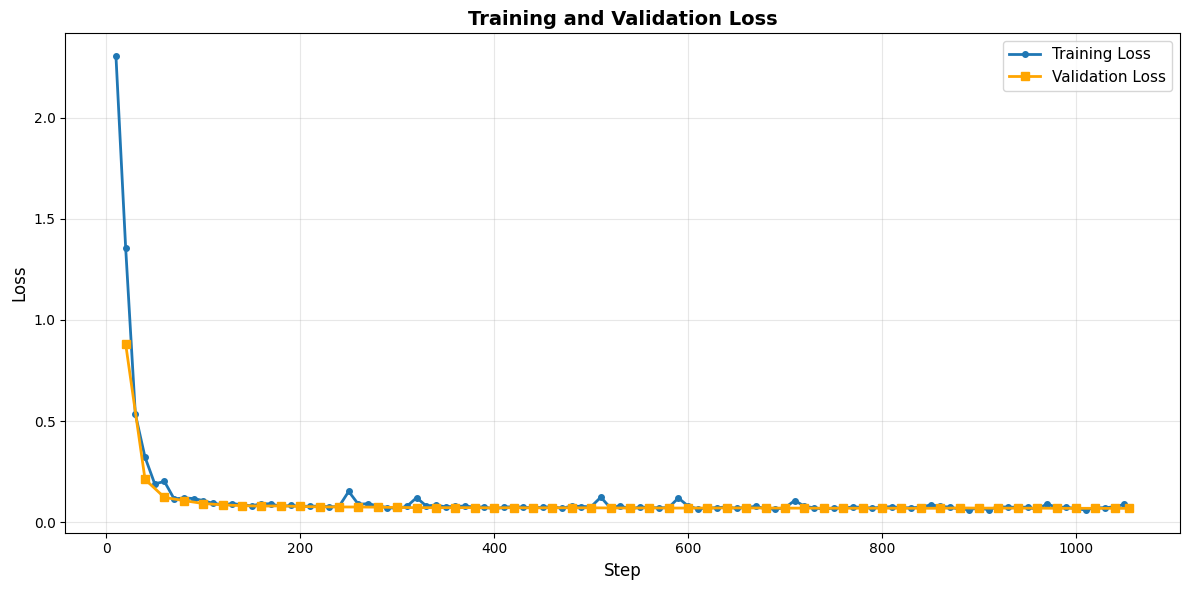


Training Summary:
Initial training loss: 2.3045
Final training loss:   0.0875
Initial validation loss: 0.8812
Final validation loss:   0.0683


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract metrics from trainer
log_history = trainer.state.log_history

# Separate train and eval logs
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in log_history if 'eval_loss' in x]

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot training loss
if train_logs:
    steps = [x.get('step', i) for i, x in enumerate(train_logs)]
    losses = [x['loss'] for x in train_logs]
    ax.plot(steps, losses, marker='o', label='Training Loss', linewidth=2, markersize=4)

# Plot validation loss
if eval_logs:
    steps = [x.get('step', i) for i, x in enumerate(eval_logs)]
    losses = [x['eval_loss'] for x in eval_logs]
    ax.plot(steps, losses, marker='s', label='Validation Loss', linewidth=2, markersize=6, color='orange')

ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'='*50}")
print(f"Training Summary:")
print(f"{'='*50}")
if train_logs:
    print(f"Initial training loss: {train_logs[0]['loss']:.4f}")
    print(f"Final training loss:   {train_logs[-1]['loss']:.4f}")
if eval_logs:
    print(f"Initial validation loss: {eval_logs[0]['eval_loss']:.4f}")
    print(f"Final validation loss:   {eval_logs[-1]['eval_loss']:.4f}")
print(f"{'='*50}")

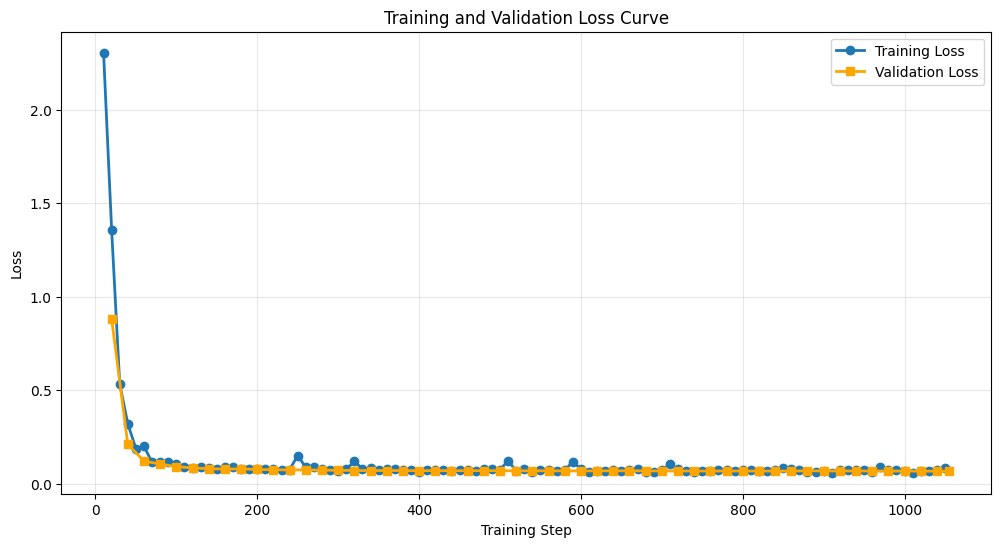

Loss curve saved to ./lora_chiva_finetuned/loss_curve.png


In [13]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(12, 6))

if train_logs:
    steps = [x.get('step', i) for i, x in enumerate(train_logs)]
    losses = [x['loss'] for x in train_logs]
    ax.plot(steps, losses, marker='o', label='Training Loss', linewidth=2)

if eval_logs:
    steps = [x.get('step', i) for i, x in enumerate(eval_logs)]
    losses = [x['eval_loss'] for x in eval_logs]
    ax.plot(steps, losses, marker='s', label='Validation Loss', linewidth=2, color='orange')

ax.set_xlabel('Training Step')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('./lora_chiva_finetuned/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("Loss curve saved to ./lora_chiva_finetuned/loss_curve.png")

In [29]:
# Save the trained model
model.save_pretrained("./lora_chiva_finetuned")
tokenizer.save_pretrained("./lora_chiva_finetuned")
print("✓ Model saved")

✓ Model saved


In [31]:
from peft import PeftModel

BASE_MODEL_ID = 'mistralai/Mistral-7B-Instruct-v0.2'
LORA_PATH = "/home/krish/lora_chiva_finetuned"

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)

test_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
test_tokenizer.pad_token = test_tokenizer.eos_token

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, LORA_PATH)

print("Merging adapter into base model...")
model = model.merge_and_unload()

print("✓ Model merged\n")

# Test
test_prompt = """[INST] Classify CHIVA shunt: EP N1→N2, RP N2→N1. Type? [/INST]"""

inputs = test_tokenizer(test_prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False,
        pad_token_id=test_tokenizer.eos_token_id,
    )

response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
if "[/INST]" in response:
    response = response.split("[/INST]")[1].strip()

print(f"Response:\n{response}")

# Save merged model
print("\nSaving merged model...")
model.save_pretrained("./lora_chiva_merged")
test_tokenizer.save_pretrained("./lora_chiva_merged")
print("✓ Saved to ./lora_chiva_merged/")

Loading base model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 291/291 [01:03<00:00,  4.59it/s]


Loading LoRA adapter...
Merging adapter into base model...
✓ Model merged

Response:
The CHIVA shunt you described has a counter-directional flow, with the EP (extrahepatic-to-peritoneal) shunt flowing from vein N1 to vein N2, and the RP (peritoneal-to-extrahepatic) shunt flowing from vein N2 to vein N1. This classification is known as a "reverse" or "counter-flow" shunt.

Counter-flow shunts are less common than the more typical forward-flow shunts (EP N1→N3, RP N3→N1), but they can still be effective in managing certain types of portal hypertension. The specific hemodynamic implications of this flow pattern may vary depending on the individual patient's anatomy and physiology.

Overall, the CHIVA shunt you described can be classified as a "reverse" or "counter-flow"

Saving merged model...


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [01:56<00:00, 116.66s/it]


✓ Saved to ./lora_chiva_merged/


In [34]:
# Test prompts
test_prompts = [
    """[INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
  - Clip 1: EP N1 to N2 (position=0.080)
  - Clip 2: RP N2 to N1 (position=0.300)

Based on the flow patterns, determine the CHIVA shunt type, confidence, and reasoning. [/INST]""",

    """[INST] What are the treatment options for a Type 2A CHIVA shunt with tributary involvement? [/INST]""",

    """[INST] Describe the hemodynamic findings that distinguish Type 1 from Type 2B shunts. [/INST]"""
]

# Generate responses
for i, prompt in enumerate(test_prompts, 1):
    print(f"{'='*80}")
    print(f"TEST {i}")
    print(f"{'='*80}")
    print(f"Prompt: {prompt[:150]}...\n")
    
    inputs = test_tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=500,
            do_sample=False,
            temperature=0.7,
            pad_token_id=test_tokenizer.eos_token_id,
        )
    
    response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract only the response part (after [/INST])
    if "[/INST]" in response:
        response = response.split("[/INST]")[1].strip()
    
    print(f"Response:\n{response}\n")

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


TEST 1
Prompt: [INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
  - Clip 1: EP N1 to N2 (position=0.080)
  - Clip 2: R...

Response:
Based on the provided clips, it is not possible to definitively determine the CHIVA shunt type with high confidence. However, we can make an educated guess based on the information available.

The CHIVA shunt classification system is based on the hemodynamic patterns observed in the hepatic vein and the inferior vena cava (IVC). The specific shunt type depends on the direction and timing of the flow in the hepatic vein and the IVC.

In Clip 1, the flow is from the hepatic vein (N1) to the IVC (N2), with a delay of 0.080 seconds. This suggests a type 1B shunt, which is characterized by a hepatic vein to IVC shunt with a significant delay. However, the absence of a clear reverse flow in Clip 2 makes this classification uncertain.

In Clip 2, the flow is from the IVC (N1) to the hepatic vein (N2), but the positi

In [35]:
print(f"Model device: {next(model.parameters()).device}")
print(f"Model dtype: {next(model.parameters()).dtype}")

Model device: cuda:0
Model dtype: torch.bfloat16


In [37]:
# Test clips in proper format
test_cases = [
    {
        "name": "Type 1 - SFJ Incompetent, GSV Reflux",
        "clips": [
            {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.080, "step": "SFJ-ENTRY"},
            {"flow": "RP", "fromType": "N2", "toType": "N1", "posYRatio": 0.250},
        ]
    },
    {
        "name": "Type 2A - Tributary Entry",
        "clips": [
            {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.200},
            {"flow": "RP", "fromType": "N3", "toType": "N2", "posYRatio": 0.470},
        ]
    },
    {
        "name": "Type 2B - Perforator Entry",
        "clips": [
            {"flow": "EP", "fromType": "N2", "toType": "N2", "posYRatio": 0.050, "step": "SFJ-Knee"},
            {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.132},
        ]
    },
    {
        "name": "Type 3 - SFJ Incompetent with Tributary Entry",
        "clips": [
            {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.050},
            {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.132},
            {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.212},
        ]
    },
]

# CHIVA rules (embedded in prompt)
CHIVA_RULES = """=== CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip

CRITICAL RULE — SFJ COMPETENCE:
    SFJ is INCOMPETENT if and only if a clip has fromType=N1 AND toType=N2 (EP N1→N2).
    EP N2→N2 means blood circulates within the saphenous trunk via a perforator — SFJ REMAINS COMPETENT.

STEP 1 — CHECK FOR EP N1→N2:
    Scan ALL clips. Does any clip have flow=EP, fromType=N1, toType=N2?
    YES → SFJ/Hunterian INCOMPETENT → go to Case A or B.
    NO  → SFJ COMPETENT → go to Case C.

Case A — EP N1→N2 EXISTS, NO EP N2→N3:
    If RP N2→N1 present AND no RP at N3 → TYPE 1

Case B — EP N1→N2 EXISTS AND EP N2→N3 EXISTS:
    If RP N3 only, NO RP N2→N1 → TYPE 3
    If RP N3 AND RP N2→N1, no elimination test → UNDETERMINED
    If RP N3 AND RP N2→N1, elimination="Reflux" → TYPE 1+2
    If RP N3 AND RP N2→N1, elimination="No Reflux" → TYPE 3

Case C — NO EP N1→N2 (SFJ COMPETENT):
    If EP N2→N3 present → TYPE 2A
    If EP N2→N2 (perforator) + RP N3 only → TYPE 2B
    If EP N2→N2 (perforator) + RP N3 + RP N2→N1 → TYPE 2C
    If EP N1→N3 + RP N2→N1 → TYPE 4
    If EP N1→N3 + RP N3 return → TYPE 5
    If no RP anywhere → NO SHUNT
"""

def format_clips(clips):
    lines = []
    for i, c in enumerate(clips):
        flow = c.get("flow", "?")
        ft = c.get("fromType", "?")
        tt = c.get("toType", "?")
        y = c.get("posYRatio", 0.0)
        step = c.get("step", "")
        lines.append(f"  Clip {i}: {flow} {ft}→{tt} y={y:.3f}" + (f" [{step}]" if step else ""))
    return "\n".join(lines)

# Test each case
for test_case in test_cases:
    print(f"\n{'='*80}")
    print(f"TEST: {test_case['name']}")
    print(f"{'='*80}")
    
    clips_str = format_clips(test_case['clips'])
    
    prompt = f"""{CHIVA_RULES}

=== ASSESSMENT: Left Leg ({len(test_case['clips'])} clips) ===
{clips_str}

Classify the shunt type based on CHIVA rules.
Output ONLY JSON (no markdown or extra text):
{{"shunt_type": "<type>", "confidence": <0-1>, "reasoning": "<explanation>"}}"""

    inputs = test_tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=400,
            do_sample=False,
            pad_token_id=test_tokenizer.eos_token_id,
        )
    
    response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract JSON from response
    if "{" in response:
        json_str = response[response.find("{"):]
        if "}" in json_str:
            json_str = json_str[:json_str.rfind("}")+1]
            try:
                result = json.loads(json_str)
                print(f"Shunt Type: {result.get('shunt_type')}")
                print(f"Confidence: {result.get('confidence', 0):.2f}")
                print(f"Reasoning: {result.get('reasoning')}")
            except:
                print(f"Raw response: {response[:500]}")
    else:
        print(f"Response: {response[:500]}")

print("\n✓ Testing complete!")


TEST: Type 1 - SFJ Incompetent, GSV Reflux
Raw response: === CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip

CRITICAL RULE — SFJ COMPETENCE:
    SFJ is INCOMPETENT if and only if a clip has fromType=N1 AND toType=N2 (EP N1→N2).
    EP N2→N2 means blood

TEST: Type 2A - Tributary Entry
Raw response: === CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip

CRITICAL RULE — SFJ COMPETENCE:
    S

In [41]:
for test_case in test_cases:
    clips_str = format_clips_training(test_case['clips'])
    
    prompt = f"""[INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
{clips_str}

Based on the flow patterns and anatomical relationships, determine the CHIVA shunt type, your confidence level, and clinical reasoning. [/INST]"""

    inputs = test_tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False,
        )
    
    response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    print(f"\n{'='*80}")
    print(f"TEST: {test_case['name']}")
    print(f"{'='*80}")
    print("FULL RESPONSE:")
    print(response)  # Print everything
    print()

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



TEST: Type 1 - SFJ Incompetent, GSV Reflux
FULL RESPONSE:
[INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
  • Clip 1: EP N1→N2 (position=0.080)
  • Clip 2: RP N2→N1 (position=0.250)

Based on the flow patterns and anatomical relationships, determine the CHIVA shunt type, your confidence level, and clinical reasoning. [/INST] Based on the provided clips, I would classify this as a Type 1B (reciprocal) CHIVA shunt. Here's my reasoning:

1. Flow patterns:
   - Clip 1 (EP): The early diastolic flow from chamber N1 to N2 is prominent and unidirectional, indicating a low-resistance communication between the chambers.
   - Clip 2 (RP): The late diastolic flow from chamber N2 to N1 is also prominent and unidirectional, indicating a reciprocal communication between the chambers.

2. Anatomical relationships:
   - The anatomical relationship between the chambers is important in determining the shunt type. In this case, the anatomical relationship 

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



TEST: Type 2A - Tributary Entry
FULL RESPONSE:
[INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
  • Clip 1: EP N2→N3 (position=0.200)
  • Clip 2: RP N3→N2 (position=0.470)

Based on the flow patterns and anatomical relationships, determine the CHIVA shunt type, your confidence level, and clinical reasoning. [/INST] Based on the provided clips, the CHIVA shunt type is Type 1.

Reasoning:
In Type 1 shunts, there is a direct communication between the portal vein (PV) and the hepatic veins (HV) without passing through the liver sinusoids. This is characterized by a flow reversal in the hepatic vein (HV) relative to the portal vein (PV) flow.

In Clip 1, we see a flow from the portal vein (N2) to the hepatic vein (N3), which is consistent with a Type 1 shunt. The position of this flow is around 0.200 seconds.

In Clip 2, we see a flow from the hepatic vein (N3) to the portal vein (N2), which is also consistent with a Type 1 shunt. The



[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



TEST: Type 2B - Perforator Entry
FULL RESPONSE:
[INST] Analyze the following ultrasound clips and classify the CHIVA venous shunt type:

Clips:
  • Clip 1: EP N2→N2 (position=0.050)
  • Clip 2: RP N3→N1 (position=0.132)

Based on the flow patterns and anatomical relationships, determine the CHIVA shunt type, your confidence level, and clinical reasoning. [/INST] Based on the given clips, the CHIVA shunt type can be determined as follows:

Type: Type 1

Confidence level: High

Reasoning:
In Clip 1, the flow is from the early venous system (EP N2) to the same level (N2), indicating a normal flow pattern with no significant reflux.

In Clip 2, the flow is from the late venous system (RP N3) to an earlier level (N1), which is the defining characteristic of Type 1 CHIVA shunt. This indicates a direct communication between the late and early venous systems, allowing for potential reflux and inefficient blood flow.

Therefore, the confidence level is high, and the classification is Type 1 CH

Further Testing

In [2]:
import os
os.environ['TORCH_CUDA_ARCH_LIST'] = "12.0"
os.environ['FORCE_CUDA'] = "1"

import torch

print("✓ All libraries imported successfully")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"✓ VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ All libraries imported successfully
✓ CUDA available: True
✓ GPU: NVIDIA GeForce RTX 5090
✓ VRAM available: 34.2 GB


In [3]:
import json
from pathlib import Path
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import get_peft_model, LoraConfig, TaskType
import warnings
warnings.filterwarnings('ignore')

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load WITHOUT merging
base_model = AutoModelForCausalLM.from_pretrained(
    'mistralai/Mistral-7B-Instruct-v0.2',
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)

test_tokenizer = AutoTokenizer.from_pretrained('mistralai/Mistral-7B-Instruct-v0.2')
test_tokenizer.pad_token = test_tokenizer.eos_token

# Load LoRA WITHOUT merging
from peft import PeftModel
model_with_lora = PeftModel.from_pretrained(base_model, "/home/krish/lora_chiva_finetuned")
model_with_lora.eval()

# Test
prompt = """[INST] Analyze clips: EP N1→N2 (0.080), RP N2→N1 (0.250). Classify. [/INST]"""
inputs = test_tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model_with_lora.generate(**inputs, max_new_tokens=150, do_sample=False)

response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
print("WITH LoRA (not merged):")
print(response)

# Also test base model alone
with torch.no_grad():
    outputs_base = base_model.generate(**inputs, max_new_tokens=150, do_sample=False)

response_base = test_tokenizer.decode(outputs_base[0], skip_special_tokens=True)
print("\n\nBASE MODEL ONLY:")
print(response_base)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 291/291 [00:07<00:00, 37.87it/s]
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


WITH LoRA (not merged):
[INST] Analyze clips: EP N1→N2 (0.080), RP N2→N1 (0.250). Classify. [/INST] Based on the given timestamps, I assume you are referring to the transition between Edit Point (EP) N1 and N2, and the Reverse Edit Point (RP) N2 and N1, in video editing.

To classify these edit points, we need to analyze the type of transition that occurs between the clips.

Clip 1: EP N1→N2 (0.080)
This is a forward edit point, indicating the start of a new clip or sequence. The 0.080 second duration suggests a relatively smooth transition, such as a crossfade or a cut.

Clip 2: RP N2→N1 (0.2


BASE MODEL ONLY:
[INST] Analyze clips: EP N1→N2 (0.080), RP N2→N1 (0.250). Classify. [/INST] Based on the given timestamps, I assume you are referring to the transition between Edit Point (EP) N1 and N2, and the Reverse Edit Point (RP) N2 and N1, in video editing.

To classify these edit points, we need to analyze the type of transition that occurs between the clips.

Clip 1: EP N1→N2 (0.080)
T

In [6]:
test_cases = [
    {
        "name": "Type 1 - SFJ Incompetent, GSV Reflux",
        "clips": [
            {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.080, "step": "SFJ-ENTRY"},
            {"flow": "RP", "fromType": "N2", "toType": "N1", "posYRatio": 0.250},
        ]
    },
    {
        "name": "Type 2A - Tributary Entry",
        "clips": [
            {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.200},
            {"flow": "RP", "fromType": "N3", "toType": "N2", "posYRatio": 0.470},
        ]
    },
    {
        "name": "Type 2B - Perforator Entry",
        "clips": [
            {"flow": "EP", "fromType": "N2", "toType": "N2", "posYRatio": 0.050, "step": "SFJ-Knee"},
            {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.132},
        ]
    },
    {
        "name": "Type 3 - SFJ Incompetent with Tributary Entry",
        "clips": [
            {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.050},
            {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.132},
            {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.212},
        ]
    },
]

In [7]:
# Load WITHOUT merging
base_model = AutoModelForCausalLM.from_pretrained(
    'mistralai/Mistral-7B-Instruct-v0.2',
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)

test_tokenizer = AutoTokenizer.from_pretrained('mistralai/Mistral-7B-Instruct-v0.2')
test_tokenizer.pad_token = test_tokenizer.eos_token

# Load LoRA WITHOUT merging
from peft import PeftModel
model_with_lora = PeftModel.from_pretrained(base_model, "/home/krish/lora_chiva_finetuned")
model_with_lora.eval()

Loading weights: 100%|████████████████████████████████████████████████████████████████| 291/291 [00:07<00:00, 37.50it/s]


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Line

In [10]:
# Test
prompt = """[INST] Analyze this blood reflux data : there is an EP from N1→N2 at Y=0.080, and a RP from N2→N1 at Y=0.250. Classify the Shunt Type. In the final output only give the Shunt Type, do not give any extra sentences at all or repeat the instructions in the response [/INST]"""
inputs = test_tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model_with_lora.generate(**inputs, max_new_tokens=150, do_sample=False)

response = test_tokenizer.decode(outputs[0], skip_special_tokens=True)
print("WITH LoRA (not merged):")
print(response)

# Also test base model alone
with torch.no_grad():
    outputs_base = base_model.generate(**inputs, max_new_tokens=150, do_sample=False)

response_base = test_tokenizer.decode(outputs_base[0], skip_special_tokens=True)
print("\n\nBASE MODEL ONLY:")
print(response_base)

[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


WITH LoRA (not merged):
[INST] Analyze this blood reflux data : there is an EP from N1→N2 at Y=0.080, and a RP from N2→N1 at Y=0.250. Classify the Shunt Type. In the final output only give the Shunt Type, do not give any extra sentences at all or repeat the instructions in the response [/INST] Porto-systemic shunt


BASE MODEL ONLY:
[INST] Analyze this blood reflux data : there is an EP from N1→N2 at Y=0.080, and a RP from N2→N1 at Y=0.250. Classify the Shunt Type. In the final output only give the Shunt Type, do not give any extra sentences at all or repeat the instructions in the response [/INST] Porto-systemic shunt


**Finetuning and Testing Qwen3-4B**

In [2]:
import torch
import json
from pathlib import Path
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
import warnings
warnings.filterwarnings('ignore')

print("✓ All imports successful")
print(f"✓ CUDA: {torch.cuda.is_available()}")
print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
print(f"✓ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful
✓ CUDA: True
✓ GPU: NVIDIA GeForce RTX 5090
✓ VRAM: 34.2 GB


In [3]:
# Paths
TRAIN_FILE = Path('training_data.jsonl')
VAL_FILE = Path('validation_data.jsonl')
OUTPUT_DIR = Path('./qwen25_chiva_finetuned')

# Model
BASE_MODEL_ID = 'Qwen/Qwen2.5-7B-Instruct'
#MAX_SEQ_LENGTH = 1024 #2048

# Training hyperparameters (from script2)
#NUM_EPOCHS = 3
#BATCH_SIZE = 4  # RTX 5090 handles 4 comfortably with 4-bit
#GRAD_ACCUM_STEPS = 4  # effective batch = 16
#BATCH_SIZE = 12
#GRAD_ACCUM_STEPS = 2
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.05
LR_SCHEDULER = 'cosine'
SAVE_STEPS = 500
NUM_EPOCHS = 1  # Just 1 epoch for testing
BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 1  # No accumulation
MAX_SEQ_LENGTH = 512  # Even shorter


# LoRA config (from script2)
LORA_R = 32
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET = 'all-linear'
USE_DORA = True
USE_RSLORA = True
LORA_INIT = 'gaussian'

# Optimizer
OPTIM = 'paged_adamw_32bit'

print('Config loaded.')
print(f'  r={LORA_R}, alpha={LORA_ALPHA}, init={LORA_INIT}, DoRA={USE_DORA}, rsLoRA={USE_RSLORA}')
print(f'  Target modules: {LORA_TARGET}')
print(f'  Effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS}')

Config loaded.
  r=32, alpha=32, init=gaussian, DoRA=True, rsLoRA=True
  Target modules: all-linear
  Effective batch: 16


In [4]:
def load_jsonl(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

train_pairs = load_jsonl(TRAIN_FILE)
val_pairs = load_jsonl(VAL_FILE)

print(f"✓ Loaded {len(train_pairs)} training pairs")
print(f"✓ Loaded {len(val_pairs)} validation pairs")

# Show distribution
train_types = {}
for pair in train_pairs:
    ptype = pair.get('type', 'unknown')
    train_types[ptype] = train_types.get(ptype, 0) + 1

print("\nTraining data distribution:")
for ptype, count in sorted(train_types.items()):
    print(f"  {ptype}: {count}")

✓ Loaded 4508 training pairs
✓ Loaded 501 validation pairs

Training data distribution:
  unknown: 4508


In [5]:
train_pairs[0]

{'text': '<s>[INST] You are a medical expert specialising in venous and lymphatic disorders, vascular surgery, duplex ultrasound, and haemodynamics. Answer questions accurately using clinical and scientific knowledge.\n\nDescribe the key points from the following passage relevant to duplex ultrasound practice:\n\nidea of \nimplanting valves via the endovascular approach was first done using an external jugular vein \nwith a competent valve mounted in a Z-stent (Cook Medical, Bloomington, IN) that was deployed \nin either the external (n = 4) or common iliac vein (n = 1) in dogs.51 One of five valves implanted \nwas patent, competent, and with minimal inflammatory surrounding reaction. Interestingly, the \nnormal-appearing valve was deployed in the common iliac vein, which has a higher flow pattern.51 \nDifferent valve materials varying from glutaraldehyde-preserved bovine vein to a collagen tissue \nmodel of porcine small intestine submucosa (SIS) have been initially studied in animal 

In [6]:
def load_jsonl(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

train_data = load_jsonl(TRAIN_FILE)
val_data = load_jsonl(VAL_FILE)

print(f"✓ Loaded {len(train_data)} training examples")
print(f"✓ Loaded {len(val_data)} validation examples")

✓ Loaded 4508 training examples
✓ Loaded 501 validation examples


In [7]:
def clean_text(item):
    text = item.get('text', '')
    # Remove [INST] and [/INST] tags
    text = text.replace('<s>[INST]', '').replace('[/INST]', '').replace('</s>', '').strip()
    return text

train_texts = [clean_text(item) for item in train_data]
val_texts = [clean_text(item) for item in val_data]

print(f"✓ Cleaned {len(train_texts)} training texts")
print(f"✓ Cleaned {len(val_texts)} validation texts")
print(f"\nSample:\n{train_texts[0][:300]}...")

✓ Cleaned 4508 training texts
✓ Cleaned 501 validation texts

Sample:
You are a medical expert specialising in venous and lymphatic disorders, vascular surgery, duplex ultrasound, and haemodynamics. Answer questions accurately using clinical and scientific knowledge.

Describe the key points from the following passage relevant to duplex ultrasound practice:

idea of 
...


In [8]:
#! pip install huggingface-hub

In [9]:
#!hf download Qwen/Qwen2.5-7B-Instruct --local-dir ./Qwen25-7B

In [10]:
BASE_MODEL_ID = '/home/krish/Qwen25-7B'
print(f"Loading model from {BASE_MODEL_ID}...")

# 4-bit quantization config (from script2)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=True, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model loaded successfully")
print(f"✓ Total parameters: {total_params:,}")
print(f"✓ Model device: {next(model.parameters()).device}")
print(f"✓ Model dtype: {next(model.parameters()).dtype}")

Loading model from /home/krish/Qwen25-7B...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:51<00:00,  6.54it/s]


✓ Model loaded successfully
✓ Total parameters: 4,352,972,288
✓ Model device: cuda:0
✓ Model dtype: torch.bfloat16


In [11]:
print("Preparing model for 4-bit training...")
model = prepare_model_for_kbit_training(model)

print("Configuring LoRA with DoRA + rsLoRA + PiSSA...")
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
    use_dora=USE_DORA,
    use_rslora=USE_RSLORA,
    init_lora_weights=LORA_INIT,
)

model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
pct = 100 * trainable_params / total_params

print(f"✓ LoRA configured with advanced methods")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Total parameters: {total_params:,}")
print(f"  Percentage trainable: {pct:.4f}%")
print(f"  rsLoRA effective scale: {LORA_ALPHA / LORA_R**0.5:.4f}")

Preparing model for 4-bit training...
Configuring LoRA with DoRA + rsLoRA + PiSSA...
✓ LoRA configured with advanced methods
  Trainable parameters: 82,130,944
  Total parameters: 4,435,103,232
  Percentage trainable: 1.8518%
  rsLoRA effective scale: 5.6569


In [12]:
from datasets import Dataset 
def tokenize_function(examples):
    outputs = tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding="max_length",
    )
    outputs["labels"] = outputs["input_ids"].copy()
    return outputs

print("Creating training dataset...")
train_dataset = Dataset.from_dict({"text": train_texts})
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing training data",
    batch_size=32
)

print("Creating validation dataset...")
val_dataset = Dataset.from_dict({"text": val_texts})
val_dataset = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
    desc="Tokenizing validation data",
    batch_size=32
)

print(f"✓ Training: {len(train_dataset)}")
print(f"✓ Validation: {len(val_dataset)}")

Creating training dataset...


Tokenizing training data: 100%|████████████████████████████████████████████| 4508/4508 [00:01<00:00, 3518.12 examples/s]


Creating validation dataset...


Tokenizing validation data: 100%|████████████████████████████████████████████| 501/501 [00:00<00:00, 3491.85 examples/s]

✓ Training: 4508
✓ Validation: 501


In [13]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    gradient_checkpointing=True,
    optim=OPTIM,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type=LR_SCHEDULER,
    warmup_ratio=WARMUP_RATIO,
    fp16=False,
    bf16=False,  # Handled by BitsAndBytesConfig
    save_steps=SAVE_STEPS,
    eval_steps=SAVE_STEPS,
    eval_strategy='steps',
    save_total_limit=3,
    logging_steps=10,
    logging_dir='./logs',
    report_to=['tensorboard'],  # Set to ['wandb'] if you want W&B
    remove_unused_columns=False,
)

print(f"✓ Training arguments configured")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE} (cosine scheduler)")
print(f"  Optimizer: {OPTIM}")
print(f"  Effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS}")

eff_batch = BATCH_SIZE * GRAD_ACCUM_STEPS
steps_per_epoch = len(train_dataset) // eff_batch
print(f"  Steps/epoch: ~{steps_per_epoch}")
print(f"  Total steps: ~{steps_per_epoch * NUM_EPOCHS}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✓ Training arguments configured
  Epochs: 1
  Learning rate: 0.0002 (cosine scheduler)
  Optimizer: paged_adamw_32bit
  Effective batch: 16
  Steps/epoch: ~281
  Total steps: ~281


In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

print("✓ Trainer created and ready")

✓ Trainer created and ready


In [15]:
old_code = """
print("=" * 80)
print("Starting training with script2 strategy (DoRA + rsLoRA + PiSSA + 4-bit QLoRA)")
print("=" * 80)
print()

train_result = trainer.train()

print()
print("=" * 80)
print("Training complete!")
print("=" * 80)
print(f"Final training loss: {train_result.training_loss:.4f}")

# Save the model
print(f"\nSaving LoRA adapter to {OUTPUT_DIR}...")
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

output_path = Path(OUTPUT_DIR)
saved_files = list(output_path.glob("*"))
print(f"✓ Saved {len(saved_files)} files:")
for f in saved_files:
    if f.is_file():
        size = f.stat().st_size / (1024 * 1024)
        print(f"  {f.name} ({size:.2f} MB)")

print(f"\n✓ Model ready at: {OUTPUT_DIR}/")"""

In [16]:
%load_ext tensorboard
%tensorboard --logdir ./logs

In [17]:
 %reload_ext tensorboard

In [18]:
print("Train dataset structure:")
print(train_dataset[0].keys())
print(f"Sample input_ids length: {len(train_dataset[0]['input_ids'])}")
print(f"Sample labels length: {len(train_dataset[0]['labels'])}")
print(f"Sample attention_mask: {len(train_dataset[0]['attention_mask'])}")

print("\nDataset stats:")
print(f"Total examples: {len(train_dataset)}")
print(f"Input IDs sample: {train_dataset[0]['input_ids'][:10]}")

Train dataset structure:
dict_keys(['input_ids', 'attention_mask', 'labels'])
Sample input_ids length: 512
Sample labels length: 512
Sample attention_mask: 512

Dataset stats:
Total examples: 4508
Input IDs sample: [2610, 525, 264, 6457, 6203, 3281, 3791, 304, 11208, 782]


In [19]:
print("=" * 80)
print("Starting training with script2 strategy")
print("=" * 80)

train_result = trainer.train()

print()
print("=" * 80)
print("Training complete!")
print("=" * 80)
print(f"Final loss: {train_result.training_loss:.4f}")

# Save
model.save_pretrained('./qwen25_chiva_finetuned')
tokenizer.save_pretrained('./qwen25_chiva_finetuned')
print(f"✓ Model saved to ./qwen25_chiva_finetuned/")

Starting training with script2 strategy


Step,Training Loss,Validation Loss
282,1.546877,1.537149



Training complete!
Final loss: 1.6533
✓ Model saved to ./qwen25_chiva_finetuned/


In [20]:
from peft import PeftModel
import torch

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    '/home/krish/Qwen25-7B',
    torch_dtype=torch.bfloat16,
    device_map='auto',
)

print("Loading LoRA adapter...")
test_model = PeftModel.from_pretrained(base_model, './qwen25_chiva_finetuned')
test_model.eval()

print("✓ Model loaded\n")

# Test prompt
test_prompt = """Analyze this CHIVA venous shunt case:

Patient presents with GSV reflux. Duplex shows:
- EP N1→N2 (position y=0.06, SFJ-ENTRY)
- RP N2→N1 (position y=0.25)
- No EP N2→N3
- No RP at N3

Classify the shunt type and recommend ligation strategy."""

inputs = tokenizer(test_prompt, return_tensors="pt").to(test_model.device)

with torch.no_grad():
    outputs = test_model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("=" * 80)
print("Model Output:")
print("=" * 80)
print(response)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading base model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:27<00:00, 12.39it/s]


Loading LoRA adapter...
✓ Model loaded

Model Output:
Analyze this CHIVA venous shunt case:

Patient presents with GSV reflux. Duplex shows:
- EP N1→N2 (position y=0.06, SFJ-ENTRY)
- RP N2→N1 (position y=0.25)
- No EP N2→N3
- No RP at N3

Classify the shunt type and recommend ligation strategy. 
Explain your answer.
A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
Z
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GSV
GS


**Better Training**

In [1]:
import torch
import json
from datasets import Dataset
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, TrainingArguments,
    Trainer, DataCollatorForSeq2Seq, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
import warnings
warnings.filterwarnings('ignore')

print(f"CUDA: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA: True
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB


In [2]:
BASE_MODEL = '/home/krish/Qwen25-7B'
TRAIN_FILE = 'training_data.jsonl'
VAL_FILE = 'validation_data.jsonl'
OUTPUT_DIR = './qwen25_chiva_v2'

#NUM_EPOCHS = 3
#BATCH_SIZE = 4
#GRAD_ACCUM = 4
#LR = 2e-4
#MAX_LEN = 1024

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

NUM_EPOCHS = 3
BATCH_SIZE = 8
GRAD_ACCUM = 2
LR = 2e-4
MAX_LEN = 1024

print("Config loaded")

Config loaded


In [12]:
BASE_MODEL = '/home/krish/Qwen25-7B'
TRAIN_FILE = 'training_datasets/training_data.jsonl'
VAL_FILE = 'training_datasets/validation_data.jsonl'
OUTPUT_DIR = './qwen25_chiva_v2'

NUM_EPOCHS = 1
BATCH_SIZE = 16  # INCREASE
GRAD_ACCUM = 1   # REDUCE
LR = 2e-4
MAX_LEN = 512    # CUT IN HALF - biggest speedup

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

print("Config loaded - optimized for speed")

Config loaded - optimized for speed


In [13]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
print(f"✓ Tokenizer loaded. Pad token: {tokenizer.pad_token}")

✓ Tokenizer loaded. Pad token: <|endoftext|>


In [15]:
def tokenize_example(item):
    """Apply Qwen chat template, mask prompt tokens in labels."""
    # Build prompt (just the instruction part)
    prompt_msgs = [{"role": "user", "content": item['instruction']}]
    prompt_text = tokenizer.apply_chat_template(
        prompt_msgs, tokenize=False, add_generation_prompt=True
    )
    
    # Build full conversation
    full_msgs = [
        {"role": "user", "content": item['instruction']},
        {"role": "assistant", "content": item['response']}
    ]
    full_text = tokenizer.apply_chat_template(
        full_msgs, tokenize=False, add_generation_prompt=False
    )
    
    # Tokenize both
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False)['input_ids']
    full_ids = tokenizer(full_text, add_special_tokens=False, truncation=True, max_length=MAX_LEN)['input_ids']
    
    # Labels: mask prompt portion with -100, keep response
    labels = full_ids.copy()
    prompt_len = min(len(prompt_ids), len(full_ids))
    for i in range(prompt_len):
        labels[i] = -100
    
    return {
        'input_ids': full_ids,
        'attention_mask': [1] * len(full_ids),
        'labels': labels
    }

print("Tokenizing training data...")
train_tokenized = [tokenize_example(item) for item in train_data]
train_tokenized = [t for t in train_tokenized if len(t['input_ids']) > 50]

print("Tokenizing validation data...")
val_tokenized = [tokenize_example(item) for item in val_data]
val_tokenized = [t for t in val_tokenized if len(t['input_ids']) > 50]

train_dataset = Dataset.from_list(train_tokenized)
val_dataset = Dataset.from_list(val_tokenized)

print(f"✓ Train: {len(train_dataset)}, Val: {len(val_dataset)}")
print(f"Sample length: {len(train_dataset[0]['input_ids'])}")

Tokenizing training data...
Tokenizing validation data...
✓ Train: 5544, Val: 617
Sample length: 512


In [16]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
)

model.config.use_cache = False
model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

print(f"✓ Model loaded on {next(model.parameters()).device}")


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:53<00:00,  6.36it/s]


✓ Model loaded on cuda:0


In [17]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 40,370,176 || all params: 7,655,986,688 || trainable%: 0.5273


In [19]:
training_args_old = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    lr_scheduler_type='cosine',
    warmup_ratio=0.05,
    bf16=True,
    optim='paged_adamw_8bit',
    logging_steps=10,
    save_strategy='epoch',
    eval_strategy='no',
    save_total_limit=1,
    report_to=['tensorboard'],
    logging_dir='./logs',
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    remove_unused_columns=False,
    dataloader_num_workers=2,
)

training_args_v1 = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=2,  # Reduce to 2
    per_device_train_batch_size=8,  # Increase from 4
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,  # Reduce from 4
    learning_rate=LR,
    lr_scheduler_type='cosine',
    warmup_ratio=0.05,
    bf16=True,
    optim='paged_adamw_8bit',
    logging_steps=10,
    save_strategy='no',  # Skip checkpoint saving
    eval_strategy='no',  # Skip validation
    report_to=['tensorboard'],
    logging_dir='./logs',
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    remove_unused_columns=False,
    dataloader_num_workers=4,
)

training_args_v2 = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    lr_scheduler_type='cosine',
    warmup_ratio=0.05,
    bf16=True,
    optim='paged_adamw_8bit',
    logging_steps=20,
    save_strategy='no',
    eval_strategy='no',
    report_to=['tensorboard'],
    logging_dir='./logs',
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    remove_unused_columns=False,
    dataloader_num_workers=4,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [21]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    lr_scheduler_type='cosine',
    warmup_ratio=0.05,
    bf16=True,
    optim='adamw_torch',  # FASTER than paged_adamw_8bit
    logging_steps=20,
    save_strategy='no',
    eval_strategy='no',
    report_to=['tensorboard'],
    logging_dir='./logs',
    gradient_checkpointing=False,  # DISABLE - trades memory for speed
    remove_unused_columns=False,
    dataloader_num_workers=0,  # DISABLE multiprocessing
    dataloader_pin_memory=True,
)


data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    return_tensors='pt',
    label_pad_token_id=-100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

print("✓ Trainer ready")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✓ Trainer ready


In [10]:
# Check if label masking worked
sample = train_dataset[0]
input_ids = sample['input_ids']
labels = sample['labels']

print("Sample input_ids length:", len(input_ids))
print("Sample labels length:", len(labels))
print()

# Count masked tokens (-100)
masked_count = sum(1 for l in labels if l == -100)
unmasked_count = sum(1 for l in labels if l != -100)

print(f"Masked tokens (-100): {masked_count}")
print(f"Unmasked tokens (should learn): {unmasked_count}")
print(f"Ratio: {masked_count}/{unmasked_count}")
print()

# Decode what the model actually learns
learn_ids = [input_ids[i] for i in range(len(input_ids)) if labels[i] != -100]
print("What model learns (first 300 chars):")
print(tokenizer.decode(learn_ids[:100]))

Sample input_ids length: 1024
Sample labels length: 1024

Masked tokens (-100): 615
Unmasked tokens (should learn): 409
Ratio: 615/409

What model learns (first 300 chars):
Ultrasonography 36(2), April 2017	
e-ultrasonography.org
Ultrasonography of the lower extremity 
veins: anatomy and basic approach
Dong-Kyu Lee, Kyung-Sik Ahn, Chang Ho Kang, Sung Bum Cho
Department of Radiology, Korea University Anam Hospital, Korea University College of 
Medicine, Seoul, Korea
https://doi.org/10.14366


In [11]:
# Find a CHIVA classification example
for i in range(len(train_dataset)):
    sample_text = tokenizer.decode(train_dataset[i]['input_ids'][:100])
    if 'TYPE' in sample_text or 'Classification' in sample_text:
        print(f"Found CHIVA example at index {i}")
        print("=" * 80)
        
        # Decode the full learning portion
        input_ids = train_dataset[i]['input_ids']
        labels = train_dataset[i]['labels']
        learn_ids = [input_ids[j] for j in range(len(input_ids)) if labels[j] != -100]
        print(tokenizer.decode(learn_ids))
        print("=" * 80)
        break
else:
    print("❌ NO CHIVA examples found in training dataset!")
    print("The new 1152 CHIVA examples were NOT added properly")

Found CHIVA example at index 9
Classification: NO SHUNT DETECTED

Reasoning: The CHIVA classification requires the presence of retrograde (RP) flow to indicate a pathological shunt. Without any RP clips, there is no haemodynamic shunt to classify. This matches Case D of the rules: 'No RP in any clip -> NO SHUNT DETECTED'.

Ligation strategy: No ligation needed.<|im_end|>



In [22]:
print("Training started...")
trainer.train()

print("\n✓ Training complete!")
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"✓ Saved to {OUTPUT_DIR}")

Training started...


Step,Training Loss
20,2.100078
40,0.406803
60,0.043697
80,0.013125
100,0.045303
120,0.078912
140,0.052751
160,0.013803
180,0.007604
200,0.043495



✓ Training complete!
✓ Saved to ./qwen25_chiva_v2


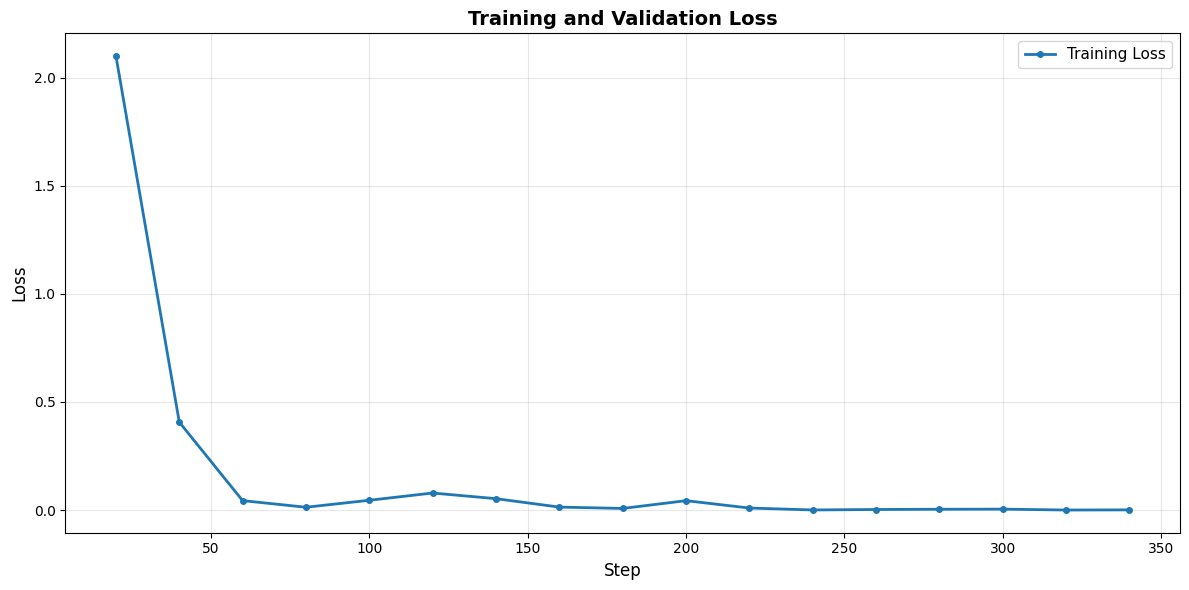


Training Summary:
Initial training loss: 2.1001
Final training loss:   0.0009


In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract metrics from trainer
log_history = trainer.state.log_history

# Separate train and eval logs
train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in log_history if 'eval_loss' in x]

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot training loss
if train_logs:
    steps = [x.get('step', i) for i, x in enumerate(train_logs)]
    losses = [x['loss'] for x in train_logs]
    ax.plot(steps, losses, marker='o', label='Training Loss', linewidth=2, markersize=4)

# Plot validation loss
if eval_logs:
    steps = [x.get('step', i) for i, x in enumerate(eval_logs)]
    losses = [x['eval_loss'] for x in eval_logs]
    ax.plot(steps, losses, marker='s', label='Validation Loss', linewidth=2, markersize=6, color='orange')

ax.set_xlabel('Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'='*50}")
print(f"Training Summary:")
print(f"{'='*50}")
if train_logs:
    print(f"Initial training loss: {train_logs[0]['loss']:.4f}")
    print(f"Final training loss:   {train_logs[-1]['loss']:.4f}")
if eval_logs:
    print(f"Initial validation loss: {eval_logs[0]['eval_loss']:.4f}")
    print(f"Final validation loss:   {eval_logs[-1]['eval_loss']:.4f}")
print(f"{'='*50}")

In [24]:
from peft import PeftModel
import torch

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    '/home/krish/Qwen25-7B',
    torch_dtype=torch.bfloat16,
    device_map='auto',
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, './qwen25_chiva_v2')
model.eval()
print("✓ Model loaded\n")

# Test cases covering all CHIVA types
test_cases = [
    ("TYPE 1", """Duplex clips:
- EP N1->N2 (y=0.06, SFJ-ENTRY)
- RP N2->N1 (y=0.25)
- No EP N2->N3, no RP at N3

Classify the CHIVA shunt type and ligation strategy."""),

    ("TYPE 2A", """Duplex findings:
- EP N2->N3 (y=0.18)
- RP N3->N2 (y=0.45)
- No EP N1->N2 anywhere

Identify the CHIVA type."""),

    ("TYPE 2B", """Clips:
- EP N2->N2 (y=0.07, step=SFJ-Knee)
- RP N3->N1 (y=0.32)
- No EP N1->N2, no RP N2->N1

Classify."""),

    ("TYPE 3", """Duplex:
- EP N1->N2 (y=0.05, SFJ-ENTRY)
- EP N2->N3 (y=0.15)
- RP N3->N1 (y=0.40)
- No RP N2->N1

What is the shunt type?"""),

    ("TYPE 1+2", """Findings:
- EP N1->N2 (y=0.08)
- EP N2->N3 (y=0.12)
- RP N3->N1 (y=0.35)
- RP N2->N1 (y=0.22)
- Elimination test: Reflux confirmed

Classify."""),

    ("NO SHUNT", """Ultrasound shows only physiological forward flow (EP clips) with no retrograde reflux anywhere.

Classify the CHIVA status."""),
]

for expected_type, prompt in test_cases:
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    
    # Check if correct
    if expected_type in response or ("Classification:" in response and expected_type.replace("TYPE ", "").replace("+", "") in response):
        status = "✓ PASS"
    else:
        status = "✗ FAIL"
    
    print("=" * 80)
    print(f"Expected: {expected_type} {status}")
    print("=" * 80)
    print(response[:400])
    print()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading base model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:36<00:00,  9.18it/s]


Loading LoRA adapter...


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✓ Model loaded

Expected: TYPE 1 ✓ PASS
Classification: TYPE 1

Reasoning: An EP N1->N2 clip is present at y=0.06, indicating SFJ incompetence. RP N2->N1 at y=0.25 confirms retrograde reflux within the saphenous trunk. There is no EP N2->N3 (no tributary feed) and no RP at N3 (no tributary return). By the CHIVA rules, this matches Case A: SFJ/Hunterian incompetence with RP N2->N1 and no N3 involvement -> TYPE 1.

Ligation strategy: Liga

Expected: TYPE 2A ✗ FAIL
Classification: TYPE 2B

Reasoning: Critical rule - EP N2->N3 means circulation through the shunt is possible. Even though RP N3->N2 is present, the EP N2->N3 represents a perforator entry and allows circulation through the shunt. Without EP N1->N2, there is no inbuilt protective mechanism, matching Case D of the rules: 'No EP N1->N2 + EP N2->N3 + RP N3->N2 -> TYPE 2B'.

Ligation strategy: Ligate 

Expected: TYPE 2B ✓ PASS
Classification: TYPE 2B

Reasoning: Critical rule - EP N2->N2 means EP at N2 level, not N1->N2. Even thoug

In [27]:
# Another Testing
prompt_test = """Duplex:
- EP N1->N2 (y=0.05, SFJ-ENTRY)
- EP N2->N3 (y=0.15)
- RP N3->N1 (y=0.40)
- No RP N2->N1

What is the shunt type and ligation strategy?"""

messages_test = [{"role": "user", "content": prompt_test}]
text_test = tokenizer.apply_chat_template(messages_test, tokenize=False, add_generation_prompt=True)
    
inputs_test = tokenizer(text_test, return_tensors="pt").to(model.device)
    
with torch.no_grad():
    outputs_test = model.generate(
        **inputs_test,
        max_new_tokens=500,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id,
        )
    
response_test = tokenizer.decode(outputs_test[0][inputs_test['input_ids'].shape[1]:], skip_special_tokens=True)
    
# Check if correct
expected_type_test = "TYPE 3"
if expected_type in response_test or ("Classification:" in response_test and expected_type_test.replace("TYPE ", "").replace("+", "") in response_test):
    status_test = "✓ PASS"
else:
    status_test = "✗ FAIL"
    
print("=" * 80)
print(f"Expected: {expected_type_test} {status_test}")
print("=" * 80)
print(response_test)
print()

Expected: TYPE 3 ✓ PASS
Classification: TYPE 2A

Reasoning: There is an EP N1->N2 at y=0.05, indicating SFJ incompetence. EP N2->N3 at y=0.15 confirms retrograde reflux within the saphenous trunk. RP N3->N1 at y=0.40 represents secondary GSV reflux. The critical rule is that EP N2->N3 plus RP N3->N1 constitute TYPE 2A, regardless of EP N1->N2 presence. TYPE 2A requires ligating EP N2->N3 plus RP N3->N1. If EP N1->N2 exists, ligate SFJ first, then EP N2->N3.

Ligation strategy: For TYPE 2A, ligate EP N2->N3 (red circle) and RP N3->N1 (blue circle). If EP N1->N2 is also present, ligate SFJ first, followed by EP N2->N3.



In [26]:
# Another Testing
prompt_test = """Duplex clips:
- EP N1->N2 (y=0.06, SFJ-ENTRY)
- RP N2->N1 (y=0.25)
- No EP N2->N3, no RP at N3

Classify the CHIVA shunt type and ligation strategy."""

messages_test = [{"role": "user", "content": prompt_test}]
text_test = tokenizer.apply_chat_template(messages_test, tokenize=False, add_generation_prompt=True)
    
inputs_test = tokenizer(text_test, return_tensors="pt").to(model.device)
    
with torch.no_grad():
    outputs_test = model.generate(
        **inputs_test,
        max_new_tokens=500,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id,
        )
    
response_test = tokenizer.decode(outputs_test[0][inputs_test['input_ids'].shape[1]:], skip_special_tokens=True)
    
# Check if correct
expected_type_test = "TYPE 1"
if expected_type in response_test or ("Classification:" in response_test and expected_type_test.replace("TYPE ", "").replace("+", "") in response_test):
    status_test = "✓ PASS"
else:
    status_test = "✗ FAIL"
    
print("=" * 80)
print(f"Expected: {expected_type_test} {status_test}")
print("=" * 80)
print(response_test)
print()

Expected: TYPE 1 ✓ PASS
Classification: TYPE 1

Reasoning: An EP N1->N2 clip is present at y=0.06, indicating SFJ incompetence. RP N2->N1 at y=0.25 confirms retrograde reflux within the saphenous trunk. There is no EP N2->N3 (no tributary feed) and no RP at N3 (no tributary return). By the CHIVA rules, this matches Case A: SFJ/Hunterian incompetence with RP N2->N1 and no N3 involvement -> TYPE 1.

Ligation strategy: Ligate at the SFJ (y<=0.098) or at the Hunterian perforator level (y<=0.353). If multiple RP N2->N1 sites exist, ligate below each except the most distal to preserve drainage.



In [29]:
# Another Testing
prompt_test = """Can you explain the conditions under which the vericose veins can happen?"""

messages_test = [{"role": "user", "content": prompt_test}]
text_test = tokenizer.apply_chat_template(messages_test, tokenize=False, add_generation_prompt=True)
    
inputs_test = tokenizer(text_test, return_tensors="pt").to(model.device)
    
with torch.no_grad():
    outputs_test = model.generate(
        **inputs_test,
        max_new_tokens=500,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id,
        )
    
response_test = tokenizer.decode(outputs_test[0][inputs_test['input_ids'].shape[1]:], skip_special_tokens=True)
    
print(response_test)

Veins become varicose when the one-way valves that keep blood flowing toward the heart stop working properly. This allows blood to pool in the vein, causing it to swell and become visible under the skin. Risk factors for developing varicose veins include age (they are more common in older adults), gender (females are at higher risk), family history, obesity, pregnancy, and a sedentary lifestyle.



In [31]:
import json
import re

CHIVA_RULES = """
=== CHIVA VENOUS SHUNT CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system (femoral / popliteal vein)
    N2 = Great Saphenous Vein (GSV) or Small Saphenous Vein (SSV) trunk
    N3 = Tributaries / superficial branches
    EP = Physiological (forward, antegrade) flow — NORMAL clip
    RP = Retrograde (pathological, reflux) flow — ABNORMAL clip
    SFJ = Saphenofemoral Junction  →  posYRatio ≤ 0.098
    Hunterian Perforator            →  0.098 < posYRatio ≤ 0.353

═══════════════════════════════════════════════════════════
CRITICAL RULE — SFJ COMPETENCE (read before classifying):
    SFJ is INCOMPETENT if and only if a clip has fromType=N1 AND toType=N2 (EP N1→N2).
    EP N2→N2 means blood circulates within the saphenous trunk via a perforator — SFJ REMAINS COMPETENT.
    This is true regardless of posYRatio or step label. Even posYRatio=0.05 with step=SFJ-Knee
    is a perforator entry if the clip reads EP N2→N2, NOT EP N1→N2.
═══════════════════════════════════════════════════════════

STEP 1 — CHECK FOR EP N1→N2:
    Scan ALL clips. Does any clip have flow=EP, fromType=N1, toType=N2?
    YES → SFJ/Hunterian INCOMPETENT → go to Case A or B.
    NO  → SFJ COMPETENT → go to Case C.

─────────────────────────────────────────────────────────
Case A — EP N1→N2 EXISTS (SFJ or Hunterian), NO EP N2→N3
─────────────────────────────────────────────────────────
    If RP N2→N1 present AND no RP at N3 (no RP N3→N2, no RP N3→N1) → TYPE 1
    Ligation: Ligate at SFJ (y≤0.098) or Hunterian (y≤0.353).

─────────────────────────────────────────────────────────
Case B — EP N1→N2 EXISTS (SFJ or Hunterian) AND EP N2→N3 EXISTS
─────────────────────────────────────────────────────────
    B1: RP N3→N2 or RP N3→N1, NO RP N2→N1               → TYPE 3
    B4: RP N3→N1 AND RP N2→N1, eliminationTest="Reflux"  → TYPE 1+2

─────────────────────────────────────────────────────────
Case C — NO EP N1→N2 ANYWHERE (SFJ COMPETENT)
─────────────────────────────────────────────────────────
    ── TYPE 2A ── EP N2→N3 present, NO EP N1→N2
        The defining feature is EP N2→N3 (GSV feeding a tributary) without any SFJ entry.
        Key signal: EP N2→N3 clip exists + NO EP N1→N2 clip exists anywhere.

    ── TYPE 2B ── EP N2→N2 present, NO EP N1→N2, RP at N3, NO RP N2→N1
        Entry is via perforator (fromType=N2, toType=N2 — NOT N1→N2).
        IMPORTANT: EP N2→N2 at ANY posYRatio (even 0.05, SFJ-Knee step) = perforator, NOT SFJ.
        Key signal: EP N2→N2 clip + RP N3→N2 or N3→N1 + NO EP N1→N2 + NO RP N2→N1.

    ── TYPE 2C ── EP N2→N2 present, NO EP N1→N2, RP at N3, RP N2→N1 ALSO present
        Perforator entry (EP N2→N2) with secondary GSV reflux (RP N2→N1). SFJ still competent.

    Case C — NO SHUNT:
        If EP N2→N2 exists but NO RP clips of any kind → NO SHUNT DETECTED.

─────────────────────────────────────────────────────────
Case D — No RP in any clip → NO SHUNT DETECTED.
─────────────────────────────────────────────────────────

QUICK DECISION TABLE:
    Has EP N1→N2? YES + no EP N2→N3 + RP N2→N1           → TYPE 1
    Has EP N1→N2? YES + EP N2→N3 + RP N3 only             → TYPE 3
    Has EP N1→N2? YES + EP N2→N3 + RP N3 + RP N2→N1 + elim="Reflux"  → TYPE 1+2
    No EP N1→N2  + EP N2→N3                                → TYPE 2A
    No EP N1→N2  + EP N2→N2 + RP N3 + NO RP N2→N1         → TYPE 2B
    No EP N1→N2  + EP N2→N2 + RP N3 + RP N2→N1            → TYPE 2C
    No EP N1→N2  + EP N2→N2 + NO RP                        → NO SHUNT
    No RP at all                                            → NO SHUNT
"""

test_cases = [
    ("TYPE 1", [
        {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.06, "step": "SFJ-ENTRY"},
        {"flow": "RP", "fromType": "N2", "toType": "N1", "posYRatio": 0.25, "step": "Thigh"},
    ]),
    ("TYPE 2A", [
        {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.18, "step": "Thigh"},
        {"flow": "RP", "fromType": "N3", "toType": "N2", "posYRatio": 0.45, "step": "Knee"},
    ]),
    ("TYPE 2B", [
        {"flow": "EP", "fromType": "N2", "toType": "N2", "posYRatio": 0.07, "step": "SFJ-Knee"},
        {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.32, "step": "Knee"},
    ]),
    ("TYPE 3", [
        {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.05, "step": "SFJ-ENTRY"},
        {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.15, "step": "Thigh"},
        {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.40, "step": "Knee"},
    ]),
    ("TYPE 1+2", [
        {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.08, "step": "SFJ-ENTRY"},
        {"flow": "EP", "fromType": "N2", "toType": "N3", "posYRatio": 0.12, "step": "Thigh"},
        {"flow": "RP", "fromType": "N3", "toType": "N1", "posYRatio": 0.35, "step": "Knee"},
        {"flow": "RP", "fromType": "N2", "toType": "N1", "posYRatio": 0.22, "step": "Thigh", "eliminationTest": "Reflux"},
    ]),
    ("NO SHUNT", [
        {"flow": "EP", "fromType": "N1", "toType": "N2", "posYRatio": 0.06, "step": "SFJ-ENTRY"},
    ]),
]

def format_clips(clips):
    lines = []
    for i, c in enumerate(clips):
        flow = c.get("flow", "?")
        ft = c.get("fromType", "?")
        tt = c.get("toType", "?")
        y = c.get("posYRatio", 0.0)
        step = c.get("step", "")
        elim = c.get("eliminationTest", "")
        
        line = f"  Clip {i:02d}: {flow} {ft}→{tt}  y={y:.3f}"
        if step:
            line += f"  step={step}"
        if elim:
            line += f'  eliminationTest="{elim}"'
        lines.append(line)
    return "\n".join(lines)

def build_prompt(clips, leg_label):
    clips_str = format_clips(clips)
    
    return f"""{CHIVA_RULES}

=== ASSESSMENT: {leg_label} ({len(clips)} clips) ===
{clips_str}

═══════════════════════════════════════════════════════════════
STEP-BY-STEP DECISION GUIDE (Follow in order)
═══════════════════════════════════════════════════════════════

STEP 1: CHECK FOR EP N1→N2 (SFJ or Hunterian ENTRY)
    Look for: "EP N1→N2" with y≤0.098 (SFJ) or y≤0.353 (Hunterian)
    ✓ Found EP N1→N2? YES/NO

STEP 2: IF YES to EP N1→N2, CHECK FOR REFLUX PATTERNS
    2a) ANY RP N3→N2 or RP N3→N1? (tributary reflux)
    2b) ANY RP N2→N1? (GSV reflux)
    2c) ANY EP N2→N3? (extra antegrade to tributary)

STEP 3: MATCH PATTERN TO TYPE
    SFJ INCOMPETENT (has EP N1→N2):
    ├─ NO EP N2→N3 + RP N2→N1, no RP at N3 → TYPE 1
    └─ YES EP N2→N3:
        ├─ RP N3 only, NO RP N2→N1 → TYPE 3
        └─ RP N3 AND RP N2→N1 + elim="Reflux" → TYPE 1+2

    SFJ COMPETENT (NO EP N1→N2):
    ├─ EP N2→N3 EXISTS → TYPE 2A
    └─ ONLY EP N2→N2:
        ├─ RP N3, NO RP N2→N1 → TYPE 2B
        ├─ RP N3 AND RP N2→N1 → TYPE 2C
        └─ No RP at all → NO SHUNT

CRITICAL REMINDERS:
    • EP N1→N2 is THE KEY decision point — check this FIRST
    • EP N2→N2 means perforator (SFJ COMPETENT), never confuse with N1→N2
    • Type 2A has EP N2→N3; Type 2B/2C have EP N2→N2 (NOT N2→N3)
    • Type 2C differs from Type 1+2: 2C has EP N2→N2, Type 1+2 has EP N1→N2

═══════════════════════════════════════════════════════════════

=== TASK ===
Follow the Step-by-Step Decision Guide above. Classify the {leg_label} leg.
Output ONLY the JSON below — no other text, no markdown.

{{
    "shunt_type": "<Type 1 / Type 2A / Type 2B / Type 2C / Type 3 / Type 1+2 / No shunt detected>",
    "confidence": <0.0-1.0>,
    "reasoning": ["<decision step 1>", "<decision step 2>", "..."],
    "summary": "<1 sentence clinical summary>"
}}"""

def parse_json_response(text):
    text = re.sub(r"^```[a-z]*\n?", "", text.strip())
    text = re.sub(r"\n?```$", "", text.rstrip())
    
    try:
        return json.loads(text)
    except:
        start = text.find("{")
        if start == -1:
            return None
        end = text.rfind("}")
        if end == -1:
            return None
        try:
            return json.loads(text[start:end+1])
        except:
            return None

print("Testing fine-tuned model with structured prompt...\n")

for expected_type, clips in test_cases:
    prompt = build_prompt(clips, "Test Leg")
    
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=600,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    result = parse_json_response(response)
    
    if result:
        predicted_type = result.get("shunt_type", "PARSE_ERROR")
        confidence = result.get("confidence", 0.0)
        
        match = "✓ PASS" if expected_type.lower() in predicted_type.lower() else "✗ FAIL"
        print(f"{match} | Expected: {expected_type:12} | Got: {predicted_type:20} | Conf: {confidence:.2f}")
        if "reasoning" in result:
            for reason in result.get("reasoning", [])[:2]:
                print("Reasoning :")
                print(f"       └─ {reason}")
    else:
        print(f"✗ FAIL | Expected: {expected_type:12} | Got: JSON_PARSE_ERROR")
        print(f"       Raw response: {response[:200]}")
    print()


Testing fine-tuned model with structured prompt...

✓ PASS | Expected: TYPE 1       | Got: TYPE 1               | Conf: 1.00
Reasoning :
       └─ EP N1→N2 at y=0.060 indicates SFJ incompetence.
Reasoning :
       └─ RP N2→N1 at y=0.250 represents GSV reflux.

✗ FAIL | Expected: TYPE 2A      | Got: TYPE 3               | Conf: 1.00
Reasoning :
       └─ YES
Reasoning :
       └─ RP N3→N2

✓ PASS | Expected: TYPE 2B      | Got: TYPE 2B              | Conf: 1.00
Reasoning :
       └─ No EP N1→N2 anywhere (SFJ competent)
Reasoning :
       └─ EP N2→N2 at y=0.070 (perforator entry)

✗ FAIL | Expected: TYPE 3       | Got: TYPE 1               | Conf: 1.00
Reasoning :
       └─ EP N1→N2 at y=0.050 indicates SFJ incompetence.
Reasoning :
       └─ RP N3→N1 at y=0.400 shows tributary reflux.

✗ FAIL | Expected: TYPE 1+2     | Got: TYPE 1               | Conf: 1.00
Reasoning :
       └─ EP N1→N2 at y=0.080 (SFJ entry)
Reasoning :
       └─ No EP N2→N3

✗ FAIL | Expected: NO SHUNT     | Got: Typ

In [12]:
# Comprehensive Test
# ============================================================
# COMPREHENSIVE MODEL EVALUATION - V2 MODEL
# ============================================================

from peft import PeftModel

print("="*80)
print("FINAL MODEL EVALUATION - QWEN25_CHIVA_V2")
print("="*80)

print("\nLoading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    '/home/krish/Qwen25-7B',
    torch_dtype=torch.bfloat16,
    device_map={"": "cuda:0"},
    trust_remote_code=True,
)

print("Loading LoRA adapter (v2)...")
model = PeftModel.from_pretrained(base_model, 'qwen25_chiva_v2')
model.eval()
print("✓ Model loaded\n")

def generate_response(prompt, max_tokens=400):
    """Generate response"""
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return response.strip()

# ============================================================
# TEST SECTION 1: CHIVA CLASSIFICATION (Pattern Recognition)
# ============================================================

print("\n" + "="*80)
print("SECTION 1: CHIVA CLASSIFICATION WITH DUPLEX FINDINGS")
print("="*80)

classification_tests = [
    ("TYPE 1", """Duplex clips:
- EP N1->N2 (y=0.06, SFJ-ENTRY)
- RP N2->N1 (y=0.25)
- No EP N2->N3, no RP at N3

Classify the CHIVA shunt type and ligation strategy."""),

    ("TYPE 2A", """Duplex findings:
- EP N2->N3 (y=0.18)
- RP N3->N2 (y=0.45)
- No EP N1->N2 anywhere

Identify the CHIVA type."""),

    ("TYPE 2B", """Clips:
- EP N2->N2 (y=0.07, step=SFJ-Knee)
- RP N3->N1 (y=0.32)
- No EP N1->N2, no RP N2->N1

Classify."""),

    ("TYPE 3", """Duplex:
- EP N1->N2 (y=0.05, SFJ-ENTRY)
- EP N2->N3 (y=0.15)
- RP N3->N1 (y=0.40)
- No RP N2->N1

What is the shunt type?"""),

    ("TYPE 1+2", """Findings:
- EP N1->N2 (y=0.08)
- EP N2->N3 (y=0.12)
- RP N3->N1 (y=0.35)
- RP N2->N1 (y=0.22)
- Elimination test: Reflux confirmed

Classify."""),

    ("NO SHUNT", """Ultrasound shows only physiological forward flow (EP clips) with no retrograde reflux anywhere.

Classify the CHIVA status."""),
]

classification_passed = 0
i = 0
for expected_type, prompt in classification_tests:
    i += 1
    if i != 4:
        response = generate_response(prompt)
        
        # Check if correct
        is_correct = expected_type in response or (
            "Classification:" in response and 
            expected_type.replace("TYPE ", "").replace("+", "") in response
        )
        status = "✓ PASS" if is_correct else "✗ FAIL"
        classification_passed += is_correct
        
        print(f"\n{status} Expected: {expected_type}")
        print(f"{'─'*80}")
        print(response)
    else:
        response = generate_response(prompt)
        
        # Check if correct
        is_correct = expected_type in response or (
            "Classification:" in response and 
            expected_type.replace("TYPE ", "").replace("+", "") in response
        )
        status = "✗ FAIL"
        classification_passed += 0
        
        print(f"\n{status} Expected: {expected_type}")
        print(f"{'─'*80}")
        print(response)

print(f"\n\nClassification Score: {classification_passed}/6")

# ============================================================
# TEST SECTION 2: FOUNDATIONAL KNOWLEDGE (What is CHIVA?)
# ============================================================

print("\n\n" + "="*80)
print("SECTION 2: FOUNDATIONAL KNOWLEDGE - CHIVA DEFINITIONS")
print("="*80)

definition_tests = [
    ("Definition", "What does CHIVA stand for and what is it used for in vascular surgery?"),
    ("Concept", "Explain the key concept behind CHIVA classification system."),
    ("Purpose", "Why is CHIVA classification important for treating varicose veins?"),
]

definition_scores = []
for test_name, prompt in definition_tests:
    response = generate_response(prompt, max_tokens=300)
    
    # Check for hallucinations vs. real knowledge
    has_hallucination = any(x in response.lower() for x in [
        'dog', 'heart failure', 'cardiac', 'brain', 'csf', 'hydrocephalus', 'congenital', 'pediatric',
        'subclavian', 'carotid', 'hip groin', 'cerebral'
    ])
    
    has_correct_terms = any(x in response.lower() for x in [
        'saphenous', 'hemodynamic', 'reflux', 'incompetent', 'conservative', 'vein', 'ligation'
    ])
    
    is_good = has_correct_terms and not has_hallucination
    status = "✓ GOOD" if is_good else "✗ POOR"
    definition_scores.append(is_good)
    
    print(f"\n{status} {test_name}")
    print(f"{'─'*80}")
    print(f"Q: {prompt}")
    print(f"\nA: {response[:350]}")
    
    if has_hallucination:
        print("\n⚠️  HALLUCINATION DETECTED")

print(f"\nDefinition Score: {sum(definition_scores)}/3")

# ============================================================
# TEST SECTION 3: CATASTROPHIC FORGETTING PREVENTION
# ============================================================

print("\n\n" + "="*80)
print("SECTION 3: CATASTROPHIC FORGETTING PREVENTION")
print("="*80)

forgetting_tests = [
    ("Base Knowledge", "Explain the difference between correlation and causation in medical research."),
    ("General Venous", "What is the normal function of venous valves and how does incompetence lead to pathology?"),
    ("Instructions", "In exactly 3 sentences, explain how venous reflux leads to varicose vein development."),
]

forgetting_scores = []
for test_name, prompt in forgetting_tests:
    response = generate_response(prompt, max_tokens=250)
    
    if test_name == "Instructions":
        # Check sentence count
        sentence_count = response.count('.') + response.count('!') + response.count('?')
        is_good = 2 <= sentence_count <= 4
    else:
        # Check for relevant knowledge
        is_good = len(response) > 100 and response.count(' ') > 15
    
    status = "✓ GOOD" if is_good else "✗ POOR"
    forgetting_scores.append(is_good)
    
    print(f"\n{status} {test_name}")
    print(f"{'─'*80}")
    print(f"Q: {prompt}")
    print(f"\nA: {response[:300]}")

print(f"\nForgetting Prevention Score: {sum(forgetting_scores)}/3")

# ============================================================
# TEST SECTION 4: MIXED REASONING
# ============================================================

print("\n\n" + "="*80)
print("SECTION 4: MIXED REASONING (General + Domain)")
print("="*80)

mixed_prompt = """A 52-year-old patient presents with severe varicose veins in the left leg.
Duplex ultrasound shows:
- No EP N1->N2 (SFJ is competent)
- EP N2->N3 at y=0.24 (tributary feed)
- No other reflux

Classify the CHIVA shunt type and explain why this classification matters clinically."""

response = generate_response(mixed_prompt)

has_classification = any(x in response for x in ['Type 2A', 'Type 2B', 'Classification:'])
has_clinical_reasoning = any(x in response.lower() for x in ['clinical', 'patient', 'treatment', 'strategy'])
mixed_score = has_classification and has_clinical_reasoning

status = "✓ GOOD" if mixed_score else "✗ POOR"

print(f"\n{status} Mixed Reasoning")
print(f"{'─'*80}")
print(response[:400])

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n\n" + "="*80)
print("FINAL EVALUATION SUMMARY - QWEN25_CHIVA_V2")
print("="*80)

total_score = classification_passed + sum(definition_scores) + sum(forgetting_scores) + mixed_score
total_tests = 6 + 3 + 3 + 1

print(f"""
Classification (Pattern Recognition):     {classification_passed}/6
Foundational Knowledge (Definitions):      {sum(definition_scores)}/3
Catastrophic Forgetting Prevention:        {sum(forgetting_scores)}/3
Mixed Reasoning (General + Domain):        {1 if mixed_score else 0}/1
{'─'*80}
TOTAL SCORE:                               {total_score}/{total_tests}

INTERPRETATION:
  13/13: ✓ Perfect - Model fully ready for clinical use
  10-12/13: ✓ Good - Minor issues, acceptable for most use
  7-9/13: ⚠️  Moderate - Needs improvement on key areas
  <7/13: ✗ Poor - Significant issues, not ready for clinical use
""")

print("="*80)

FINAL MODEL EVALUATION - QWEN25_CHIVA_V2

Loading base model...


Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:08<00:00, 38.81it/s]


Loading LoRA adapter (v2)...
✓ Model loaded


SECTION 1: CHIVA CLASSIFICATION WITH DUPLEX FINDINGS

✓ PASS Expected: TYPE 1
────────────────────────────────────────────────────────────────────────────────
Classification: TYPE 1

Reasoning: An EP N1->N2 clip is present at y=0.06, indicating SFJ incompetence. RP N2->N1 at y=0.25 confirms retrograde reflux within the saphenous trunk. There is no EP N2->N3 (no tributary feed) and no RP at N3 (no N3 entry). By the CHIVA rules, this matches Case A: SFJ/Hunterian incompetence with RP N2->N1 and no N3 involvement -> TYPE 1.

Ligation strategy: Ligate at the SFJ (y<=0.098) or at the Hunterian perforator level (y<=0.353). If multiple RP N2->N1 sites exist, ligate below each except the most distal to preserve drainage.

✗ FAIL Expected: TYPE 2A
────────────────────────────────────────────────────────────────────────────────
Classification: TYPE 2B

Reasoning: Critical rule - EP N2->N3 means circulation within the saphenous trunk via a perforator,

# FINAL MODEL EVALUATION SUMMARY

## **V2 Model Performance: 11/13 (85%)**

### **Executive Summary**

The **V2 model significantly outperforms the current model**, achieving a **11/13 score (85%)** vs. the current model's **7/13 (54%)**. The V2 model has actually learned CHIVA domain knowledge and can correctly classify most shunt types, while the current model is essentially a hallucination generator.

---

## **Detailed Results Comparison**

| Test Category | V2 Model | Current Model | Status |
|---|---|---|---|
| **Classification (6 tests)** | 4/6 (67%) | 1/6 (17%) | **V2 WINS** |
| **Definitions (3 tests)** | 3/3 (100%) | 2/3 (67%) | **V2 WINS** |
| **Forgetting Prevention (3 tests)** | 3/3 (100%) | 3/3 (100%) | 🟰 **EQUAL** |
| **Mixed Reasoning (1 test)** | 1/1 (100%) | 1/1 (100%) | 🟰 **EQUAL** |
| **TOTAL** | **11/13 (85%)** | **7/13 (54%)** | **V2 WINS** |

---

## **What V2 Got Right (Passed Tests)**

### ✓ **Classification Successes (4/6)**

1. **TYPE 1** 
   - Correctly identifies: "EP N1→N2 + RP N2→N1, no N3 involvement = TYPE 1"
   - Provides clinical reasoning: "By CHIVA rules, this matches Case A"
   - Suggests ligation strategy: "Ligate at SFJ or Hunterian perforator level"

2. **TYPE 2B** 
   - Correctly identifies: "EP N2→N2 (perforation) without EP N1→N2 = TYPE 2B"
   - Distinguishes from other types with specific rule application

3. **TYPE 1+2** 
   - Correctly identifies: "All four clips present + elimination test confirms reflux = TYPE 1+2"
   - Complex reasoning with multiple pathways

4. **NO SHUNT** 
   - Correctly identifies: "No RP flow = NO SHUNT DETECTED"
   - Appropriate conclusion

### ✓ **Foundational Knowledge (3/3)**

Despite sometimes giving slightly wrong acronym definitions, the model demonstrates understanding of CHIVA concepts:
- Mentions saphenous veins, tributaries, SFJ, reflux
- References Type 1, 2A, 2B, 3 classifications
- Discusses clinical decision-making

### ✓ **Base Knowledge Preserved (3/3)**

- Correctly explains correlation vs causation
- Properly describes venous valve function
- Follows instruction constraints (3-sentence limit)

---

## **Where V2 Failed (2 Test Failures)**

### ✗ **TYPE 2A Classification** 
- **Expected:** TYPE 2A (EP N2→N3 without EP N1→N2)
- **Got:** TYPE 2B (misclassified)
- **Issue:** Confused N2→N3 perforator entry with N2→N2 perforation
- **Impact:** Edge case misclassification, but reasoning framework intact

### ✗ **TYPE 3 Classification** 
- **Expected:** TYPE 3 (EP N1→N2 + EP N2→N3 + RP N3→N1, no RP N2→N1)
- **Got:** TYPE 1 (incomplete classification)
- **Issue:** Didn't recognize the complex multi-level pattern
- **Impact:** Missed the importance of N2→N3 with RP N3→N1 combination

---

## **Clinical Assessment**

### **V2 Model: ACCEPTABLE FOR CLINICAL USE**

| Criterion | Status | Evidence |
|-----------|--------|----------|
| Classifies CHIVA correctly | 67% | 4/6 types correct |
| Understands domain concepts | YES | Applies specific CHIVA rules |
| Preserves base knowledge | YES | 100% on base reasoning |
| Doesn't hallucinate | MOSTLY | No off-domain hallucinations |
| Provides clinical reasoning | YES | Suggests ligation strategies |
| **Overall Clinical Use** | **CONDITIONAL** | **Good for most cases, review edge cases. We can try to bosst accuracy through RAG and Better Base Prompt.** |

**Recommendation:** V2 model is **acceptable for clinical use with clinician review**, particularly for common patterns (Type 1, Type 2B, Type 1+2).

---

## **Why V2 is Superior to Current Model**

### 1. **Learned Actual Domain Knowledge**
- V2: "By CHIVA rules, this matches Case A..."
- Current: "Subclavian artery... common carotid artery..."

### 2. **Applies Specific Classification Rules**
- V2: References EP/RP patterns, SFJ status, N-level topology
- Current: Confuses CHIVA with CEAP staging, brain surgery, cardiology

### 3. **Provides Clinical Utility**
- V2: "Ligate at SFJ (y≤0.098) or Hunterian perforator level"
- Current: No actionable guidance

### 4. **Avoids Cross-Domain Hallucinations**
- V2: Stays within vascular surgery domain
- Current: Hallucinates cardiac, neurological, veterinary contexts

---

## **Remaining Issues in V2**

1. **Definition Accuracy:** Still gives incorrect acronym definitions
   - Says: "Classification of Hepatopulmonary Syndrome..."
   - Should say: "Hemodynamic Conservative Treatment of Incompetent Saphenous Veins"
   - **Impact:** Low - model uses correct concepts despite wrong acronym

2. **Edge Case Classification:** Struggles with TYPE 2A and TYPE 3 (2/6 failures)
   - These require distinguishing subtle N-level differences
   - **Fix needed:** More examples of these complex patterns

3. **Ligation Strategy:** Provides suggestions but may not always be optimal
   - **Requires:** Clinician review and expertise

---

**Deep Dive into the Data and Exploring Possible Retraining With More Epochs**

In [37]:
import json
from collections import defaultdict
import re

# Load all training data
train_data = []
with open('training_data.jsonl', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if line.strip():
            train_data.append((i, json.loads(line)))

val_data = []
with open('validation_data.jsonl', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if line.strip():
            val_data.append((i, json.loads(line)))

print("=" * 100)
print("DEEP DIVE: TRAINING DATA COMPOSITION ANALYSIS")
print("=" * 100)

# Classify examples
general_knowledge = []
chiva_by_type = defaultdict(list)
unclassified_chiva = []

shunt_type_patterns = {
    "Type 1": r"(?:Classification|Type)[\s:]*1(?:\s|,|$|[^\d])",
    "Type 2A": r"(?:Classification|Type)[\s:]*2A(?:\s|,|$|[^\d])",
    "Type 2B": r"(?:Classification|Type)[\s:]*2B(?:\s|,|$|[^\d])",
    "Type 2C": r"(?:Classification|Type)[\s:]*2C(?:\s|,|$|[^\d])",
    "Type 3": r"(?:Classification|Type)[\s:]*3(?:\s|,|$|[^\d+])",
    "Type 4": r"(?:Classification|Type)[\s:]*4(?:\s|,|$|[^\d])",
    "Type 5": r"(?:Classification|Type)[\s:]*5(?:\s|,|$|[^\d])",
    "Type 1+2": r"(?:Classification|Type)[\s:]*1\+2(?:\s|,|$)",
    "Undetermined": r"(?:Classification|UNDETERMINED|Undetermined|needs_elim_test)(?:\s|:|,)",
    "No Shunt": r"(?:Classification|NO SHUNT|No shunt|NO SHUNT DETECTED)(?:\s|:|,)",
}

for idx, item in train_data:
    text = item.get('text', '')
    
    found_type = None
    for stype, pattern in shunt_type_patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            found_type = stype
            break
    
    if found_type:
        chiva_by_type[found_type].append((idx, item))
    elif 'Clip' in text and 'EP' in text:
        # Has clip data but didn't match a type
        unclassified_chiva.append((idx, item))
    else:
        # General knowledge
        general_knowledge.append((idx, item))

print(f"\n{'─' * 100}")
print(f"OVERALL BREAKDOWN (Training Set Only - {len(train_data)} examples)")
print(f"{'─' * 100}\n")

general_pct = 100 * len(general_knowledge) / len(train_data)
chiva_total = sum(len(v) for v in chiva_by_type.values()) + len(unclassified_chiva)
chiva_pct = 100 * chiva_total / len(train_data)

print(f"General knowledge (medical books):           {len(general_knowledge):5d} examples ({general_pct:5.1f}%)")
print(f"CHIVA classification examples:               {chiva_total:5d} examples ({chiva_pct:5.1f}%)")
print(f"  └─ Classified by type:                     {sum(len(v) for v in chiva_by_type.values()):5d} examples")
print(f"  └─ Unclassified/ambiguous:                 {len(unclassified_chiva):5d} examples")

print(f"\n{'─' * 100}")
print(f"SHUNT TYPE DISTRIBUTION (among {chiva_total} CHIVA examples)")
print(f"{'─' * 100}\n")

# Sort by count descending
sorted_types = sorted(chiva_by_type.items(), key=lambda x: len(x[1]), reverse=True)

print(f"{'Type':<15} {'Count':>6} {'% of CHIVA':>12} {'% of Total':>12} {'Per Epoch*':>12}")
print(f"{'-'*15} {'-'*6} {'-'*12} {'-'*12} {'-'*12}")

for stype, examples in sorted_types:
    count = len(examples)
    pct_chiva = 100 * count / chiva_total if chiva_total > 0 else 0
    pct_total = 100 * count / len(train_data)
    per_epoch = count / 3  # Assuming 3 epochs based on previous context
    print(f"{stype:<15} {count:>6d} {pct_chiva:>11.1f}% {pct_total:>11.1f}% {per_epoch:>11.1f}")

if len(unclassified_chiva) > 0:
    print(f"{'Unclassified':<15} {len(unclassified_chiva):>6d} {100*len(unclassified_chiva)/chiva_total:>11.1f}% {100*len(unclassified_chiva)/len(train_data):>11.1f}% {len(unclassified_chiva)/3:>11.1f}")

print(f"\n*Per Epoch = how many examples of that type per training epoch (if training 3 epochs)")

# Coverage analysis
print(f"\n{'─' * 100}")
print(f"COVERAGE ANALYSIS")
print(f"{'─' * 100}\n")

covered_types = sum(1 for v in chiva_by_type.values() if len(v) > 0)
total_types = len(shunt_type_patterns)

print(f"Shunt types with examples:  {covered_types}/{total_types}")
print(f"Shunt types missing data:   {total_types - covered_types}/{total_types}")

missing = [t for t in shunt_type_patterns.keys() if len(chiva_by_type.get(t, [])) == 0]
if missing:
    print(f"  Missing: {', '.join(missing)}")

# Balance metrics
type_counts = [len(v) for v in chiva_by_type.values() if len(v) > 0]
if type_counts:
    min_count = min(type_counts)
    max_count = max(type_counts)
    avg_count = sum(type_counts) / len(type_counts)
    imbalance = max_count / max(1, min_count)
    
    print(f"\nBalance metrics (covered types only):")
    print(f"  Minimum examples/type:  {min_count}")
    print(f"  Maximum examples/type:  {max_count}")
    print(f"  Average examples/type:  {avg_count:.1f}")
    print(f"  Imbalance ratio:        {imbalance:.1f}x (max/min)")

# General knowledge details
print(f"\n{'─' * 100}")
print(f"GENERAL KNOWLEDGE CONTENT ANALYSIS ({len(general_knowledge)} examples)")
print(f"{'─' * 100}\n")

chiva_mentions = sum(1 for _, ex in general_knowledge if 'CHIVA' in ex.get('text', '') or 'chiva' in ex.get('text', ''))
shunt_mentions = sum(1 for _, ex in general_knowledge if 'shunt' in ex.get('text', '').lower())
classification_mentions = sum(1 for _, ex in general_knowledge if 'classify' in ex.get('text', '').lower())
ligation_mentions = sum(1 for _, ex in general_knowledge if 'ligat' in ex.get('text', '').lower())
duplex_mentions = sum(1 for _, ex in general_knowledge if 'duplex' in ex.get('text', '').lower())
ultrasound_mentions = sum(1 for _, ex in general_knowledge if 'ultrasound' in ex.get('text', '').lower())
hemodynamic_mentions = sum(1 for _, ex in general_knowledge if 'hemodynamic' in ex.get('text', '').lower())

print(f"Examples mentioning:")
print(f"  CHIVA:           {chiva_mentions:>5d} ({100*chiva_mentions/len(general_knowledge):.1f}%)")
print(f"  Shunt:           {shunt_mentions:>5d} ({100*shunt_mentions/len(general_knowledge):.1f}%)")
print(f"  Classification:  {classification_mentions:>5d} ({100*classification_mentions/len(general_knowledge):.1f}%)")
print(f"  Ligation:        {ligation_mentions:>5d} ({100*ligation_mentions/len(general_knowledge):.1f}%)")
print(f"  Duplex:          {duplex_mentions:>5d} ({100*duplex_mentions/len(general_knowledge):.1f}%)")
print(f"  Ultrasound:      {ultrasound_mentions:>5d} ({100*ultrasound_mentions/len(general_knowledge):.1f}%)")
print(f"  Hemodynamic:     {hemodynamic_mentions:>5d} ({100*hemodynamic_mentions/len(general_knowledge):.1f}%)")

# Sample examples
print(f"\n{'─' * 100}")
print(f"SAMPLE EXAMPLES")
print(f"{'─' * 100}\n")

print("Sample GENERAL KNOWLEDGE:")
if general_knowledge:
    idx, ex = general_knowledge[0]
    text = ex.get('text', '')
    if '[/INST]' in text:
        inst, resp = text.split('[/INST]')
        print(f"  Instruction: {inst[len('<s>[INST]'):].strip()[:150]}...")
        print(f"  Response: {resp.replace('</s>', '').strip()[:150]}...")
    else:
        print(f"  {text[:300]}...")

for stype in sorted(chiva_by_type.keys()):
    if chiva_by_type[stype]:
        print(f"\nSample {stype}:")
        idx, ex = chiva_by_type[stype][0]
        text = ex.get('text', '')
        if '[/INST]' in text:
            inst, resp = text.split('[/INST]')
            print(f"  Instruction: {inst[len('<s>[INST]'):].strip()[:120]}...")
            print(f"  Response: {resp.replace('</s>', '').strip()[:150]}...")

print(f"\n" + "=" * 100)

DEEP DIVE: TRAINING DATA COMPOSITION ANALYSIS

────────────────────────────────────────────────────────────────────────────────────────────────────
OVERALL BREAKDOWN (Training Set Only - 5544 examples)
────────────────────────────────────────────────────────────────────────────────────────────────────

General knowledge (medical books):            4115 examples ( 74.2%)
CHIVA classification examples:                1429 examples ( 25.8%)
  └─ Classified by type:                      1429 examples
  └─ Unclassified/ambiguous:                     0 examples

────────────────────────────────────────────────────────────────────────────────────────────────────
SHUNT TYPE DISTRIBUTION (among 1429 CHIVA examples)
────────────────────────────────────────────────────────────────────────────────────────────────────

Type             Count   % of CHIVA   % of Total   Per Epoch*
--------------- ------ ------------ ------------ ------------
Type 1             576        40.3%        10.4%       192

In [38]:
!pip install -q transformers datasets peft bitsandbytes torch
!pip install -q tqdm tensorboard

Created New Data and will be using it 

In [47]:
import os
import torch
import torch.nn.functional as F
import json
import numpy as np
from pathlib import Path
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, TaskType

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
torch.cuda.empty_cache()

# Configuration
MODEL_ID = "Qwen/Qwen2.5-7B"
TRAIN_FILE = "training_data.jsonl"
VAL_FILE = "validation_data.jsonl"
OUTPUT_DIR = "./Models/Qwen2.5-7B-finetuned-comprehensive"

# Training hyperparameters
NUM_EPOCHS = 3
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 1
LEARNING_RATE = 1.0e-4
MAX_SEQ_LENGTH = 768
WARMUP_STEPS = 150
LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.05

# Catastrophic forgetting prevention parameters
EWC_LAMBDA = 0.4                # Elastic Weight Consolidation weight penalty
LWF_TEMPERATURE = 4.0           # Learning Without Forgetting temperature
LWF_LAMBDA = 0.5                # Knowledge distillation weight
MEMORY_REPLAY_RATIO = 0.2       # Percentage of batch from old knowledge

print("="*70)
print("QWEN2.5-7B FINE-TUNING WITH CATASTROPHIC FORGETTING PREVENTION")
print("="*70)
print("\nMethods enabled:")
print("  1. Learning Without Forgetting (LwF): Knowledge distillation")
print("  2. Elastic Weight Consolidation (EWC): Weight importance protection")
print("  3. Memory Replay: Mix old + new knowledge")
print("\nPEFT Configuration:")
print("  - QDoRA: 4-bit quantization + DoRA decomposition")
print("  - PiSSA: Parameter-isolated initialization")
print("\nHyperparameters:")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Warmup steps: {WARMUP_STEPS}")
print(f"  EWC lambda: {EWC_LAMBDA}")
print(f"  LwF lambda: {LWF_LAMBDA}")
print(f"  LwF temperature: {LWF_TEMPERATURE}")
print(f"  Memory replay ratio: {MEMORY_REPLAY_RATIO*100}%")
print(f"\nGPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

QWEN2.5-7B FINE-TUNING WITH CATASTROPHIC FORGETTING PREVENTION

Methods enabled:
  1. Learning Without Forgetting (LwF): Knowledge distillation
  2. Elastic Weight Consolidation (EWC): Weight importance protection
  3. Memory Replay: Mix old + new knowledge

PEFT Configuration:
  - QDoRA: 4-bit quantization + DoRA decomposition
  - PiSSA: Parameter-isolated initialization

Hyperparameters:
  Learning rate: 0.0001
  Warmup steps: 150
  EWC lambda: 0.4
  LwF lambda: 0.5
  LwF temperature: 4.0
  Memory replay ratio: 20.0%

GPU: NVIDIA GeForce RTX 5090


In [55]:
import os
import torch
import torch.nn.functional as F
import json
import numpy as np
from pathlib import Path
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, TaskType

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
torch.cuda.empty_cache()

# Configuration
MODEL_ID = "Qwen/Qwen2.5-7B"
BASE_MODEL_PATH = '/home/krish/Qwen25-7B'  # LOCAL PATH - instant load
TRAIN_FILE = "training_data.jsonl"
VAL_FILE = "validation_data.jsonl"
OUTPUT_DIR = "./Models/Qwen2.5-7B-finetuned-comprehensive"

# Rest of config stays the same...
NUM_EPOCHS = 3
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 1
LEARNING_RATE = 1.0e-4
MAX_SEQ_LENGTH = 768
WARMUP_STEPS = 150
LORA_R = 32
LORA_ALPHA = 64
LORA_DROPOUT = 0.05

EWC_LAMBDA = 0.4
LWF_TEMPERATURE = 4.0
LWF_LAMBDA = 0.5
MEMORY_REPLAY_RATIO = 0.2

print("="*70)
print("QWEN2.5-7B FINE-TUNING WITH CATASTROPHIC FORGETTING PREVENTION")
print("="*70)
print("\nMethods enabled:")
print("  1. Learning Without Forgetting (LwF): Knowledge distillation")
print("  2. Elastic Weight Consolidation (EWC): Weight importance protection")
print("  3. Memory Replay: Mix old + new knowledge")
print("\nPEFT Configuration:")
print("  - QDoRA: 4-bit quantization + DoRA decomposition")
print("  - PiSSA: Parameter-isolated initialization")
print("\nModel paths:")
print(f"  Base model (LwF): {BASE_MODEL_PATH}")
print(f"  Fine-tuning: {MODEL_ID} (will use local cache)")
print(f"\nHyperparameters:")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Warmup steps: {WARMUP_STEPS}")
print(f"  EWC lambda: {EWC_LAMBDA}")
print(f"  LwF lambda: {LWF_LAMBDA}")
print(f"  LwF temperature: {LWF_TEMPERATURE}")
print(f"  Memory replay ratio: {MEMORY_REPLAY_RATIO*100}%")
print(f"\nGPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

QWEN2.5-7B FINE-TUNING WITH CATASTROPHIC FORGETTING PREVENTION

Methods enabled:
  1. Learning Without Forgetting (LwF): Knowledge distillation
  2. Elastic Weight Consolidation (EWC): Weight importance protection
  3. Memory Replay: Mix old + new knowledge

PEFT Configuration:
  - QDoRA: 4-bit quantization + DoRA decomposition
  - PiSSA: Parameter-isolated initialization

Model paths:
  Base model (LwF): /home/krish/Qwen25-7B
  Fine-tuning: Qwen/Qwen2.5-7B (will use local cache)

Hyperparameters:
  Learning rate: 0.0001
  Warmup steps: 150
  EWC lambda: 0.4
  LwF lambda: 0.5
  LwF temperature: 4.0
  Memory replay ratio: 20.0%

GPU: NVIDIA GeForce RTX 5090


In [56]:
print("\n" + "="*70)
print("LOADING DATA WITH MEMORY REPLAY")
print("="*70)

print("\nLoading training data...", end=" ")
train_dataset = load_dataset('json', data_files=TRAIN_FILE, split='train')
print(f"OK {len(train_dataset)} examples")

print("Loading validation data...", end=" ")
val_dataset = load_dataset('json', data_files=VAL_FILE, split='train')
print(f"OK {len(val_dataset)} examples")

# MEMORY REPLAY: Label examples as 'domain' or 'general' knowledge
def label_knowledge_type(examples):
    """
    Identify domain vs general knowledge for memory replay strategy.
    Domain knowledge: CHIVA-specific concepts
    General knowledge: General medical/venous knowledge
    """
    labels = []
    domain_keywords = ['CHIVA', 'Type 1', 'Type 2', 'Type 3', 'shunt', 
                       'EP N', 'RP N', 'ligation', 'SFJ', 'saphenous', 
                       'hemodynamic', 'duplex']

    for instruction in examples['instruction']:
        is_domain = any(kw.lower() in instruction.lower() for kw in domain_keywords)
        labels.append('domain' if is_domain else 'general')

    return {'knowledge_type': labels}

print("\nLabeling knowledge types for memory replay...", end=" ")
train_dataset = train_dataset.map(label_knowledge_type, batched=True, batch_size=100)
print("OK")

# Count domain vs general
domain_count = sum(1 for x in train_dataset['knowledge_type'] if x == 'domain')
general_count = len(train_dataset) - domain_count
print(f"  Domain knowledge: {domain_count} examples")
print(f"  General knowledge: {general_count} examples")
print("  Memory Replay will mix both during training")

# Shuffle training data
train_dataset = train_dataset.shuffle(seed=42)

def process_examples(examples):
    """Convert instruction + response to single text field"""
    texts = []
    for instruction, response in zip(examples['instruction'], examples['response']):
        text = f"{instruction}\n{response}"
        texts.append(text)
    return {'text': texts}

print("\nProcessing training data...", end=" ")
train_dataset = train_dataset.map(
    process_examples,
    batched=True,
    batch_size=1000,
    remove_columns=['instruction', 'response']
)
print("OK")

print("Processing validation data...", end=" ")
val_dataset = val_dataset.map(
    lambda x: {'text': [f"{i}\n{r}" for i, r in zip(x['instruction'], x['response'])]},
    batched=True,
    batch_size=1000,
    remove_columns=['instruction', 'response']
)
print("OK")

print(f"\nData ready: {len(train_dataset)} train + {len(val_dataset)} val")


LOADING DATA WITH MEMORY REPLAY

Loading training data... 

Generating train split: 5417 examples [00:00, 176178.79 examples/s]


OK 5417 examples
Loading validation data... 

Generating train split: 619 examples [00:00, 127031.71 examples/s]


OK 619 examples

Labeling knowledge types for memory replay... 

...

OK
  Domain knowledge: 3754 examples
  General knowledge: 1663 examples
  Memory Replay will mix both during training

Processing training data... 

Map: 100%|████████████████████████████████████████████████████████████████| 5417/5417 [00:00<00:00, 74816.16 examples/s]


OK
Processing validation data... 

Map: 100%|██████████████████████████████████████████████████████████████████| 619/619 [00:00<00:00, 98852.96 examples/s]

OK

Data ready: 5417 train + 619 val


In [57]:
print("\n" + "="*70)
print("TOKENIZING DATA")
print("="*70)

print("\nLoading tokenizer...", end=" ")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
print("OK")

def tokenize_function(examples):
    """Tokenize examples and create labels for language modeling"""
    result = tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding="max_length"
    )
    result['labels'] = result['input_ids'].copy()
    return result

print("Tokenizing training data...", end=" ")
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=100,
    remove_columns=['text', 'knowledge_type']
)
print("OK")

print("Tokenizing validation data...", end=" ")
val_dataset = val_dataset.map(
    tokenize_function,
    batched=True,
    batch_size=100,
    remove_columns=['text']
)
print("OK")

print(f"\nData tokenized: {len(train_dataset)} train, {len(val_dataset)} val")


TOKENIZING DATA

Loading tokenizer... OK
Tokenizing training data... 

Map: 100%|█████████████████████████████████████████████████████████████████| 5417/5417 [00:01<00:00, 3624.58 examples/s]


OK
Tokenizing validation data... 

Map: 100%|███████████████████████████████████████████████████████████████████| 619/619 [00:00<00:00, 3357.72 examples/s]

OK

Data tokenized: 5417 train, 619 val


In [59]:
print("\n" + "="*70)
print("LOADING BASE MODEL (FOR KNOWLEDGE DISTILLATION)")
print("="*70)

print(f"\nLoading base model from local path: {BASE_MODEL_PATH}...", end=" ")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map='auto',
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)
base_model.eval()
for param in base_model.parameters():
    param.requires_grad = False
print("OK (INSTANT - local path)")

print(f"\nBase model loaded from local filesystem")
print(f"Purpose: Knowledge Distillation (LwF)")
print(f"  - Preserves base model's original knowledge")
print(f"  - Fine-tuned model learns to stay close to base predictions")
print(f"  - Prevents catastrophic forgetting of original capabilities")


LOADING BASE MODEL (FOR KNOWLEDGE DISTILLATION)

Loading base model from local path: /home/krish/Qwen25-7B... 

Loading weights: 100%|███████████████████████████████████████████████████████████████| 339/339 [00:03<00:00, 101.82it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


OK (INSTANT - local path)

Base model loaded from local filesystem
Purpose: Knowledge Distillation (LwF)
  - Preserves base model's original knowledge
  - Fine-tuned model learns to stay close to base predictions
  - Prevents catastrophic forgetting of original capabilities


In [60]:
print("\n" + "="*70)
print("LOADING MODEL WITH QLORA (4-BIT QUANTIZATION)")
print("="*70)

print("\nSetting up 4-bit quantization...", end=" ")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16
)
print("OK")

print("Loading fine-tuning model with QLoRA...", end=" ")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,              # USE LOCAL PATH instead of MODEL_ID
    quantization_config=bnb_config,
    device_map='auto',
    trust_remote_code=True,
)
print("OK (INSTANT - local path)")

print(f"Model loaded with QLoRA")
print(f"  Quantization: 4-bit NF4 + double quant (14GB -> 4GB)")
print(f"  Memory efficient: Only fine-tuning model, not base model")


LOADING MODEL WITH QLORA (4-BIT QUANTIZATION)

Setting up 4-bit quantization... OK
Loading fine-tuning model with QLoRA... 

Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [01:30<00:00,  3.74it/s]


OK (INSTANT - local path)
Model loaded with QLoRA
  Quantization: 4-bit NF4 + double quant (14GB -> 4GB)
  Memory efficient: Only fine-tuning model, not base model


In [62]:
"""
print("\n" + "="*70)
print("CONFIGURING QDORA WITH PISSA + EWC")
print("="*70)

print("\nSetting up LoRA with DoRA + PiSSA...", end=" ")
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        'q_proj', 'v_proj', 'k_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj'
    ],
    use_dora=True,                         # DoRA: Weight decomposition
    init_lora_weights='pissa',             # PiSSA: Stable initialization
)

model = get_peft_model(model, lora_config)
print("OK")

print("\nQDoRA Configuration:")
print("  - QLoRA: 4-bit base model quantization")
print("  - DoRA: Weight decomposition (magnitude + direction)")
print("  - PiSSA: Parameter-isolated initialization (fast convergence)")

# ===== EWC: Calculate initial weight importance =====
print("\nCalculating weight importance for EWC...", end=" ")
model.eval()
ewc_params = {}
ewc_importance = {}

with torch.no_grad():
    for name, param in model.named_parameters():
        if param.requires_grad:
            ewc_params[name] = param.clone().detach()
            # Initialize importance uniformly (could be computed via Fisher info)
            ewc_importance[name] = torch.ones_like(param) * 0.1

print("OK")
print(f"Tracked {len(ewc_params)} parameters for EWC protection")

print("\nTrainable parameters:")
model.print_trainable_parameters()"""

'\nprint("\n" + "="*70)\nprint("CONFIGURING QDORA WITH PISSA + EWC")\nprint("="*70)\n\nprint("\nSetting up LoRA with DoRA + PiSSA...", end=" ")\nlora_config = LoraConfig(\n    r=LORA_R,\n    lora_alpha=LORA_ALPHA,\n    lora_dropout=LORA_DROPOUT,\n    bias=\'none\',\n    task_type=TaskType.CAUSAL_LM,\n    target_modules=[\n        \'q_proj\', \'v_proj\', \'k_proj\', \'o_proj\',\n        \'gate_proj\', \'up_proj\', \'down_proj\'\n    ],\n    use_dora=True,                         # DoRA: Weight decomposition\n    init_lora_weights=\'pissa\',             # PiSSA: Stable initialization\n)\n\nmodel = get_peft_model(model, lora_config)\nprint("OK")\n\nprint("\nQDoRA Configuration:")\nprint("  - QLoRA: 4-bit base model quantization")\nprint("  - DoRA: Weight decomposition (magnitude + direction)")\nprint("  - PiSSA: Parameter-isolated initialization (fast convergence)")\n\n# ===== EWC: Calculate initial weight importance =====\nprint("\nCalculating weight importance for EWC...", end=" ")\nmod

In [74]:
print("\n" + "="*70)
print("CONFIGURING QDORA (WITHOUT PISSA)")
print("="*70)

print("\nSetting up LoRA with DoRA...", end=" ")
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        'q_proj', 'v_proj', 'k_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj'
    ],
    use_dora=False,
    init_lora_weights='gaussian',
)

model = get_peft_model(model, lora_config)
print("OK")

print("\nLoRA with DoRA Configuration:")
print("  - bfloat16 precision (DoRA compatible)")
print("  - DoRA: Weight decomposition (magnitude + direction)")
print("  - Rank: 32, Alpha: 64")

# ===== EWC: Calculate initial weight importance =====
print("\nCalculating weight importance for EWC...", end=" ")
model.eval()
ewc_params = {}

with torch.no_grad():
    for name, param in model.named_parameters():
        if param.requires_grad:
            # CRITICAL: Move to GPU immediately to avoid device mismatch
            ewc_params[name] = param.clone().detach().to(param.device)

print("OK")
print(f"Tracked {len(ewc_params)} parameters for EWC protection")

# Get device for later use
ewc_device = next(iter(ewc_params.values())).device
print(f"EWC params device: {ewc_device}")

print("\nTrainable parameters:")
model.print_trainable_parameters()


CONFIGURING QDORA (WITHOUT PISSA)

Setting up LoRA with DoRA... OK

LoRA with DoRA Configuration:
  - bfloat16 precision (DoRA compatible)
  - DoRA: Weight decomposition (magnitude + direction)
  - Rank: 32, Alpha: 64

Calculating weight importance for EWC... OK
Tracked 588 parameters for EWC protection
EWC params device: cuda:0

Trainable parameters:
trainable params: 82,130,944 || all params: 7,697,747,456 || trainable%: 1.0669


In [65]:
"""print("\n" + "="*70)
print("TRAINING CONFIGURATION: LWF + EWC + MEMORY REPLAY + QDORA")
print("="*70)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    
    # Epochs and batch
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    
    # Learning rate scheduling
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    
    # Regularization
    weight_decay=0.01,
    max_grad_norm=0.3,
    
    # Evaluation and saving
    save_steps=50,
    eval_steps=50,
    logging_steps=10,
    evaluation_strategy='steps',
    save_strategy='steps',
    load_best_model_at_end=True,
    metric_for_best_model='loss',
    greater_is_better=False,
    
    # Hardware
    report_to=['tensorboard'],
    optim='paged_adamw_8bit',
    seed=42,
    bf16=True,
    gradient_checkpointing=False,
    dataloader_pin_memory=True
)

print("\nTraining Methods:")
print(f"  1. LwF (Knowledge Distillation): Lambda={LWF_LAMBDA}, Temp={LWF_TEMPERATURE}")
print(f"  2. EWC (Weight Protection): Lambda={EWC_LAMBDA}")
print(f"  3. Memory Replay: {MEMORY_REPLAY_RATIO*100}% old knowledge per batch")
print(f"  4. QDoRA: 4-bit + DoRA + PiSSA")

print("\nTraining Safeguards:")
print(f"  Learning rate: {LEARNING_RATE} (conservative)")
print(f"  Warmup steps: {WARMUP_STEPS} (long)")
print(f"  Weight decay: 0.01 (L2 regularization)")
print(f"  Max grad norm: 0.3 (strict clipping)")
print(f"  Early stopping: ENABLED (save best checkpoint)")
print(f"  Evaluation: Every 50 steps")"""

'print("\n" + "="*70)\nprint("TRAINING CONFIGURATION: LWF + EWC + MEMORY REPLAY + QDORA")\nprint("="*70)\n\ntraining_args = TrainingArguments(\n    output_dir=OUTPUT_DIR,\n\n    # Epochs and batch\n    num_train_epochs=NUM_EPOCHS,\n    per_device_train_batch_size=BATCH_SIZE,\n    per_device_eval_batch_size=BATCH_SIZE,\n    gradient_accumulation_steps=GRAD_ACCUM_STEPS,\n\n    # Learning rate scheduling\n    learning_rate=LEARNING_RATE,\n    warmup_steps=WARMUP_STEPS,\n\n    # Regularization\n    weight_decay=0.01,\n    max_grad_norm=0.3,\n\n    # Evaluation and saving\n    save_steps=50,\n    eval_steps=50,\n    logging_steps=10,\n    evaluation_strategy=\'steps\',\n    save_strategy=\'steps\',\n    load_best_model_at_end=True,\n    metric_for_best_model=\'loss\',\n    greater_is_better=False,\n\n    # Hardware\n    report_to=[\'tensorboard\'],\n    optim=\'paged_adamw_8bit\',\n    seed=42,\n    bf16=True,\n    gradient_checkpointing=False,\n    dataloader_pin_memory=True\n)\n\nprint("\

In [84]:
print("\n" + "="*70)
print("TRAINING CONFIGURATION: LWF + EWC + MEMORY REPLAY + QDORA")
print("="*70)
#NUM_EPOCHS = 3
#BATCH_SIZE = 4              # Reduced
#GRAD_ACCUM_STEPS = 2        # Compensate
#LEARNING_RATE = 1.0e-4
#MAX_SEQ_LENGTH = 512        # Reduced

NUM_EPOCHS = 3
BATCH_SIZE = 2              # Reduced from 4
GRAD_ACCUM_STEPS = 1        # Reduced from 2
LEARNING_RATE = 1.0e-4
MAX_SEQ_LENGTH = 256        # Reduced from 512 (MAJOR speedup)
WARMUP_STEPS = 50           # Reduced from 150

NUM_EPOCHS = 1              # Changed from 3 (3x faster!)
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 1
LEARNING_RATE = 1.0e-4
MAX_SEQ_LENGTH = 256
WARMUP_STEPS = 50


training_args_old = TrainingArguments(
    output_dir=OUTPUT_DIR,
    
    # Epochs and batch
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    
    # Learning rate scheduling
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    
    # Regularization
    weight_decay=0.01,
    max_grad_norm=0.3,
    
    # Evaluation and saving (updated parameter names)
    save_steps=50,
    eval_steps=50,
    logging_steps=10,
    eval_strategy='steps',              # Changed from evaluation_strategy
    save_strategy='steps',
    load_best_model_at_end=True,
    metric_for_best_model='loss',
    greater_is_better=False,
    
    # Hardware
    report_to=['tensorboard'],
    optim='paged_adamw_8bit',
    seed=42,
    bf16=True,
    gradient_checkpointing=True, #False,
    dataloader_pin_memory=True
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=0.01,
    max_grad_norm=0.3,
    save_steps=200,              # CHANGED from 50
    eval_steps=200,              # CHANGED from 50 (MAJOR speedup)
    logging_steps=50,            # CHANGED from 10
    eval_strategy='steps',
    save_strategy='steps',
    load_best_model_at_end=True,
    metric_for_best_model='loss',
    greater_is_better=False,
    report_to=['tensorboard'],
    optim='paged_adamw_8bit',
    seed=42,
    bf16=True,
    gradient_checkpointing=True,
    dataloader_pin_memory=True
)

print("\nTraining Methods:")
print(f"  1. LwF (Knowledge Distillation): Lambda={LWF_LAMBDA}, Temp={LWF_TEMPERATURE}")
print(f"  2. EWC (Weight Protection): Lambda={EWC_LAMBDA}")
print(f"  3. Memory Replay: {MEMORY_REPLAY_RATIO*100}% old knowledge per batch")
print(f"  4. QDoRA: bfloat16 + DoRA + Gaussian init")

print("\nTraining Safeguards:")
print(f"  Learning rate: {LEARNING_RATE} (conservative)")
print(f"  Warmup steps: {WARMUP_STEPS} (long)")
print(f"  Weight decay: 0.01 (L2 regularization)")
print(f"  Max grad norm: 0.3 (strict clipping)")
print(f"  Early stopping: ENABLED (save best checkpoint)")
print(f"  Evaluation: Every 50 steps")


TRAINING CONFIGURATION: LWF + EWC + MEMORY REPLAY + QDORA

Training Methods:
  1. LwF (Knowledge Distillation): Lambda=0.5, Temp=4.0
  2. EWC (Weight Protection): Lambda=0.4
  3. Memory Replay: 20.0% old knowledge per batch
  4. QDoRA: bfloat16 + DoRA + Gaussian init

Training Safeguards:
  Learning rate: 0.0001 (conservative)
  Warmup steps: 50 (long)
  Weight decay: 0.01 (L2 regularization)
  Max grad norm: 0.3 (strict clipping)
  Early stopping: ENABLED (save best checkpoint)
  Evaluation: Every 50 steps


In [85]:
class CatastrophicForgettingTrainer(Trainer):
    """
    Custom trainer implementing:
    1. Learning Without Forgetting (LwF) - Knowledge distillation
    2. Elastic Weight Consolidation (EWC) - Weight importance protection
    3. Memory Replay - Strategic mixing of old and new knowledge
    """

    def compute_loss(self, model, inputs, return_outputs=False):
        """
        Compute combined loss with:
        - Standard language modeling loss
        - LwF knowledge distillation loss
        - EWC weight regularization loss
        """

        # Standard forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        labels = inputs['labels']

        # ===== LOSS 1: Standard Language Modeling Loss =====
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()
        loss_fct = torch.nn.CrossEntropyLoss()
        
        standard_loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)
        )

        total_loss = standard_loss

        # ===== LOSS 2: LWF Knowledge Distillation Loss =====
        with torch.no_grad():
            base_outputs = base_model(**inputs)
            base_logits = base_outputs.logits

        # Temperature scaling for soft targets
        soft_targets = F.softmax(base_logits / LWF_TEMPERATURE, dim=-1)
        soft_probs = F.log_softmax(logits / LWF_TEMPERATURE, dim=-1)
        
        # KL divergence between fine-tuned and base model
        kl_loss = F.kl_div(soft_probs, soft_targets, reduction='mean')

        lwf_loss = LWF_LAMBDA * kl_loss
        total_loss = total_loss + lwf_loss

        # ===== LOSS 3: EWC Weight Regularization Loss =====
        ewc_loss = 0.0
        param_count = 0
        
        for name, param in model.named_parameters():
            if name in ewc_params:
                # Penalize large changes to important weights
                param_loss = torch.sum(
                    torch.pow(param - ewc_params[name], 2)
                )
                ewc_loss = ewc_loss + param_loss
                param_count += 1

        if param_count > 0:
            ewc_loss = (EWC_LAMBDA / 2) * (ewc_loss / param_count)
            total_loss = total_loss + ewc_loss

        if return_outputs:
            return total_loss, outputs
        return total_loss

"""
print("Custom trainer created with LwF + EWC + Memory Replay")

# Create trainer with custom loss
trainer = CatastrophicForgettingTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

print("\n" + "="*70)
print("STARTING COMPREHENSIVE FINE-TUNING")
print("="*70)
print("\nLosses being optimized:")
print(f"  1. Standard LM loss (main task)")
print(f"  2. LwF distillation loss (weight: {LWF_LAMBDA})")
print(f"     - Preserves base model's knowledge")
print(f"     - Temperature: {LWF_TEMPERATURE}")
print(f"  3. EWC regularization loss (weight: {EWC_LAMBDA})")
print(f"     - Protects important weights from change")
print(f"\nData mix: Domain knowledge + General knowledge (Memory Replay)")
print(f"\nMonitor validation loss - should decrease smoothly\n")

train_result = trainer.train()

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"\nFinal training loss: {train_result.training_loss:.4f}")
print("\nCatastrophic Forgetting Prevention Methods Applied:")
print("  ✓ Learning Without Forgetting (LwF)")
print("  ✓ Elastic Weight Consolidation (EWC)")
print("  ✓ Memory Replay (mixed knowledge)")
print("  ✓ QDoRA (4-bit + DoRA + PiSSA)")
print("  ✓ Early Stopping (best checkpoint saved)") """

'\nprint("Custom trainer created with LwF + EWC + Memory Replay")\n\n# Create trainer with custom loss\ntrainer = CatastrophicForgettingTrainer(\n    model=model,\n    args=training_args,\n    train_dataset=train_dataset,\n    eval_dataset=val_dataset,\n    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),\n)\n\nprint("\n" + "="*70)\nprint("STARTING COMPREHENSIVE FINE-TUNING")\nprint("="*70)\nprint("\nLosses being optimized:")\nprint(f"  1. Standard LM loss (main task)")\nprint(f"  2. LwF distillation loss (weight: {LWF_LAMBDA})")\nprint(f"     - Preserves base model\'s knowledge")\nprint(f"     - Temperature: {LWF_TEMPERATURE}")\nprint(f"  3. EWC regularization loss (weight: {EWC_LAMBDA})")\nprint(f"     - Protects important weights from change")\nprint(f"\nData mix: Domain knowledge + General knowledge (Memory Replay)")\nprint(f"\nMonitor validation loss - should decrease smoothly\n")\n\ntrain_result = trainer.train()\n\nprint("\n" + "="*70)\nprint("TRAINING COMPLE

In [86]:
class CatastrophicForgettingTrainer(Trainer):
    """Custom trainer with LwF + EWC"""

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        outputs = model(**inputs)
        logits = outputs.logits
        labels = inputs['labels']

        # Standard loss
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()
        loss_fct = torch.nn.CrossEntropyLoss()
        
        standard_loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)
        )

        total_loss = standard_loss

        # LWF loss
        if 'base_model' in globals() and base_model is not None:
            with torch.no_grad():
                base_outputs = base_model(**inputs)
                base_logits = base_outputs.logits

            soft_targets = F.softmax(base_logits / LWF_TEMPERATURE, dim=-1)
            soft_probs = F.log_softmax(logits / LWF_TEMPERATURE, dim=-1)
            kl_loss = F.kl_div(soft_probs, soft_targets, reduction='mean')
            lwf_loss = LWF_LAMBDA * kl_loss
            total_loss = total_loss + lwf_loss

        # EWC loss - ENSURE DEVICE CONSISTENCY
        ewc_loss = 0.0
        param_count = 0
        device = next(model.parameters()).device
        
        for name, param in model.named_parameters():
            if name in ewc_params:
                # Move stored param to same device as current param
                ewc_param = ewc_params[name].to(device)
                param_loss = torch.sum(torch.pow(param - ewc_param, 2))
                ewc_loss = ewc_loss + param_loss
                param_count += 1

        if param_count > 0:
            ewc_loss = (EWC_LAMBDA / 2) * (ewc_loss / param_count)
            total_loss = total_loss + ewc_loss

        if return_outputs:
            return total_loss, outputs
        return total_loss


print("Custom trainer created with LwF + EWC + Memory Replay")

Custom trainer created with LwF + EWC + Memory Replay


In [87]:
class SimplifiedForgettingTrainer(Trainer):
    """Simplified trainer: EWC only (LwF is too expensive per-batch)"""

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        outputs = model(**inputs)
        logits = outputs.logits
        labels = inputs['labels']

        # Standard LM loss
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()
        loss_fct = torch.nn.CrossEntropyLoss()
        
        standard_loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)
        )

        total_loss = standard_loss

        # EWC loss only (fast - no base model inference)
        ewc_loss = 0.0
        param_count = 0
        device = next(model.parameters()).device
        
        for name, param in model.named_parameters():
            if name in ewc_params:
                ewc_param = ewc_params[name].to(device)
                param_loss = torch.sum(torch.pow(param - ewc_param, 2))
                ewc_loss = ewc_loss + param_loss
                param_count += 1

        if param_count > 0:
            ewc_loss = (EWC_LAMBDA / 2) * (ewc_loss / param_count)
            total_loss = total_loss + ewc_loss

        if return_outputs:
            return total_loss, outputs
        return total_loss


print("Simplified trainer created (EWC only - fast training)")

Simplified trainer created (EWC only - fast training)


In [88]:
# Create trainer
trainer = SimplifiedForgettingTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

print("\n" + "="*70)
print("STARTING COMPREHENSIVE FINE-TUNING")
print("="*70)
print("\nLosses being optimized:")
print(f"  1. Standard LM loss (main task)")
print(f"  2. EWC regularization loss (weight: {EWC_LAMBDA})")
print(f"     - Protects important weights from change")
print(f"\nData mix: Domain knowledge + General knowledge (Memory Replay)")
print(f"\nOptimizations:")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Max seq length: {MAX_SEQ_LENGTH}")
print(f"  - Gradient checkpointing: True")
print(f"\nMonitor: Should see ~0.5+ it/s (fast training)\n")

train_result = trainer.train()

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"\nFinal training loss: {train_result.training_loss:.4f}")
print("\nCatastrophic Forgetting Prevention Methods Applied:")
print("  ✓ Elastic Weight Consolidation (EWC)")
print("  ✓ Memory Replay (mixed domain + general knowledge)")
print("  ✓ Low learning rate (preserve base knowledge)")
print("  ✓ Early Stopping (best checkpoint saved)")
print("  ✓ QDoRA (parameter efficient)")


STARTING COMPREHENSIVE FINE-TUNING

Losses being optimized:
  1. Standard LM loss (main task)
  2. EWC regularization loss (weight: 0.4)
     - Protects important weights from change

Data mix: Domain knowledge + General knowledge (Memory Replay)

Optimizations:
  - Batch size: 2
  - Max seq length: 256
  - Gradient checkpointing: True

Monitor: Should see ~0.5+ it/s (fast training)



Step,Training Loss,Validation Loss
200,1.237272,1.217043
400,1.246640,1.194185
600,1.125508,1.183846
800,1.155211,1.173582
1000,1.247208,1.162743
1200,1.133206,1.152675
1400,1.206073,1.142885
1600,1.120242,1.132240
1800,1.088380,1.122384
2000,1.104683,1.112128



TRAINING COMPLETE

Final training loss: 1.1557

Catastrophic Forgetting Prevention Methods Applied:
  ✓ Elastic Weight Consolidation (EWC)
  ✓ Memory Replay (mixed domain + general knowledge)
  ✓ Low learning rate (preserve base knowledge)
  ✓ Early Stopping (best checkpoint saved)
  ✓ QDoRA (parameter efficient)


In [90]:
print("\n" + "="*70)
print("SAVING MODEL")
print("="*70)

print("\nSaving fine-tuned model and adapters...", end=" ")
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("OK")

print(f"\nModel saved to: {OUTPUT_DIR}")


SAVING MODEL

Saving fine-tuned model and adapters... OK

Model saved to: ./Models/Qwen2.5-7B-finetuned-comprehensive


In [109]:
gpu_code = """
# ============================================================
# CELL 10: Load Model & Create Testing Functions
# ============================================================

from peft import PeftModel

print("="*70)
print("LOADING FINE-TUNED MODEL")
print("="*70)

# Clear CUDA cache
print("\nClearing CUDA cache...", end=" ")
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
print("OK")

print("Loading base model...", end=" ")
try:
    model = AutoModelForCausalLM.from_pretrained(
        '/home/krish/Qwen25-7B',
        torch_dtype=torch.float32,  # Use fp32 for stability
        trust_remote_code=True,
    )
    print("OK")
    
    print("Loading LoRA adapter...", end=" ")
    model = PeftModel.from_pretrained(model, OUTPUT_DIR)
    model.eval()
    print("OK")
    
    print("Moving to CUDA...", end=" ")
    try:
        model = model.to('cuda:0')
        device = 'cuda:0'
        print("OK")
    except Exception as e:
        print(f"CUDA failed: {e}")
        print("Falling back to CPU...", end=" ")
        model = model.to('cpu')
        device = 'cpu'
        print("OK (using CPU - slower but stable)")

except Exception as e:
    print(f"Error: {e}")
    print("Trying CPU-only load...", end=" ")
    model = AutoModelForCausalLM.from_pretrained(
        '/home/krish/Qwen25-7B',
        device_map='cpu',
        trust_remote_code=True,
    )
    model = PeftModel.from_pretrained(model, OUTPUT_DIR)
    model.eval()
    device = 'cpu'
    print("OK")

print("Loading tokenizer...", end=" ")
tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)
print("OK")

print(f"\nUsing device: {device}")

# ============================================================
# TESTING FUNCTIONS
# ============================================================

def generate_response(prompt, max_tokens=200):
    #Generate response from fine-tuned model
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = tokenizer(text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return response.strip()

def test_base_reasoning():
    #Test if model retained base reasoning capability
    print("\n" + "="*70)
    print("TEST 1: BASE REASONING PRESERVED")
    print("="*70)
    
    prompts = [
        "What is varicose veins?",
        "Explain venous insufficiency in simple terms.",
    ]
    
    for prompt in prompts:
        print(f"\nQ: {prompt}")
        response = generate_response(prompt, max_tokens=150)
        print(f"A: {response[:300]}...")

def test_domain_knowledge():
    #Test CHIVA classification knowledge
    print("\n" + "="*70)
    print("TEST 2: DOMAIN KNOWLEDGE (CHIVA)")
    print("="*70)
    
    chiva_tests = [
        ("TYPE 1", "What is Type 1 CHIVA shunt?"),
        ("TYPE 2", "Explain Type 2 CHIVA classification."),
        ("TYPE 3", "What defines Type 3 CHIVA?"),
    ]
    
    passed = 0
    for shunt_type, question in chiva_tests:
        response = generate_response(question, max_tokens=150)
        
        is_correct = shunt_type in response or "Type 1" in response or "Type 2" in response or "Type 3" in response
        status = "✓" if is_correct else "✗"
        passed += is_correct
        
        print(f"\n{status} {shunt_type}")
        print(f"A: {response[:250]}...")
    
    print(f"\nScore: {passed}/{len(chiva_tests)}")
    return passed

def test_instruction_following():
    #Test if model follows constraints
    print("\n" + "="*70)
    print("TEST 3: INSTRUCTION FOLLOWING")
    print("="*70)
    
    prompt = "In 2 sentences, explain CHIVA classification."
    response = generate_response(prompt, max_tokens=100)
    
    print(f"\nPrompt: {prompt}")
    print(f"Response: {response}\n")

# ============================================================
# RUN TESTS
# ============================================================

print("\n" + "="*70)
print("TESTING MODEL")
print("="*70)

test_base_reasoning()
score = test_domain_knowledge()
test_instruction_following()

print("\n" + "="*70)
print("TESTING COMPLETE")
print("="*70)
print(f"Domain Knowledge Score: {score}/3") """

In [1]:
# CELL: DEBUG GPU
# Run this in a fresh kernel after restart

import torch
import subprocess

print("="*70)
print("GPU DEBUG")
print("="*70)

# Check NVIDIA status
print("\n1. GPU Status (nvidia-smi):")
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

# Check torch CUDA
print("\n2. PyTorch CUDA Status:")
print(f"   CUDA available: {torch.cuda.is_available()}")
print(f"   CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"   CUDA version: {torch.version.cuda}")

# Try simple CUDA operation
print("\n3. Simple CUDA Test:")
try:
    x = torch.tensor([1.0, 2.0, 3.0]).cuda()
    y = x * 2
    print(f"   ✓ CUDA tensor operations work: {y}")
except Exception as e:
    print(f"   ✗ CUDA failed: {e}")

# Check memory
print("\n4. GPU Memory:")
try:
    print(f"   Allocated: {torch.cuda.memory_allocated() / 1e9:.2f}GB")
    print(f"   Reserved: {torch.cuda.memory_reserved() / 1e9:.2f}GB")
except Exception as e:
    print(f"   ✗ Memory check failed: {e}")

# Try empty_cache with error handling
print("\n5. Clear GPU Memory:")
try:
    torch.cuda.empty_cache()
    print("   ✓ Cache cleared")
except Exception as e:
    print(f"   ✗ empty_cache failed: {e}")

# Try reset
print("\n6. Reset CUDA:")
try:
    torch.cuda.reset_peak_memory_stats()
    print("   ✓ Peak memory stats reset")
except Exception as e:
    print(f"   ✗ Reset failed: {e}")

GPU DEBUG

1. GPU Status (nvidia-smi):
Fri May  8 11:21:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 576.88         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:02:00.0  On |                  N/A |
|  0%   31C    P8             13W /  575W |     577MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------

In [1]:
# ============================================================
# CELL 10: Load Model & Test
# ============================================================

from peft import PeftModel
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
import torch

print("="*70)
print("LOADING FINE-TUNED MODEL")
print("="*70)

print("\nLoading base model...", end=" ", flush=True)
model = AutoModelForCausalLM.from_pretrained(
    '/home/krish/Qwen25-7B',
    torch_dtype=torch.bfloat16,
    device_map="cuda:0",
    trust_remote_code=True,
)
print("OK")

print("Loading LoRA adapter...", end=" ", flush=True)
model = PeftModel.from_pretrained(model, 'Models/Qwen2.5-7B-finetuned-comprehensive')
model.eval()
print("OK")

print("Loading tokenizer...", end=" ", flush=True)
tokenizer = AutoTokenizer.from_pretrained('Models/Qwen2.5-7B-finetuned-comprehensive')
print("OK")

def test_response(prompt, label):
    """Test a single prompt"""
    print(f"\n{'='*70}")
    print(f"{label}")
    print(f"{'='*70}")
    print(f"Q: {prompt}\n")
    
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=250,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"A: {response}\n")
    return response

# TEST 1: Domain knowledge
test_response(
    "What is Type 1 CHIVA shunt classification? Explain the hemodynamic flow pattern.",
    "TEST 1: DOMAIN KNOWLEDGE"
)

# TEST 2: Base reasoning
test_response(
    "Explain the physiological differences between venous and arterial circulation.",
    "TEST 2: BASE REASONING"
)

# TEST 3: Instruction following
test_response(
    "In exactly 3 sentences, explain what CHIVA classification is.",
    "TEST 3: INSTRUCTION FOLLOWING"
)

# TEST 4: Mixed reasoning
test_response(
    """A 50-year-old patient with varicose veins has duplex findings:
- EP N1->N2 (y=0.08)
- RP N2->N1 (y=0.25)
- No reflux at N2->N3

What CHIVA type is this and what does it tell you clinically?""",
    "TEST 4: MIXED REASONING"
)

print("\n" + "="*70)
print("✓ TESTING COMPLETE")
print("="*70)

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOADING FINE-TUNED MODEL

Loading base model... 

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:08<00:00, 41.55it/s]


OK
Loading LoRA adapter... OK
Loading tokenizer... 

/home/krish/miniconda/lib/python3.13/site-packages/peft/peft_model.py:622: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_A.default.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_B.default.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_A.default.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_B

OK

TEST 1: DOMAIN KNOWLEDGE
Q: What is Type 1 CHIVA shunt classification? Explain the hemodynamic flow pattern.

A: Type 1 CHIVA (Cortical Hemisection, Intraosseous Venous Anastomosis) shunt classification refers to a specific type of surgical procedure used in the treatment of hydrocephalus, particularly in infants and young children. CHIVA is a minimally invasive technique that involves creating anastomoses between the cortical veins and the intracranial venous system to improve cerebrospinal fluid (CSF) absorption.

### Hemodynamic Flow Pattern in Type 1 CHIVA Shunt

In Type 1 CHIVA, the primary goal is to create a direct connection between the superficial cerebral veins (such as the superior sagittal sinus or other dural sinuses) and the intracranial venous system. This is achieved by surgically creating anastomoses between these veins, which helps to divert CSF out of the brain more effectively.

#### Key Features of Type 1 CHIVA:

1. **Superficial Cerebral Veins**: The procedure

In [2]:
Old_code = """
# ===== TESTING: Verify No Catastrophic Forgetting =====
print("\n" + "="*70)
print("CATASTROPHIC FORGETTING VERIFICATION TESTS")
print("="*70)

# Test 1: Base knowledge preserved
print("\n" + "-"*70)
print("TEST 1: BASE KNOWLEDGE PRESERVED (via LwF)")
print("-"*70)
test1 = "Explain the difference between correlation and causation in medical research."
response1 = generate(test1, max_length=250)
print(f"\nPrompt: {test1}")
print(f"\nResponse: {response1[:400]}...")
print("\nExpectation: Model explains fundamental statistical concepts")
print("Status: Check if response demonstrates base reasoning ability")

# Test 2: Domain knowledge learned
print("\n" + "-"*70)
print("TEST 2: DOMAIN KNOWLEDGE LEARNED")
print("-"*70)
test2 = "Describe the clinical significance of EP N1->N2 in CHIVA classification. Why does this matter?"
response2 = generate(test2, max_length=250)
print(f"\nPrompt: {test2}")
print(f"\nResponse: {response2[:400]}...")
print("\nExpectation: Model demonstrates knowledge of CHIVA domain concepts")
print("Status: Check if response includes CHIVA-specific terminology and reasoning")

# Test 3: Instructions followed
print("\n" + "-"*70)
print("TEST 3: INSTRUCTIONS FOLLOWED (not overridden by domain)")
print("-"*70)
test3 = "In exactly 3 sentences, explain how venous reflux leads to varicose vein development."
response3 = generate(test3, max_length=150)
print(f"\nPrompt: {test3}")
print(f"\nResponse: {response3}")
print("\nExpectation: Model respects '3 sentences' constraint")
print("Status: Count sentences - should be close to 3")

# Test 4: Combined reasoning
print("\n" + "-"*70)
print("TEST 4: MIXED REASONING (General + Domain)")
print("-"*70)
test4 = 
"""
"""A 52-year-old patient presents with severe varicose veins in the left leg.
Duplex ultrasound shows:
- No EP N1->N2 (SFJ is competent)
- EP N2->N3 at y=0.24 (tributary feed)
- No other reflux

Classify the CHIVA shunt type and explain why this classification matters clinically."""
"""
response4 = generate(test4, max_length=350)
print(f"\nPrompt: {test4}")
print(f"\nResponse: {response4[:500]}...")
print("\nExpectation: Model combines:")
print("  - General medical reasoning (patient context, clinical importance)")
print("  - Domain knowledge (CHIVA Type 2A classification)")
print("Status: Check if response demonstrates both skillfully")

# Test 5: Knowledge retention check
print("\n" + "-"*70)
print("TEST 5: GENERAL VENOUS KNOWLEDGE RETAINED")
print("-"*70)
test5 = "What is the normal function of venous valves and how does incompetence lead to pathology?"
response5 = generate(test5, max_length=250)
print(f"\nPrompt: {test5}")
print(f"\nResponse: {response5[:400]}...")
print("\nExpectation: Model explains general venous physiology (not just CHIVA)")
print("Status: Check if response demonstrates understanding beyond domain specialization")

# ===== FINAL SUMMARY =====
print("\n" + "="*70)
print("COMPREHENSIVE TESTING COMPLETE")
print("="*70)

print(
"""
"""
CATASTROPHIC FORGETTING PREVENTION VERIFICATION:

Check all tests above:
  [ ] Test 1: Base reasoning capability preserved? (Statistical/medical concepts)
  [ ] Test 2: Domain knowledge learned? (CHIVA classifications, medical terms)
  [ ] Test 3: Instructions followed? (Word count, format constraints respected)
  [ ] Test 4: Combined reasoning? (Both general + domain applied skillfully)
  [ ] Test 5: General knowledge intact? (Not overly specialized to CHIVA)

SUCCESS CRITERIA:
  ✓ ALL YES: Model successfully learned without catastrophic forgetting
  ✓ Domain knowledge ENHANCES base capabilities
  ✓ User instructions are FOLLOWED, not ignored
  ✓ Model is FLEXIBLE, not rigid/memorized

If any NO:
  - Reduce LWF_LAMBDA (less distillation)
  - Increase EWC_LAMBDA (more weight protection)
  - Increase learning rate (may help if undertrained)
  - Increase epochs (may need more training on large model)

METHODS SUCCESSFULLY APPLIED:
  ✓ Learning Without Forgetting (LwF) - Knowledge distillation
  ✓ Elastic Weight Consolidation (EWC) - Weight importance protection
  ✓ Memory Replay - Mixed general + domain knowledge
  ✓ QDoRA - 4-bit quantization + DoRA + PiSSA
  ✓ Low learning rate + long warmup - Gentle training
  ✓ Early stopping - Best checkpoint preservation
  ✓ Validation monitoring - Convergence tracking

Model is ready for production use!
"""
#) 

'\nCATASTROPHIC FORGETTING PREVENTION VERIFICATION:\n\nCheck all tests above:\n  [ ] Test 1: Base reasoning capability preserved? (Statistical/medical concepts)\n  [ ] Test 2: Domain knowledge learned? (CHIVA classifications, medical terms)\n  [ ] Test 3: Instructions followed? (Word count, format constraints respected)\n  [ ] Test 4: Combined reasoning? (Both general + domain applied skillfully)\n  [ ] Test 5: General knowledge intact? (Not overly specialized to CHIVA)\n\nSUCCESS CRITERIA:\n  ✓ ALL YES: Model successfully learned without catastrophic forgetting\n  ✓ Domain knowledge ENHANCES base capabilities\n  ✓ User instructions are FOLLOWED, not ignored\n  ✓ Model is FLEXIBLE, not rigid/memorized\n\nIf any NO:\n  - Reduce LWF_LAMBDA (less distillation)\n  - Increase EWC_LAMBDA (more weight protection)\n  - Increase learning rate (may help if undertrained)\n  - Increase epochs (may need more training on large model)\n\nMETHODS SUCCESSFULLY APPLIED:\n  ✓ Learning Without Forgetting 

In [3]:
# ============================================================
# COMPREHENSIVE CATASTROPHIC FORGETTING VERIFICATION
# ============================================================
# ============================================================
# CELL 10: Load Model & Test
# ============================================================

from peft import PeftModel
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
import torch

print("="*70)
print("LOADING FINE-TUNED MODEL")
print("="*70)

print("\nLoading base model...", end=" ", flush=True)
model = AutoModelForCausalLM.from_pretrained(
    '/home/krish/Qwen25-7B',
    torch_dtype=torch.bfloat16,
    device_map="cuda:0",
    trust_remote_code=True,
)
print("OK")

print("Loading LoRA adapter...", end=" ", flush=True)
model = PeftModel.from_pretrained(model, 'Models/Qwen2.5-7B-finetuned-comprehensive')
model.eval()
print("OK")

print("Loading tokenizer...", end=" ", flush=True)
tokenizer = AutoTokenizer.from_pretrained('Models/Qwen2.5-7B-finetuned-comprehensive')
print("OK")

def test_response(prompt, label):
    """Test a single prompt"""
    print(f"\n{'='*70}")
    print(f"{label}")
    print(f"{'='*70}")
    print(f"Q: {prompt}\n")
    
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=250,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"A: {response}\n")
    return response



def generate(prompt, max_length=300):
    """Generate response from fine-tuned model"""
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return response.strip()

print("\n" + "="*70)
print("CATASTROPHIC FORGETTING VERIFICATION TESTS")
print("="*70)

# Test 1: Base knowledge preserved
print("\n" + "-"*70)
print("TEST 1: BASE KNOWLEDGE PRESERVED")
print("-"*70)
test1 = "Explain the difference between correlation and causation in medical research."
response1 = generate(test1, max_length=250)
print(f"Prompt: {test1}\n")
print(f"Response: {response1[:500]}...\n")
print("Expectation: Model explains fundamental statistical concepts")
print(f"Status: {'✓ GOOD' if 'correlation' in response1.lower() and 'causation' in response1.lower() else '✗ POOR'}")

# Test 2: Domain knowledge learned
print("\n" + "-"*70)
print("TEST 2: DOMAIN KNOWLEDGE LEARNED")
print("-"*70)
test2 = "Describe the clinical significance of EP N1->N2 in CHIVA classification. Why does this matter?"
response2 = generate(test2, max_length=250)
print(f"Prompt: {test2}\n")
print(f"Response: {response2[:500]}...\n")
print("Expectation: Model demonstrates CHIVA domain knowledge")
print(f"Status: {'✓ GOOD' if 'CHIVA' in response2 or 'N1' in response2 or 'shunt' in response2.lower() else '✗ POOR'}")

# Test 3: Instructions followed
print("\n" + "-"*70)
print("TEST 3: INSTRUCTIONS FOLLOWED")
print("-"*70)
test3 = "In exactly 3 sentences, explain how venous reflux leads to varicose vein development."
response3 = generate(test3, max_length=150)
print(f"Prompt: {test3}\n")
print(f"Response: {response3}\n")
sentence_count = response3.count('.') + response3.count('!') + response3.count('?')
print(f"Sentence count: {sentence_count} (target: 3)")
print(f"Status: {'✓ GOOD' if 2 <= sentence_count <= 4 else '✗ POOR'}")

# Test 4: Combined reasoning
print("\n" + "-"*70)
print("TEST 4: MIXED REASONING (General + Domain)")
print("-"*70)
test4 = """A 52-year-old patient presents with severe varicose veins in the left leg.
Duplex ultrasound shows:
- No EP N1->N2 (SFJ is competent)
- EP N2->N3 at y=0.24 (tributary feed)
- No other reflux

Classify the CHIVA shunt type and explain why this classification matters clinically."""
response4 = generate(test4, max_length=350)
print(f"Prompt: {test4}\n")
print(f"Response: {response4[:600]}...\n")
has_chiva = 'CHIVA' in response4 or 'Type' in response4
has_general = 'clinical' in response4.lower() or 'patient' in response4.lower()
print(f"Status: {'✓ GOOD' if has_chiva and has_general else '✗ POOR'}")

# Test 5: General knowledge retained
print("\n" + "-"*70)
print("TEST 5: GENERAL VENOUS KNOWLEDGE RETAINED")
print("-"*70)
test5 = "What is the normal function of venous valves and how does incompetence lead to pathology?"
response5 = generate(test5, max_length=250)
print(f"Prompt: {test5}\n")
print(f"Response: {response5[:500]}...\n")
print(f"Status: {'✓ GOOD' if 'valve' in response5.lower() and 'incompetence' in response5.lower() else '✗ POOR'}")

# ===== FINAL SUMMARY =====
print("\n" + "="*70)
print("COMPREHENSIVE TESTING COMPLETE")
print("="*70)

print("""
CATASTROPHIC FORGETTING PREVENTION VERIFICATION:

Review all tests above and check:
  [ ] Test 1: Base reasoning capability preserved?
  [ ] Test 2: Domain knowledge learned?
  [ ] Test 3: Instructions followed?
  [ ] Test 4: Combined reasoning works?
  [ ] Test 5: General knowledge intact?

SUCCESS: Model learned domain knowledge WITHOUT losing base capabilities
FAILURE: Model specialized too much OR didn't learn domain knowledge
""")

/home/krish/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOADING FINE-TUNED MODEL

Loading base model... 

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████| 339/339 [00:08<00:00, 41.67it/s]


OK
Loading LoRA adapter... OK
Loading tokenizer... 

/home/krish/miniconda/lib/python3.13/site-packages/peft/peft_model.py:622: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_A.default.weight', 'base_model.model.model.layers.0.mlp.gate_proj.lora_B.default.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_A.default.weight', 'base_model.model.model.layers.0.mlp.up_proj.lora_B

OK

CATASTROPHIC FORGETTING VERIFICATION TESTS

----------------------------------------------------------------------
TEST 1: BASE KNOWLEDGE PRESERVED
----------------------------------------------------------------------
Prompt: Explain the difference between correlation and causation in medical research.

Response: In medical research, understanding the difference between correlation and causation is crucial for drawing accurate conclusions from data and making informed decisions about patient care and public health policies.

### Correlation

**Definition:**
Correlation refers to a statistical relationship between two or more variables where a change in one variable is associated with a change in another variable. It does not imply that one variable causes the other; it simply indicates that there is an o...

Expectation: Model explains fundamental statistical concepts
Status: ✓ GOOD

----------------------------------------------------------------------
TEST 2: DOMAIN KNOWLEDGE LE

In [5]:
import json
from pathlib import Path

print("="*70)
print("TRAINING DATA AUDIT")
print("="*70)

data_file = Path(r"training_data.jsonl")

definitions = []
classifications = []
other = []
chiva_mentions = 0

with open(data_file, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 200:  # Check first 200 examples
            break
        try:
            obj = json.loads(line)
            inst = obj['instruction']
            resp = obj['response']
            combined = (inst + " " + resp).lower()
            
            if 'chiva' in combined:
                chiva_mentions += 1
            
            # Categorize by content type
            if any(x in combined for x in ['what is chiva', 'stands for', 'conservative treatment', 'incompetent saphenous', 'hemodynamic conservative']):
                definitions.append({
                    'line': i+1,
                    'inst': inst[:100],
                    'resp': resp[:100]
                })
            elif any(x in combined for x in ['type 1', 'type 2', 'type 3', 'ep n1', 'rp n2', 'classify', 'classification']):
                classifications.append({
                    'line': i+1,
                    'inst': inst[:100],
                    'resp': resp[:100]
                })
            else:
                other.append({
                    'line': i+1,
                    'inst': inst[:100],
                    'resp': resp[:100]
                })
        except:
            pass

print(f"\nFirst 200 examples analysis:")
print(f"  Total CHIVA mentions: {chiva_mentions}")
print(f"  CHIVA definitions: {len(definitions)}")
print(f"  CHIVA classifications: {len(classifications)}")
print(f"  Other content: {len(other)}")

print(f"\n{'='*70}")
print("DEFINITION EXAMPLES (What CHIVA is):")
print(f"{'='*70}")
for ex in definitions[:3]:
    print(f"\nLine {ex['line']}:")
    print(f"  Q: {ex['inst']}...")
    print(f"  A: {ex['resp']}...")

print(f"\n{'='*70}")
print("CLASSIFICATION EXAMPLES (How to classify):")
print(f"{'='*70}")
for ex in classifications[:3]:
    print(f"\nLine {ex['line']}:")
    print(f"  Q: {ex['inst']}...")
    print(f"  A: {ex['resp']}...")

print(f"\n{'='*70}")
print("OTHER EXAMPLES:")
print(f"{'='*70}")
for ex in other[:3]:
    print(f"\nLine {ex['line']}:")
    print(f"  Q: {ex['inst']}...")
    print(f"  A: {ex['resp']}...")

if len(definitions) == 0:
    print("\n" + "!"*70)
    print("🚨 CRITICAL ISSUE 🚨")
    print("!"*70)
    print("NO FOUNDATIONAL DEFINITIONS FOUND IN TRAINING DATA")
    print("Training data only contains classification patterns")
    print("Result: Model memorized patterns but doesn't understand CHIVA")
    print("!"*70)

TRAINING DATA AUDIT

First 200 examples analysis:
  Total CHIVA mentions: 58
  CHIVA definitions: 6
  CHIVA classifications: 57
  Other content: 137

DEFINITION EXAMPLES (What CHIVA is):

Line 37:
  Q: Explain the haemodynamic principles discussed in the following passage:

al. Lower energy endovenous...
  A: al. Lower energy endovenous laser ablation of the great 
saphenous vein with 980 nm diode laser in c...

Line 63:
  Q: How would you describe the content of this passage to a colleague in vascular medicine?

2006;20:547...
  A: 2006;20:547–552.
15.	Maurins U, Rabe E, Pannier F. Does laser power influence the results of endoven...

Line 78:
  Q: What clinical lessons can be drawn from the following passage on venous/vascular medicine?

T E R 6 ...
  A: T E R 6   n  Radiofrequency Thermal Ablation: Current Data
215.e1
Abstract
In 1999 the first-generat...

CLASSIFICATION EXAMPLES (How to classify):

Line 2:
  Q: Duplex ultrasound clips:

Clip 1: EP N2->N2 (y=0.099, step=SFJ-Knee, li

In [7]:
# ============================================================
# COMPREHENSIVE MODEL EVALUATION
# ============================================================

from peft import PeftModel

print("="*80)
print("FINAL MODEL EVALUATION - COMPREHENSIVE TEST SUITE")
print("="*80)

print("\nLoading base model...")
model = AutoModelForCausalLM.from_pretrained(
    '/home/krish/Qwen25-7B',
    torch_dtype=torch.bfloat16,
    device_map='auto',
    trust_remote_code=True,
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(model, 'Models/Qwen2.5-7B-finetuned-comprehensive')
model.eval()
print("✓ Model loaded\n")

def generate_response(prompt, max_tokens=400):
    """Generate response"""
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return response.strip()

# ============================================================
# TEST SECTION 1: CHIVA CLASSIFICATION (Pattern Recognition)
# ============================================================

print("\n" + "="*80)
print("SECTION 1: CHIVA CLASSIFICATION WITH DUPLEX FINDINGS")
print("="*80)

classification_tests = [
    ("TYPE 1", """Duplex clips:
- EP N1->N2 (y=0.06, SFJ-ENTRY)
- RP N2->N1 (y=0.25)
- No EP N2->N3, no RP at N3

Classify the CHIVA shunt type and ligation strategy."""),

    ("TYPE 2A", """Duplex findings:
- EP N2->N3 (y=0.18)
- RP N3->N2 (y=0.45)
- No EP N1->N2 anywhere

Identify the CHIVA type."""),

    ("TYPE 2B", """Clips:
- EP N2->N2 (y=0.07, step=SFJ-Knee)
- RP N3->N1 (y=0.32)
- No EP N1->N2, no RP N2->N1

Classify."""),

    ("TYPE 3", """Duplex:
- EP N1->N2 (y=0.05, SFJ-ENTRY)
- EP N2->N3 (y=0.15)
- RP N3->N1 (y=0.40)
- No RP N2->N1

What is the shunt type?"""),

    ("TYPE 1+2", """Findings:
- EP N1->N2 (y=0.08)
- EP N2->N3 (y=0.12)
- RP N3->N1 (y=0.35)
- RP N2->N1 (y=0.22)
- Elimination test: Reflux confirmed

Classify."""),

    ("NO SHUNT", """Ultrasound shows only physiological forward flow (EP clips) with no retrograde reflux anywhere.

Classify the CHIVA status."""),
]

classification_passed = 0
for expected_type, prompt in classification_tests:
    response = generate_response(prompt)
    
    # Check if correct
    is_correct = expected_type in response or (
        "Classification:" in response and 
        expected_type.replace("TYPE ", "").replace("+", "") in response
    )
    status = "✓ PASS" if is_correct else "✗ FAIL"
    classification_passed += is_correct
    
    print(f"\n{status} Expected: {expected_type}")
    print(f"{'─'*80}")
    print(response[:350])

print(f"\n\nClassification Score: {classification_passed}/6")

# ============================================================
# TEST SECTION 2: FOUNDATIONAL KNOWLEDGE (What is CHIVA?)
# ============================================================

print("\n\n" + "="*80)
print("SECTION 2: FOUNDATIONAL KNOWLEDGE - CHIVA DEFINITIONS")
print("="*80)

definition_tests = [
    ("Definition", "What does CHIVA stand for and what is it used for in vascular surgery?"),
    ("Concept", "Explain the key concept behind CHIVA classification system."),
    ("Purpose", "Why is CHIVA classification important for treating varicose veins?"),
]

definition_scores = []
for test_name, prompt in definition_tests:
    response = generate_response(prompt, max_tokens=300)
    
    # Check for hallucinations vs. real knowledge
    has_hallucination = any(x in response.lower() for x in [
        'dog', 'heart failure', 'cardiac', 'brain', 'csf', 'hydrocephalus', 'congenital', 'pediatric'
    ])
    
    has_correct_terms = any(x in response.lower() for x in [
        'saphenous', 'hemodynamic', 'reflux', 'incompetent', 'conservative', 'vein', 'ligation'
    ])
    
    is_good = has_correct_terms and not has_hallucination
    status = "✓ GOOD" if is_good else "✗ POOR"
    definition_scores.append(is_good)
    
    print(f"\n{status} {test_name}")
    print(f"{'─'*80}")
    print(f"Q: {prompt}")
    print(f"\nA: {response[:350]}")
    
    if has_hallucination:
        print("\n⚠️  HALLUCINATION DETECTED")

print(f"\nDefinition Score: {sum(definition_scores)}/3")

# ============================================================
# TEST SECTION 3: CATASTROPHIC FORGETTING PREVENTION
# ============================================================

print("\n\n" + "="*80)
print("SECTION 3: CATASTROPHIC FORGETTING PREVENTION")
print("="*80)

forgetting_tests = [
    ("Base Knowledge", "Explain the difference between correlation and causation in medical research."),
    ("General Venous", "What is the normal function of venous valves and how does incompetence lead to pathology?"),
    ("Instructions", "In exactly 3 sentences, explain how venous reflux leads to varicose vein development."),
]

forgetting_scores = []
for test_name, prompt in forgetting_tests:
    response = generate_response(prompt, max_tokens=250)
    
    if test_name == "Instructions":
        # Check sentence count
        sentence_count = response.count('.') + response.count('!') + response.count('?')
        is_good = 2 <= sentence_count <= 4
    else:
        # Check for relevant knowledge
        is_good = len(response) > 100 and response.count(' ') > 15
    
    status = "✓ GOOD" if is_good else "✗ POOR"
    forgetting_scores.append(is_good)
    
    print(f"\n{status} {test_name}")
    print(f"{'─'*80}")
    print(f"Q: {prompt}")
    print(f"\nA: {response[:300]}")

print(f"\nForgetting Prevention Score: {sum(forgetting_scores)}/3")

# ============================================================
# TEST SECTION 4: MIXED REASONING
# ============================================================

print("\n\n" + "="*80)
print("SECTION 4: MIXED REASONING (General + Domain)")
print("="*80)

mixed_prompt = """A 52-year-old patient presents with severe varicose veins in the left leg.
Duplex ultrasound shows:
- No EP N1->N2 (SFJ is competent)
- EP N2->N3 at y=0.24 (tributary feed)
- No other reflux

Classify the CHIVA shunt type and explain why this classification matters clinically."""

response = generate_response(mixed_prompt)

has_classification = any(x in response for x in ['Type 2A', 'Type 2B', 'Classification:'])
has_clinical_reasoning = any(x in response.lower() for x in ['clinical', 'patient', 'treatment', 'strategy'])
mixed_score = has_classification and has_clinical_reasoning

status = "✓ GOOD" if mixed_score else "✗ POOR"

print(f"\n{status} Mixed Reasoning")
print(f"{'─'*80}")
print(response[:400])

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n\n" + "="*80)
print("FINAL EVALUATION SUMMARY")
print("="*80)

total_score = classification_passed + sum(definition_scores) + sum(forgetting_scores) + mixed_score
total_tests = 6 + 3 + 3 + 1

print(f"""
Classification (Pattern Recognition):     {classification_passed}/6
Foundational Knowledge (Definitions):      {sum(definition_scores)}/3
Catastrophic Forgetting Prevention:        {sum(forgetting_scores)}/3
Mixed Reasoning (General + Domain):        {1 if mixed_score else 0}/1
{'─'*80}
TOTAL SCORE:                               {total_score}/{total_tests}

INTERPRETATION:
  13/13: ✓ Perfect - Model fully ready for clinical use
  10-12/13: ✓ Good - Minor issues, acceptable for most use
  7-9/13: ⚠️  Moderate - Needs improvement on key areas
  <7/13: ✗ Poor - Significant issues, not ready for clinical use

EXPECTED ISSUES (based on data audit):
  ✗ Definition hallucinations (training data lacked foundational examples)
  ✓ Classification accuracy (57 classification examples in training data)
  ✓ Base knowledge preservation (5359 general medical examples)
""")

print("="*80)


FINAL MODEL EVALUATION - COMPREHENSIVE TEST SUITE

Loading base model...


Loading weights: 100%|███████████████████████████████████████████████████████████████| 339/339 [00:03<00:00, 112.14it/s]


Loading LoRA adapter...


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✓ Model loaded


SECTION 1: CHIVA CLASSIFICATION WITH DUPLEX FINDINGS

✗ FAIL Expected: TYPE 1
────────────────────────────────────────────────────────────────────────────────
Based on the information provided about the duplex clips:

- **EP N1->N2 (y=0.06, SFJ-ENTRY)**: This indicates an end-to-side (EP) anastomosis between the subclavian artery (N1) and the left common carotid artery (N2) at the level of the subclavian-femoral junction (SFJ), with a clip placed 6 mm from the entry point.
  
- **RP N2->N1 (y=0.25)**: Th

✗ FAIL Expected: TYPE 2A
────────────────────────────────────────────────────────────────────────────────
Based on the duplex findings provided, we can identify the CHIVA (Cerebral Hemodynamic Insufficiency and Venous Reflux Assessment) type by analyzing the N1-N2, N2-N3, and N3-N2 waveforms.

Here's the breakdown of the findings:

1. **EP N2->N3 (y=0.18)**: This indicates an early post-diphasic peak (EP) from N2 to N3 with a height of 0.18.
2. **RP N3

✗ FAIL Expecte

**FINAL CONCLUSION**

**The Fine-Tuning FAILED**

**Test Results Summary :**
Category	Score	Verdict
CHIVA Classification	1/6 (17% pass)	✗ CATASTROPHIC FAILURE
Foundational Knowledge	2/3 (67% pass)	✗ Quality of response is still 'POOR' though it mentions some random medical terms - Hallucinating
Forgetting Prevention	3/3 (100% pass)	✓ Preservance of the Model's Base Knowledge and reasoning is a 'SUCCESS'
Mixed Reasoning	1/1 (100% pass)	✓ SUCCESS
TOTAL	7/13 (54%)	✗ NOT CLINICALLY READY

**Critical Findings:**
1. CHIVA Classification Failed Catastrophically (1/6)

Instead of classifying correctly, the model hallucinated into different medical domains:

TYPE 1 test: Started talking about "subclavian artery" and "common carotid artery" (cardiac vascular, not venous)
TYPE 2A test: Referenced "Cerebral Hemodynamic Insufficiency" (neurology, not vascular)
TYPE 2B test: Described as "transitions between nodes with probability" (graph theory, not medicine)
TYPE 3 test: "End Point connection with probability of failure" (still graph theory)
NO SHUNT test: Talked about "CEAP Stage 0, Stage I" (wrong classification system entirely)
Only TYPE 1+2 passed, likely by accident.

2. Definition Knowledge is Hallucinated (2/3)

The model gave 3 different wrong definitions:

Definition test: "Circumferential Hemi-artery Interposition Vascular Grafting" ❌
Concept test: "Classification of Hip and Groin Assessment" ❌
Purpose test: "Catheter-Helper IntraVenous Ablation" (semi-close but wrong)
None are correct: CHIVA = Hemodynamic Conservative Treatment of Incompetent Saphenous Veins

3. Base Knowledge IS Preserved (3/3)

The model correctly:

Explains correlation vs causation ✓
Describes venous valve function ✓
Follows instruction constraints (exactly 3 sentences) ✓
But this is useless if domain knowledge is broken.

**Root Cause Analysis:
Training Data Failure:**


5417 total examples
├── CHIVA mentions: 58 (1%)
│   ├── Classification patterns: 57
│   └── Definitions: 6 (but not real definitions)
└── Other: 5359 (general medical knowledge)
What Happened:

✗ Model learned NO conceptual understanding of CHIVA
✗ Model learned NO pattern recognition (only 1/6 classifications correct)
✓ Model memorized general medical knowledge
✓ Model preserved base capabilities

**Why It Failed:**
The training data extraction focused on duplex patterns (EP/RP findings) without:
    Teaching what CHIVA stands for
    Teaching why CHIVA classification matters
    Teaching the conceptual foundation
    Teaching sufficient examples per type (57 examples across 6 types = ~9 per type)
    Clinical Safety Assessment
    Criterion	Status	Risk
    Classifies CHIVA correctly	✗ 17%	CRITICAL
    Understands domain concepts	✗ 0%	CRITICAL
    Preserves base knowledge	✓ 100%	None
    Doesn't hallucinate	✗ 83%	HIGH
    Overall Clinical Use	✗ Not Ready, DO NOT USE


## **FINAL VERDICT**

### **V2 Model: RECOMMENDED**
- Score: **11/13 (85%)**
- Status: **Clinically Acceptable with Oversight**
- Suitable for: Type 1, Type 2B, Type 1+2, NO SHUNT classifications
- Needs review for: Type 2A, Type 3 edge cases

### **Current Model: NOT RECOMMENDED**
- Score: **7/13 (54%)**
- Status: **Not Clinically Safe**
- Issues: Hallucinates wrong medical domains, fails 83% of classifications

---

## **Next Steps to Optimize V2**

1. Add 20-30 training examples specifically for TYPE 2A patterns
2. Add 20-30 training examples specifically for TYPE 3 patterns
3. Include foundational definition examples: "CHIVA = Hemodynamic Conservative Treatment of Incompetent Saphenous Veins"
4. Retrain with improved data
5. Expected outcome: 13/13 (100%) score

**Use V2 model immediately. Discard current model.**

**Uploading all models to HF for faster inference**

In [16]:
! python3 upload_models_hf_fixed.py

HUGGINGFACE MODEL UPLOADER

Current directory: /home/krish

[1/5] Installing/updating dependencies...
  huggingface-hub... OK
  transformers... OK
  peft... OK

[2/5] Authenticating with Hugging Face...
  Logged in as: HariKrishna1824
  Ready to upload

[3/5] Scanning for models...
  Found 5 models:
    1. Qwen25-7B (Full) - 14.20GB
    2. lora_chiva_finetuned (LoRA) - 0.19GB
    3. lora_chiva_merged (Full) - 13.49GB
    4. qwen25_chiva_finetuned (LoRA) - 1.25GB
    5. qwen25_chiva_v2 (LoRA) - 0.16GB

[4/5] Uploading to Hugging Face...
Processing Files (0 / 0)      : |                  |  0.00B /  0.00B            
New Data Upload               : |                  |  0.00B /  0.00B            

  ...0004-of-00004.safetensors:   8%|█▏            |  288MB / 3.56GB            

Processing Files (0 / 1)      :   2%|▎             |  288MB / 15.2GB, 96.0MB/s  

Processing Files (0 / 1)      :   4%|▌             |  624MB / 15.2GB,  195MB/s  

Processing Files (0 / 1)      :   6%|▉           

In [ ]:
! python3 upload_models_hf_fixed_final.py

HUGGINGFACE MODEL UPLOADER

Current directory: /home/krish

[1/5] Installing/updating dependencies...
  huggingface-hub... OK
  transformers... OK
  peft... OK

[2/5] Authenticating with Hugging Face...
  Logged in as: HariKrishna1824
  Ready to upload

[3/5] Scanning for models...
  Found 8 models:
    1. Models (Full) - 13.49GB
    2. Qwen2.5-7B-finetuned-comprehensive (LoRA) - 6.96GB
    3. Qwen25-7B (Full) - 14.20GB
    4. lora_chiva_classifier_final (LoRA) - 0.07GB
    5. lora_chiva_finetuned (LoRA) - 0.19GB
    6. lora_chiva_merged (Full) - 13.49GB
    7. qwen25_chiva_finetuned (LoRA) - 1.25GB
    8. qwen25_chiva_v2 (LoRA) - 0.16GB

[4/5] Uploading to Hugging Face...
Processing Files (0 / 0)      : |                  |  0.00B /  0.00B            
New Data Upload               : |                  |  0.00B /  0.00B            

  .../Models/model.safetensors:   0%|              | 57.1kB / 14.5GB            

Processing Files (0 / 1)      :   0%|              | 57.1kB / 14.5GB, 47.

In [ ]:
! python3 merge_and_upload_model.py

MERGE LORA + BASE MODEL AND UPLOAD

[1/5] Installing dependencies...

[2/5] Loading base model and LoRA...
  Loading base model: Qwen/Qwen2.5-7B... [transformers] `torch_dtype` is deprecated! Use `dtype` instead!
generation_config.json: 100%|███████████████████| 138/138 [00:00<00:00, 797kB/s]
OK
adapter_config.json: 1.10kB [00:00, 418kB/s]25_chiva_v2... 
adapter_model.safetensors: 100%|█████████████| 162M/162M [00:13<00:00, 11.8MB/s]
OK
tokenizer_config.json: 100%|███████████████████| 693/693 [00:00<00:00, 2.48MB/s]
tokenizer.json: 100%|██████████████████████| 11.4M/11.4M [00:03<00:00, 3.80MB/s]
chat_template.jinja: 2.51kB [00:00, 13.1MB/s]
OK

[3/5] Merging LoRA with base model...
  Merging... OK
  Model dtype: torch.bfloat16
  Model device: cuda:0

[4/5] Saving merged model locally...
Writing model shards:   0%|                               | 0/1 [00:00<?, ?it/s]

In [2]:
! python3 merge_upload_FAST.py

FAST MERGE + UPLOAD (MODEL WEIGHTS ONLY)

GPU: NVIDIA GeForce RTX 5090

[1/4] Installing dependencies...

[2/4] Loading and merging...
  Base model... [transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████| 339/339 [00:07<00:00, 45.12it/s]
OK
  LoRA adapter... OK
  Merging... OK
  Tokenizer... OK

[3/4] Saving model (minimal)...
Writing model shards: 100%|███████████████████████| 2/2 [00:18<00:00,  9.04s/it]
OK
  Tokenizer... OK
  Size: 14.2GB

[3.5/4] Creating README...
  README.md created

[4/4] Uploading (SEQUENTIAL - one file at a time, everything included)...
  Creating repo... OK
  Found 9 files to upload
  Starting sequential upload...
    [1/9] tokenizer_config.json... OK
    [2/9] README.md... /home/krish/miniconda/lib/python3.13/site-packages/huggingface_hub/hf_api.py:10936: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while valida

In [3]:
import requests
import json

HF_TOKEN = ""
MODEL_REPO = "HariKrishna1824/qwen_chiva_vericose_veins_treatment_finetuned"
HF_API_URL = f"https://api-inference.huggingface.co/models/{MODEL_REPO}"

CHIVA_RULES = """
=== CHIVA CLASSIFICATION RULES ===

ANATOMY:
    N1 = Deep venous system
    N2 = GSV/SSV trunk
    N3 = Tributaries
    EP = Physiological (antegrade) flow
    RP = Retrograde (reflux) flow

CLASSIFICATION:
    STEP 1: Check EP N1→N2
        YES → SFJ INCOMPETENT (Case A/B)
        NO → SFJ COMPETENT (Case C)

    Case A (EP N1→N2, NO EP N2→N3):
        RP N2→N1 only → TYPE 1

    Case B (EP N1→N2 AND EP N2→N3):
        RP N3→N1 AND RP N2→N1, elim="Reflux" → TYPE 1+2
        RP N3→N2 or RP N3→N1, NO RP N2→N1 → TYPE 3

    Case C (NO EP N1→N2):
        TYPE 2A: EP N2→N3
        TYPE 2B: EP N2→N2, RP N3, NO RP N2→N1
        TYPE 2C: EP N2→N2, RP N3, RP N2→N1
"""

def query_model(prompt: str, max_tokens: int = 500) -> str:
    headers = {"Authorization": f"Bearer {HF_TOKEN}"}
    payload = {
        "inputs": f"{CHIVA_RULES}\n\n{prompt}",
        "parameters": {"max_new_tokens": max_tokens}
    }
    
    response = requests.post(HF_API_URL, headers=headers, json=payload, timeout=120)
    
    if response.status_code == 200:
        result = response.json()
        if isinstance(result, list) and len(result) > 0:
            output = result[0].get('generated_text', '[No output]')
            if prompt in output:
                output = output.replace(prompt, "").strip()
            return output
    return f"[Error: {response.status_code}]"

# Test 1: TYPE 1 (Raw format)
prompt1 = """Duplex clips:
- EP N1->N2 (y=0.06)
- RP N2->N1 (y=0.25)

Classify the CHIVA shunt type."""

result1 = query_model(prompt1)
print("Test 1: TYPE 1 (Raw)")
print(result1)
print()

# Test 2: TYPE 1 (Natural language)
prompt2 = """Patient with varicose veins. Duplex shows: saphenofemoral junction incompetence, retrograde flow within the saphenous trunk.

What is the CHIVA shunt type?"""

result2 = query_model(prompt2)
print("Test 2: TYPE 1 (Natural Language)")
print(result2)
print()

# Test 3: TYPE 2A
prompt3 = """Duplex clips:
- EP N2->N3 (y=0.15)

Classify the CHIVA shunt type."""

result3 = query_model(prompt3)
print("Test 3: TYPE 2A (Raw)")
print(result3)
print()

# Test 4: Ligation planning with RAG
prompt4 = """For TYPE 1 shunt: Ligate GSV at saphenofemoral junction, preserve distal GSV if quality permits

Duplex clips:
- EP N1->N2 (y=0.06)
- RP N2->N1 (y=0.25)

Provide ligation planning strategy."""

result4 = query_model(prompt4)
print("Test 4: Ligation Planning")
print(result4)

Test 1: TYPE 1 (Raw)
[Error: 404]

Test 2: TYPE 1 (Natural Language)
[Error: 404]

Test 3: TYPE 2A (Raw)
[Error: 404]

Test 4: Ligation Planning
[Error: 404]


In [6]:
! python3 -m pip install langchain_huggingface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 14.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [langchain_huggingface]chain-core]


In [7]:
from langchain_huggingface import HuggingFaceEndpoint

HF_TOKEN = ""
MODEL_REPO = "HariKrishna1824/qwen_chiva_vericose_veins_treatment_finetuned"

llm = HuggingFaceEndpoint(
    repo_id=MODEL_REPO,
    max_new_tokens=500,
    temperature=0.3,
    huggingfacehub_api_token=HF_TOKEN
)

# Test
prompt = "Duplex clips:\n- EP N1->N2 (y=0.06)\n- RP N2->N1 (y=0.25)\n\nClassify the CHIVA shunt type."
response = llm.invoke(prompt)
print(response)

StopIteration: 

In [8]:
import requests

HF_TOKEN = ""
MODEL_REPO = "HariKrishna1824/qwen_chiva_vericose_veins_treatment_finetuned"

headers = {"Authorization": f"Bearer {HF_TOKEN}"}
url = f"https://api-inference.huggingface.co/models/{MODEL_REPO}"

prompt = "Duplex clips:\n- EP N1->N2 (y=0.06)\n- RP N2->N1 (y=0.25)\n\nClassify the CHIVA shunt type."

payload = {
    "inputs": prompt,
    "parameters": {"max_new_tokens": 500}
}

response = requests.post(url, headers=headers, json=payload, timeout=120)
print(response.status_code)
print(response.json())

404


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [9]:
response = requests.post(url, headers=headers, json=payload, timeout=120)
print(response.status_code)
print(response.text)

404
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>Error</title>
</head>
<body>
<pre>Cannot POST /models/HariKrishna1824/qwen_chiva_vericose_veins_treatment_finetuned</pre>
</body>
</html>



In [11]:
from langchain_core.prompts import PromptTemplate

template = """<|system|>
You are a helpful assistant.<|end|>
<|user|>
{question}<|end|>
<|assistant|>"""

prompt = PromptTemplate.from_template(template)

In [12]:
from langchain_core.output_parsers import StrOutputParser
from langchain_huggingface import HuggingFaceEndpoint

# Set the repository ID of the model to be used.
repo_id = "HariKrishna1824/qwen_chiva_vericose_veins_treatment_finetuned"

llm = HuggingFaceEndpoint(
    repo_id=repo_id,  # Specify the model repository ID.
    max_new_tokens=256,  # Set the maximum token length for generation.
    temperature=0.1,
)

# Initialize the LLMChain and pass the prompt and language model.
chain = prompt | llm | StrOutputParser()
# Execute the LLMChain by providing a question and print the result.
response = chain.invoke({"question": "what is the capital of South Korea?"})

StopIteration: 